# Problem Statement

Customer details along with thier credit card payment details is provided from April 2005 to September 2005. Objective is to analyse and seek insights on factors that lead to credible or not credible customers.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


import warnings
warnings.filterwarnings("ignore")

In [2]:
print(np.__version__)
print(pd.__version__)
print(sns.__version__)

1.24.3
2.0.3
0.12.2


### Describe the Data

In [3]:
# Read the dataset
credit = pd.read_csv('UCI_Credit_Card.csv')

In [4]:
## Size of the dataset
credit.shape

(30000, 25)

In [5]:
# Information about features
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Data Information:


ID: ID of each client
LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
SEX: Gender (1=male, 2=female)
EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
MARRIAGE: Marital status (1=married, 2=single, 3=others)
AGE: Age in years
PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
PAY_2: Repayment status in August, 2005 (scale same as above)
PAY_3: Repayment status in July, 2005 (scale same as above)
PAY_4: Repayment status in June, 2005 (scale same as above)
PAY_5: Repayment status in May, 2005 (scale same as above)
PAY_6: Repayment status in April, 2005 (scale same as above)
BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
default.payment.next.month: Default payment (1=yes, 0=no)

In [6]:
credit.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [7]:
# Are there any duplicates?
dups = credit.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
credit[dups]

Number of duplicate rows = 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month


##### Observations:

- Dataset has 25 columns and 30,000 rows
- The entire dataset is of integer data type. However, we understand Gender, Education, Marriage, Pay_’X’  columns and Default      are categorical in nature
- The dataset provided is for a 6-month bill cycle period
- Column names for PAY_X, BILL_AMTX, PAY_AMTX will be more meaningful if associated with their respective months
- The target column is already in 1-0 number format, with respect to whether a customer will default or not
- No duplicate records
- Minimum values of Bill Amount fields have negative values. This seems to be valid if customers have done some advance payments

### Data Pre-processing

In [8]:
# Renaming the column names with their corresponding month
credit.columns = ['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 
                  'PAY_SEP', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR',
                 'BILL_AMT_SEP', 'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY', 'BILL_AMT_APR',
                 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL', 'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR',
                 'DEFAULT']

In [9]:
credit.head()

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,...,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [10]:
credit.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
GENDER,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_SEP,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_AUG,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_JUL,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_JUN,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [11]:
## Converting the categorical columns in to object datatype
credit['GENDER']= credit['GENDER'].astype(object)
credit['EDUCATION']= credit['EDUCATION'].astype(object)
credit['MARRIAGE']= credit['MARRIAGE'].astype(object)
credit['PAY_SEP']= credit['PAY_SEP'].astype(object)
credit['PAY_AUG']= credit['PAY_AUG'].astype(object)
credit['PAY_JUL']= credit['PAY_JUL'].astype(object)
credit['PAY_JUN']= credit['PAY_JUN'].astype(object)
credit['PAY_MAY']= credit['PAY_MAY'].astype(object)
credit['PAY_APR']= credit['PAY_APR'].astype(object)
credit['DEFAULT']= credit['DEFAULT'].astype(object)

In [12]:
credit_categoric_features = credit.select_dtypes(exclude = np.number)
credit_categoric_features.columns

Index(['GENDER', 'EDUCATION', 'MARRIAGE', 'PAY_SEP', 'PAY_AUG', 'PAY_JUL',
       'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'DEFAULT'],
      dtype='object')

In [13]:
credit_numeric_features = credit.select_dtypes(include = np.number)
credit_numeric_features.columns

Index(['ID', 'LIMIT_BAL', 'AGE', 'BILL_AMT_SEP', 'BILL_AMT_AUG',
       'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY', 'BILL_AMT_APR',
       'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL', 'PAY_AMT_JUN',
       'PAY_AMT_MAY', 'PAY_AMT_APR'],
      dtype='object')

In [14]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            30000 non-null  int64  
 1   LIMIT_BAL     30000 non-null  float64
 2   GENDER        30000 non-null  object 
 3   EDUCATION     30000 non-null  object 
 4   MARRIAGE      30000 non-null  object 
 5   AGE           30000 non-null  int64  
 6   PAY_SEP       30000 non-null  object 
 7   PAY_AUG       30000 non-null  object 
 8   PAY_JUL       30000 non-null  object 
 9   PAY_JUN       30000 non-null  object 
 10  PAY_MAY       30000 non-null  object 
 11  PAY_APR       30000 non-null  object 
 12  BILL_AMT_SEP  30000 non-null  float64
 13  BILL_AMT_AUG  30000 non-null  float64
 14  BILL_AMT_JUL  30000 non-null  float64
 15  BILL_AMT_JUN  30000 non-null  float64
 16  BILL_AMT_MAY  30000 non-null  float64
 17  BILL_AMT_APR  30000 non-null  float64
 18  PAY_AMT_SEP   30000 non-nu

#### Check and Treat Bad & Missing Data

Numeric Features

In [15]:
credit.isnull().sum()

ID              0
LIMIT_BAL       0
GENDER          0
EDUCATION       0
MARRIAGE        0
AGE             0
PAY_SEP         0
PAY_AUG         0
PAY_JUL         0
PAY_JUN         0
PAY_MAY         0
PAY_APR         0
BILL_AMT_SEP    0
BILL_AMT_AUG    0
BILL_AMT_JUL    0
BILL_AMT_JUN    0
BILL_AMT_MAY    0
BILL_AMT_APR    0
PAY_AMT_SEP     0
PAY_AMT_AUG     0
PAY_AMT_JUL     0
PAY_AMT_JUN     0
PAY_AMT_MAY     0
PAY_AMT_APR     0
DEFAULT         0
dtype: int64

Here, we find that there are no null value in the given data

Categorical Fields

In [16]:
credit.GENDER.value_counts()

GENDER
2    18112
1    11888
Name: count, dtype: int64

In [17]:
credit.MARRIAGE.value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

As per data dictionary there is no mention of Marital Status being 0. Lets see how this field influences the dependent variable 'DEFAULT'

In [18]:
pd.crosstab(credit.DEFAULT, credit.MARRIAGE, margins=True, normalize=True)

MARRIAGE,0,1,2,3,All
DEFAULT,,,,,
0,0.001633,0.348433,0.420767,0.007967,0.7788
1,0.000167,0.106867,0.111367,0.002800,0.2212
All,0.001800,0.455300,0.532133,0.010767,1.0000


Only 0.18% (54) of the overall records has a value of 0
Since there is no specification given , we are replacing the value of 0 to 3(i.e.Others)



In [19]:
credit.MARRIAGE.replace(to_replace=0,value=3, inplace=True)

In [20]:
credit.MARRIAGE.value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

Now the marriage fields have reduced to options 1, 2, 3

In [21]:
credit.EDUCATION.value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

5 and 6 correspond to 'Unknown'. So we can replace all 6 to 5.
There are only 14 records with 0 value. We can replace even 0 to 'Unknown' category as currently we dont know what it stands for. In future, if data for 'Unknown' Education has to be found, the ones with value 0 will also be included.

In [22]:
credit.EDUCATION.replace(to_replace=6, value=5, inplace=True)

In [23]:
credit.EDUCATION.replace(to_replace=0, value=5, inplace=True)

In [24]:
credit.EDUCATION.value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      345
4      123
Name: count, dtype: int64

In [25]:
# Define a function to retrieve count of levels within each category
def get_level_counts(i):
    print(credit[i].value_counts())

In [26]:
PAY_X = ['PAY_APR','PAY_MAY','PAY_JUN','PAY_JUL','PAY_AUG','PAY_SEP']

In [27]:
for f in PAY_X:
    get_level_counts(f)

PAY_APR
0     16286
-1     5740
-2     4895
2      2766
3       184
4        49
7        46
6        19
5        13
8         2
Name: count, dtype: int64
PAY_MAY
0     16947
-1     5539
-2     4546
2      2626
3       178
4        84
7        58
5        17
6         4
8         1
Name: count, dtype: int64
PAY_JUN
0     16455
-1     5687
-2     4348
2      3159
3       180
4        69
7        58
5        35
6         5
1         2
8         2
Name: count, dtype: int64
PAY_JUL
0     15764
-1     5938
-2     4085
2      3819
3       240
4        76
7        27
6        23
5        21
1         4
8         3
Name: count, dtype: int64
PAY_AUG
0     15730
-1     6050
2      3927
-2     3782
3       326
4        99
1        28
5        25
7        20
6        12
8         1
Name: count, dtype: int64
PAY_SEP
0     14737
-1     5686
1      3688
-2     2759
2      2667
3       322
4        76
5        26
8        19
6        11
7         9
Name: count, dtype: int64


Here the values range from -2 to 8:
    -2:paid minimum credit
    -1:paid duly
    0:didnt take any credit
    1 to 8:it shows the number of months delay respective of the months given

<!-- For PAY_X we find value from -2 to 8 which shows:\n
    -2:paid the minimum credit
    -1:paid duly
    0: no credit taken
    from 1-8, its the number of months lapsed -->
    

In [28]:
credit.DEFAULT.value_counts(normalize=True)

DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [29]:
#Here we find that the DEFAULT category has an unbalanced count for 0 and 1 and would need to be made balanced

## Univariate Analysis

In [30]:
def univariate_categorical_analysis(df, col):
    # Frequency counts
    frequency_counts = df[col].value_counts()
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df[col], order=frequency_counts.index)
    plt.title(f'Frequency of {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()
    
    return frequency_counts

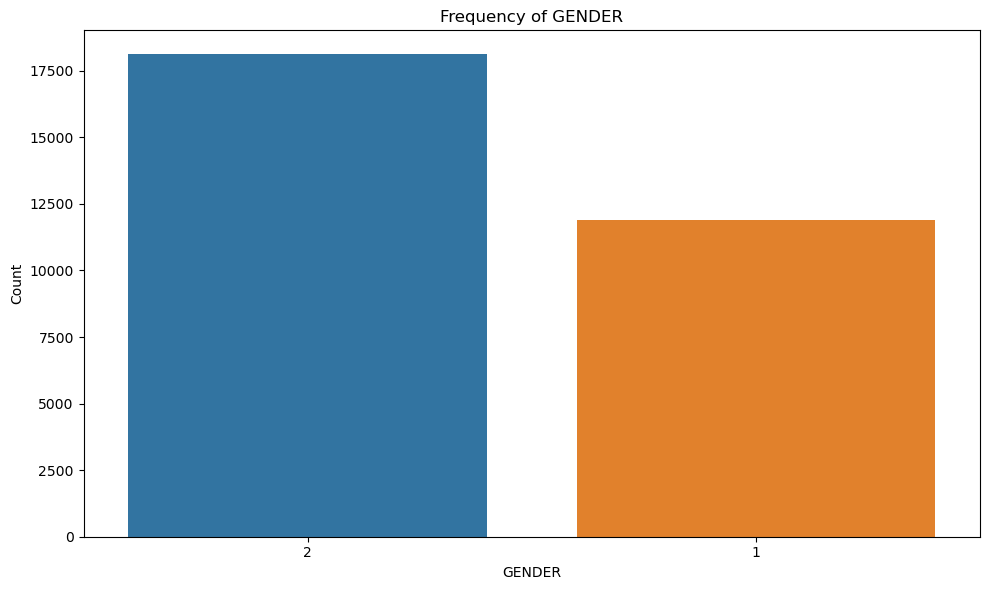

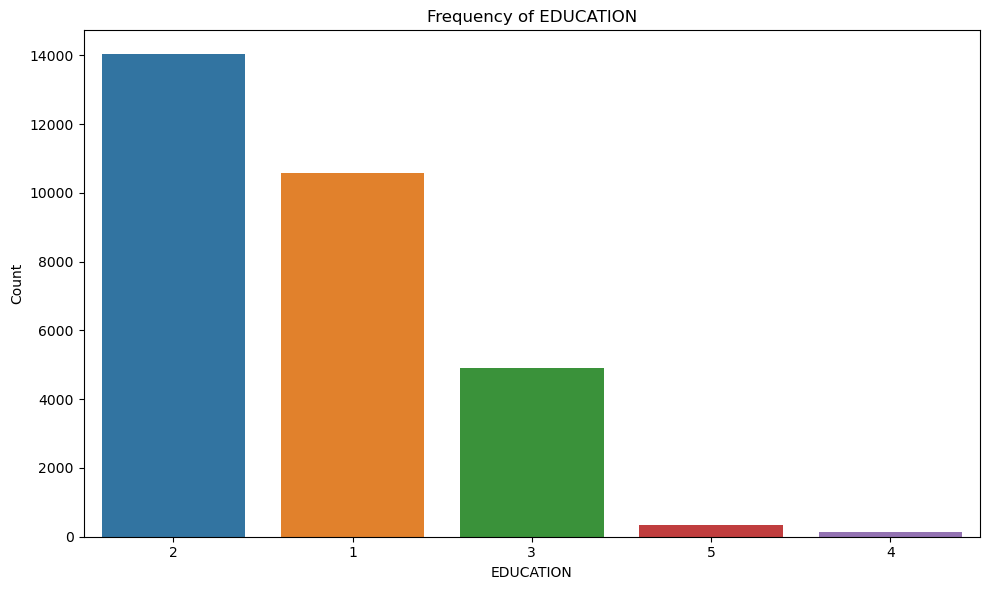

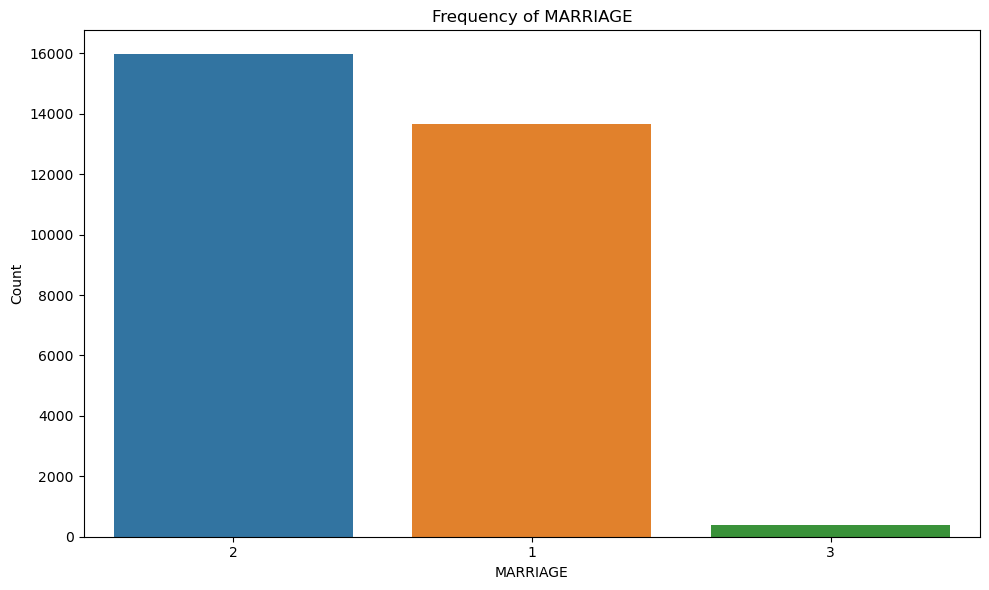

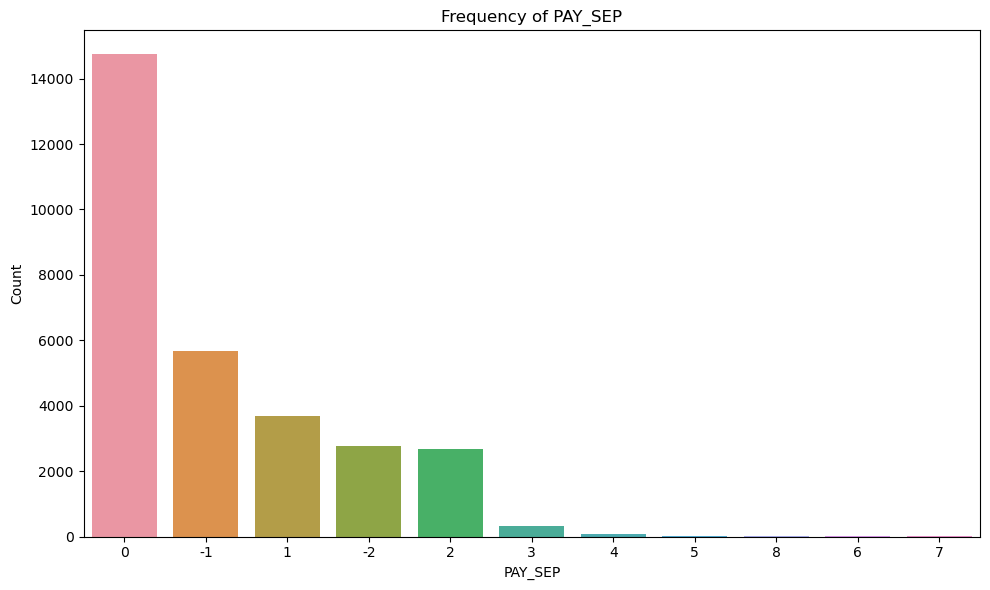

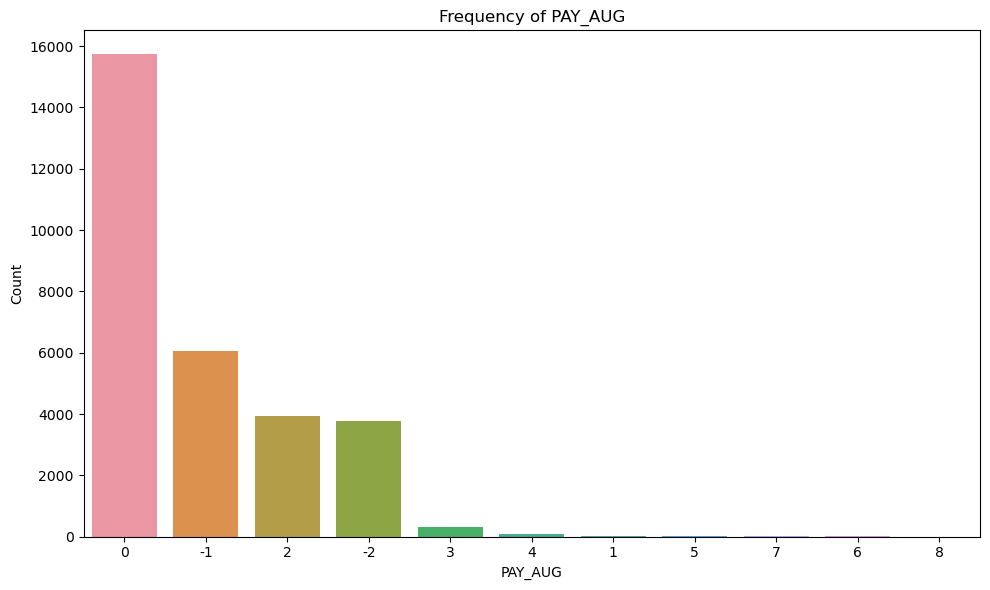

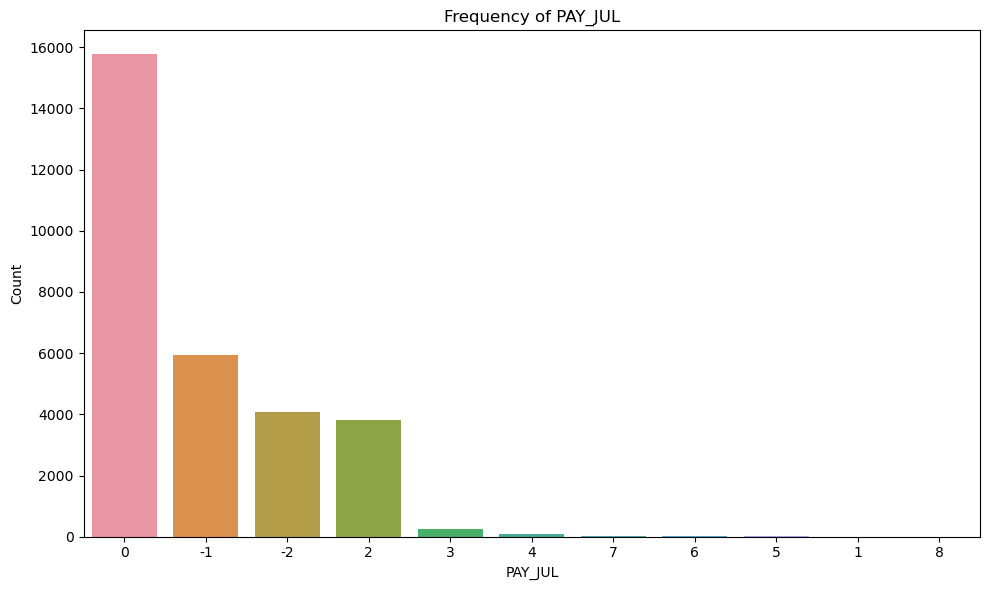

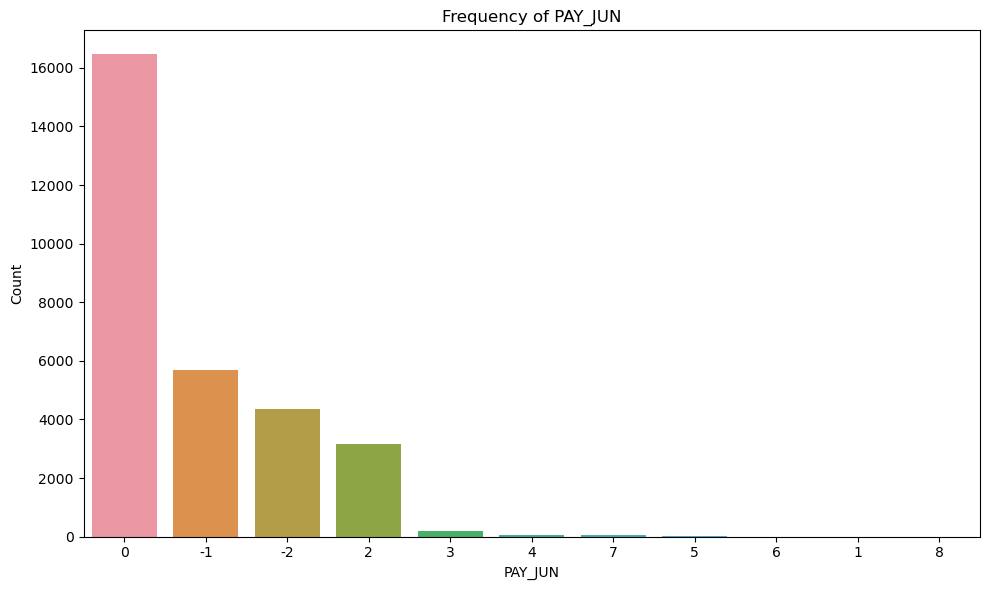

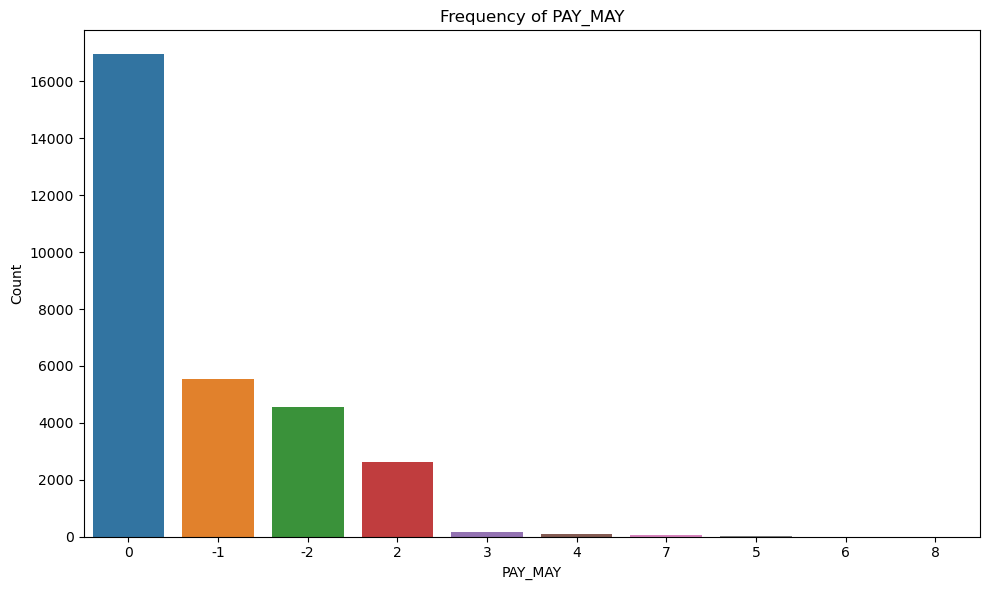

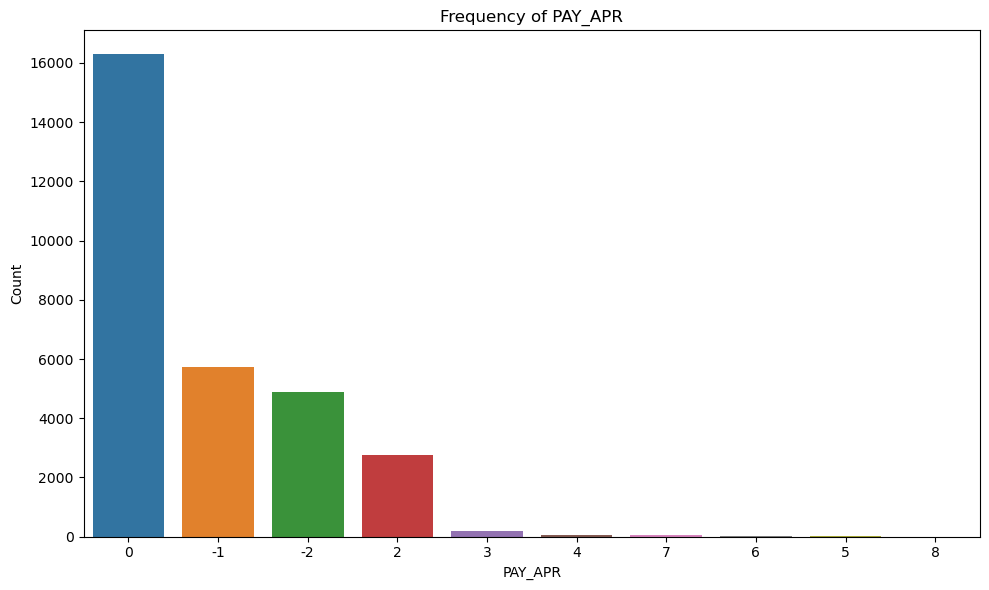

In [31]:

for i in credit_categoric_features.drop("DEFAULT",axis=1):
    univariate_categorical_analysis(credit,i)
    

In case of gender, females have taken credit the most

In case of marrital status, those who are single are in a mjority, 

Considering Education,people who are in university have a major share of the credit card holders, people in graduate are having a count, but lesser than university,

WHen we look at PAY_X, we can observe  common trend that people who took no credit(0), are in a high count 

In PAY_SEP: people who took no credit and people who paid duly(-1) have a good majority, then comes people who have a lag of 1 month in payment,ad then people who have made minimum credit payemnt
(0>-1>1>-2>2>3>4>5>8>6>7)

In PAY_AUG, we also people who have no credit in majority, (0>-1>2>-2>3>4>1>5>7>6>8),

In PAY_AUG, we also people who have no credit in majority, (0>-1>2>-2>3>4>1>5>7>6>8)

In PAY_JUL, we also people who have no credit in majority, but the majority of people in this month have values less than 1, ie(no credit, paid duly and paid minimum),(0>-1>-2>2>3>4>7>6>5>1>8)

In PAY_JUN, we also people who have no credit in majority, but similar to PAY_JUL,the majority of people in this month have values less than 1, ie(no credit, paid duly and paid minimum),(0>-1>-2>2>3>4>7>5>6>1>8) 

In PAY_MAY, we also people who have no credit in majority, but similar to PAY_JUL, PAY_JUN,the majority of people in this month have values less than 1, ie(no credit, paid duly and paid minimum),(0>-1>-2>2>3>4>7>5>6>8) also there are no count for delay of payement in 1 month when we observe the graph

In PAY_APRIL, we also people who have no credit in majority, but similar to PAY_MAY,the majority of people in this month have values less than 1, ie(no credit, paid duly and paid minimum),(0>-1>-2>2>3>4>7>5>6>8) also there are no count for delay of payement in 1 month when we observe the graph
 

In [32]:
def univariate_numerical_analysis(df, col):
    # Frequency counts
    frequency_counts = df[col].value_counts()
    
    # Plotting
    plt.figure(figsize=(5, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.show()
    
    return frequency_counts

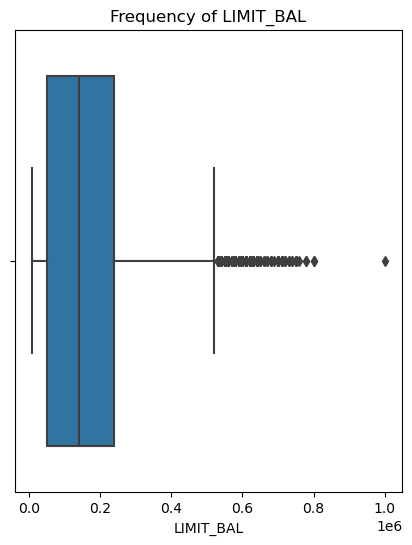

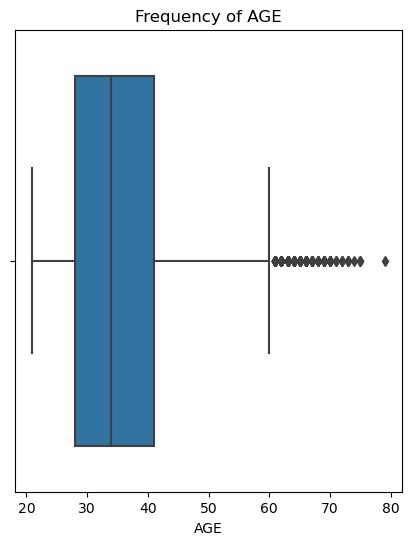

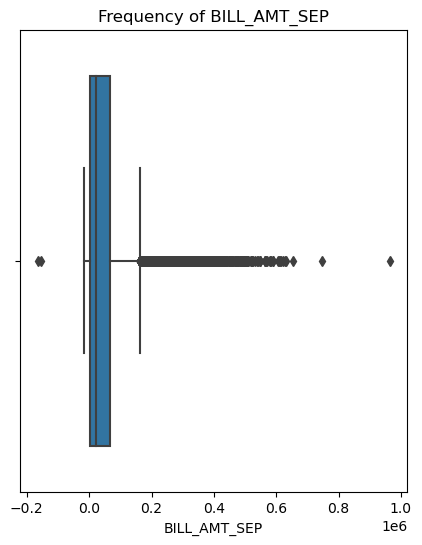

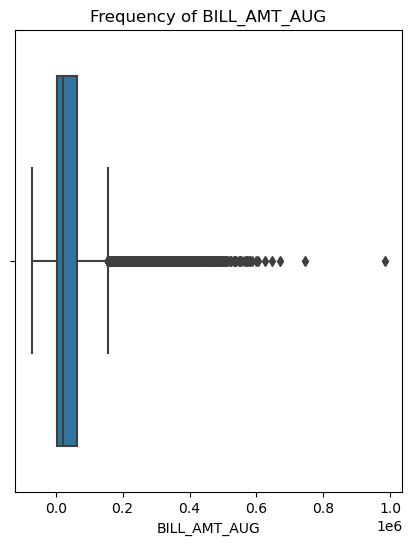

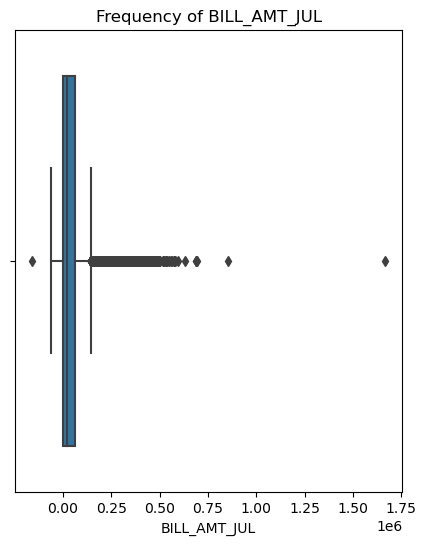

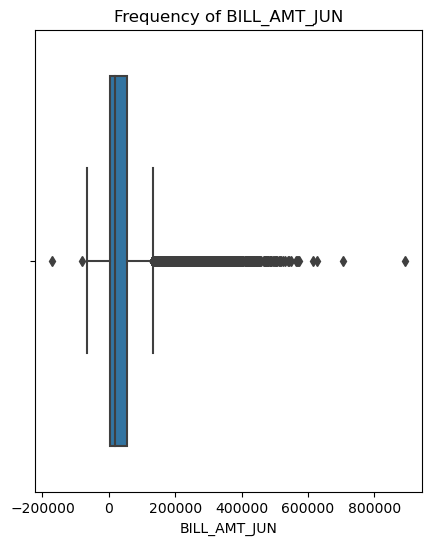

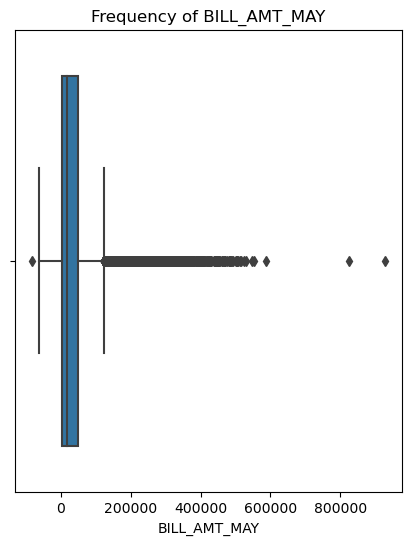

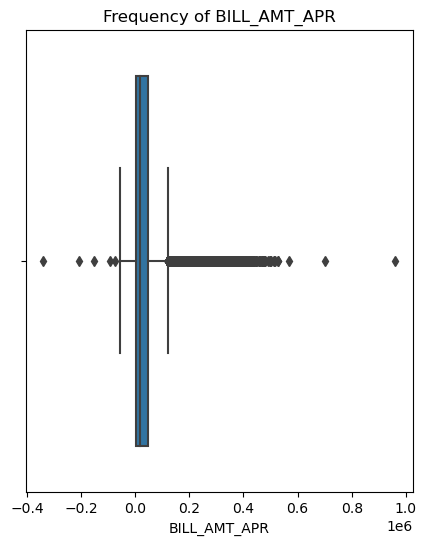

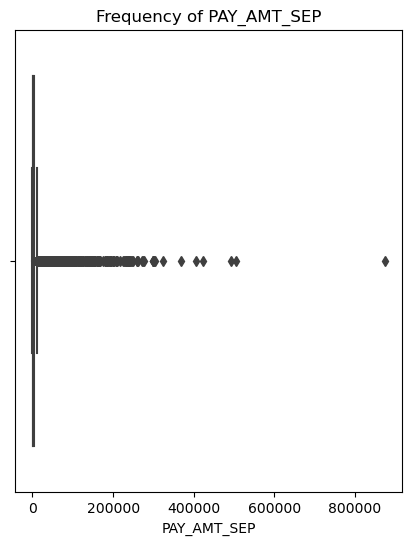

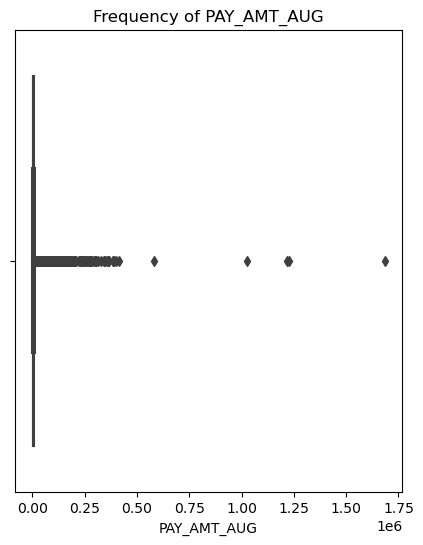

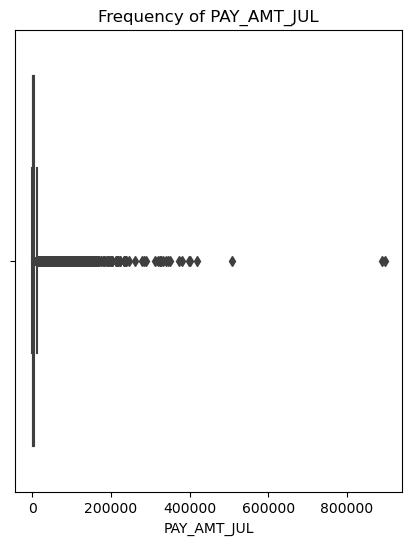

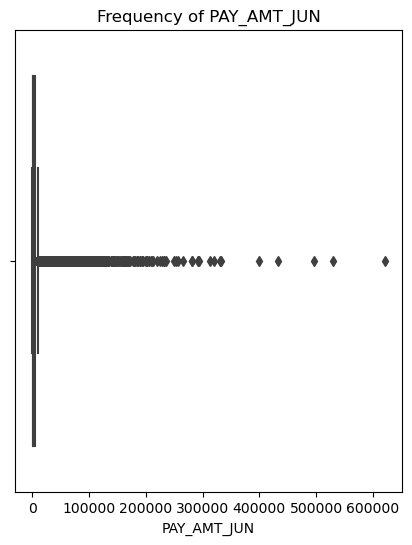

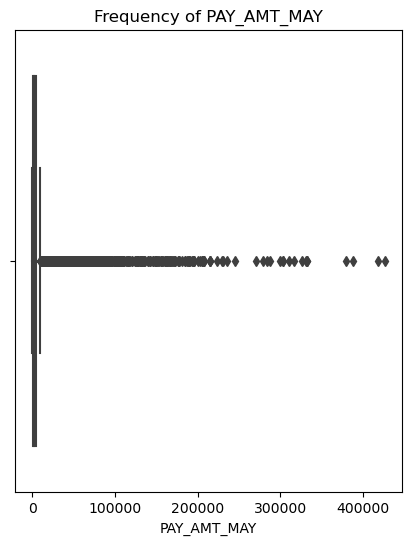

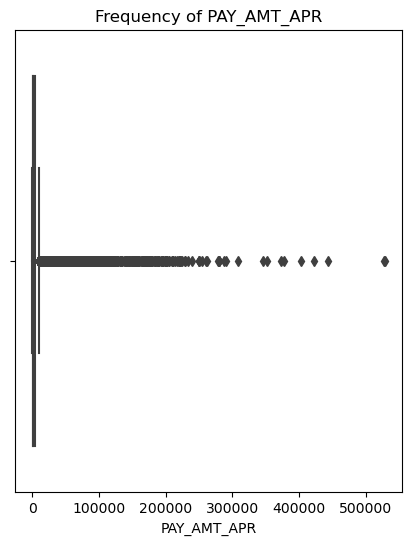

In [33]:
for i in credit_numeric_features.drop("ID",axis = 1):
    univariate_numerical_analysis(credit,i)

LIMIT_BAL (Credit Limit):
The range of credit limits varies significantly, with the median around the middle of the interquartile range (IQR).
There are some outliers on the higher end, indicating a few customers with exceptionally high credit limits.

AGE:
The distribution of ages shows a concentration around the late 20s to early 30s.
There are a few outliers for both younger and older customers, with a maximum age around 80.

BILL_AMT1 to BILL_AMT6 (Bill Statement Amounts for the Last Six Months):
The bill amounts vary widely across all six months.
The medians are relatively low compared to the maximum values, indicating a skewed distribution.
Numerous outliers, suggesting that some customers have very high outstanding amounts.

PAY_AMT1 to PAY_AMT6 (Previous Payments for the Last Six Months):
Payment amounts also show considerable variation, with many payments clustering around lower amounts.
There are significant outliers, indicating some customers make very high payments, potentially as large as their outstanding balances.

# Categorical vs Categorical Analysis

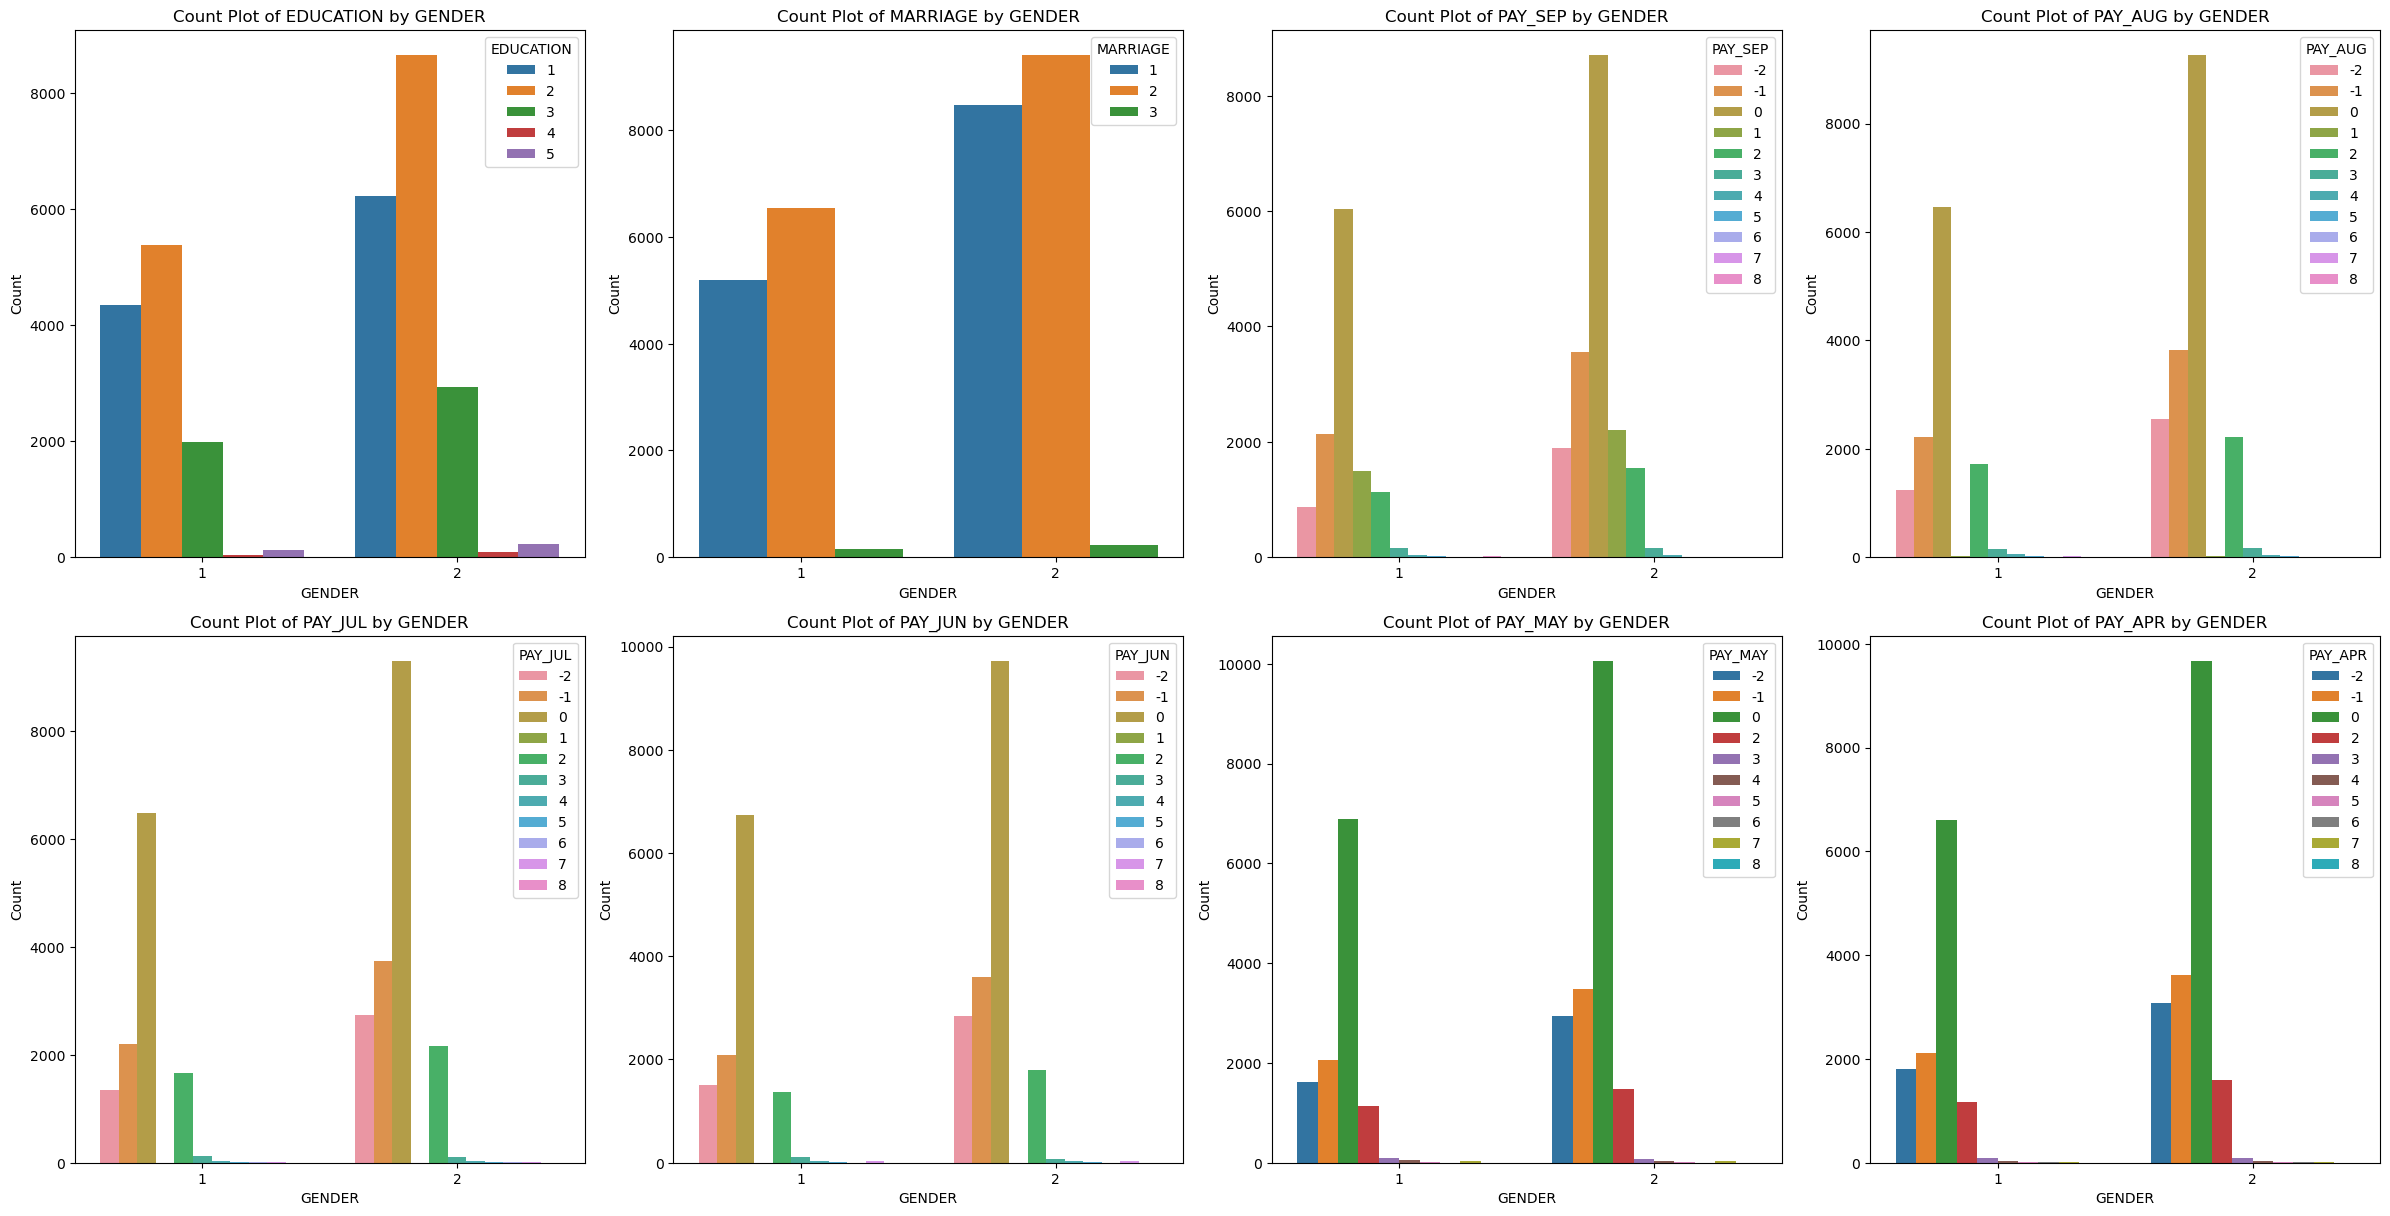

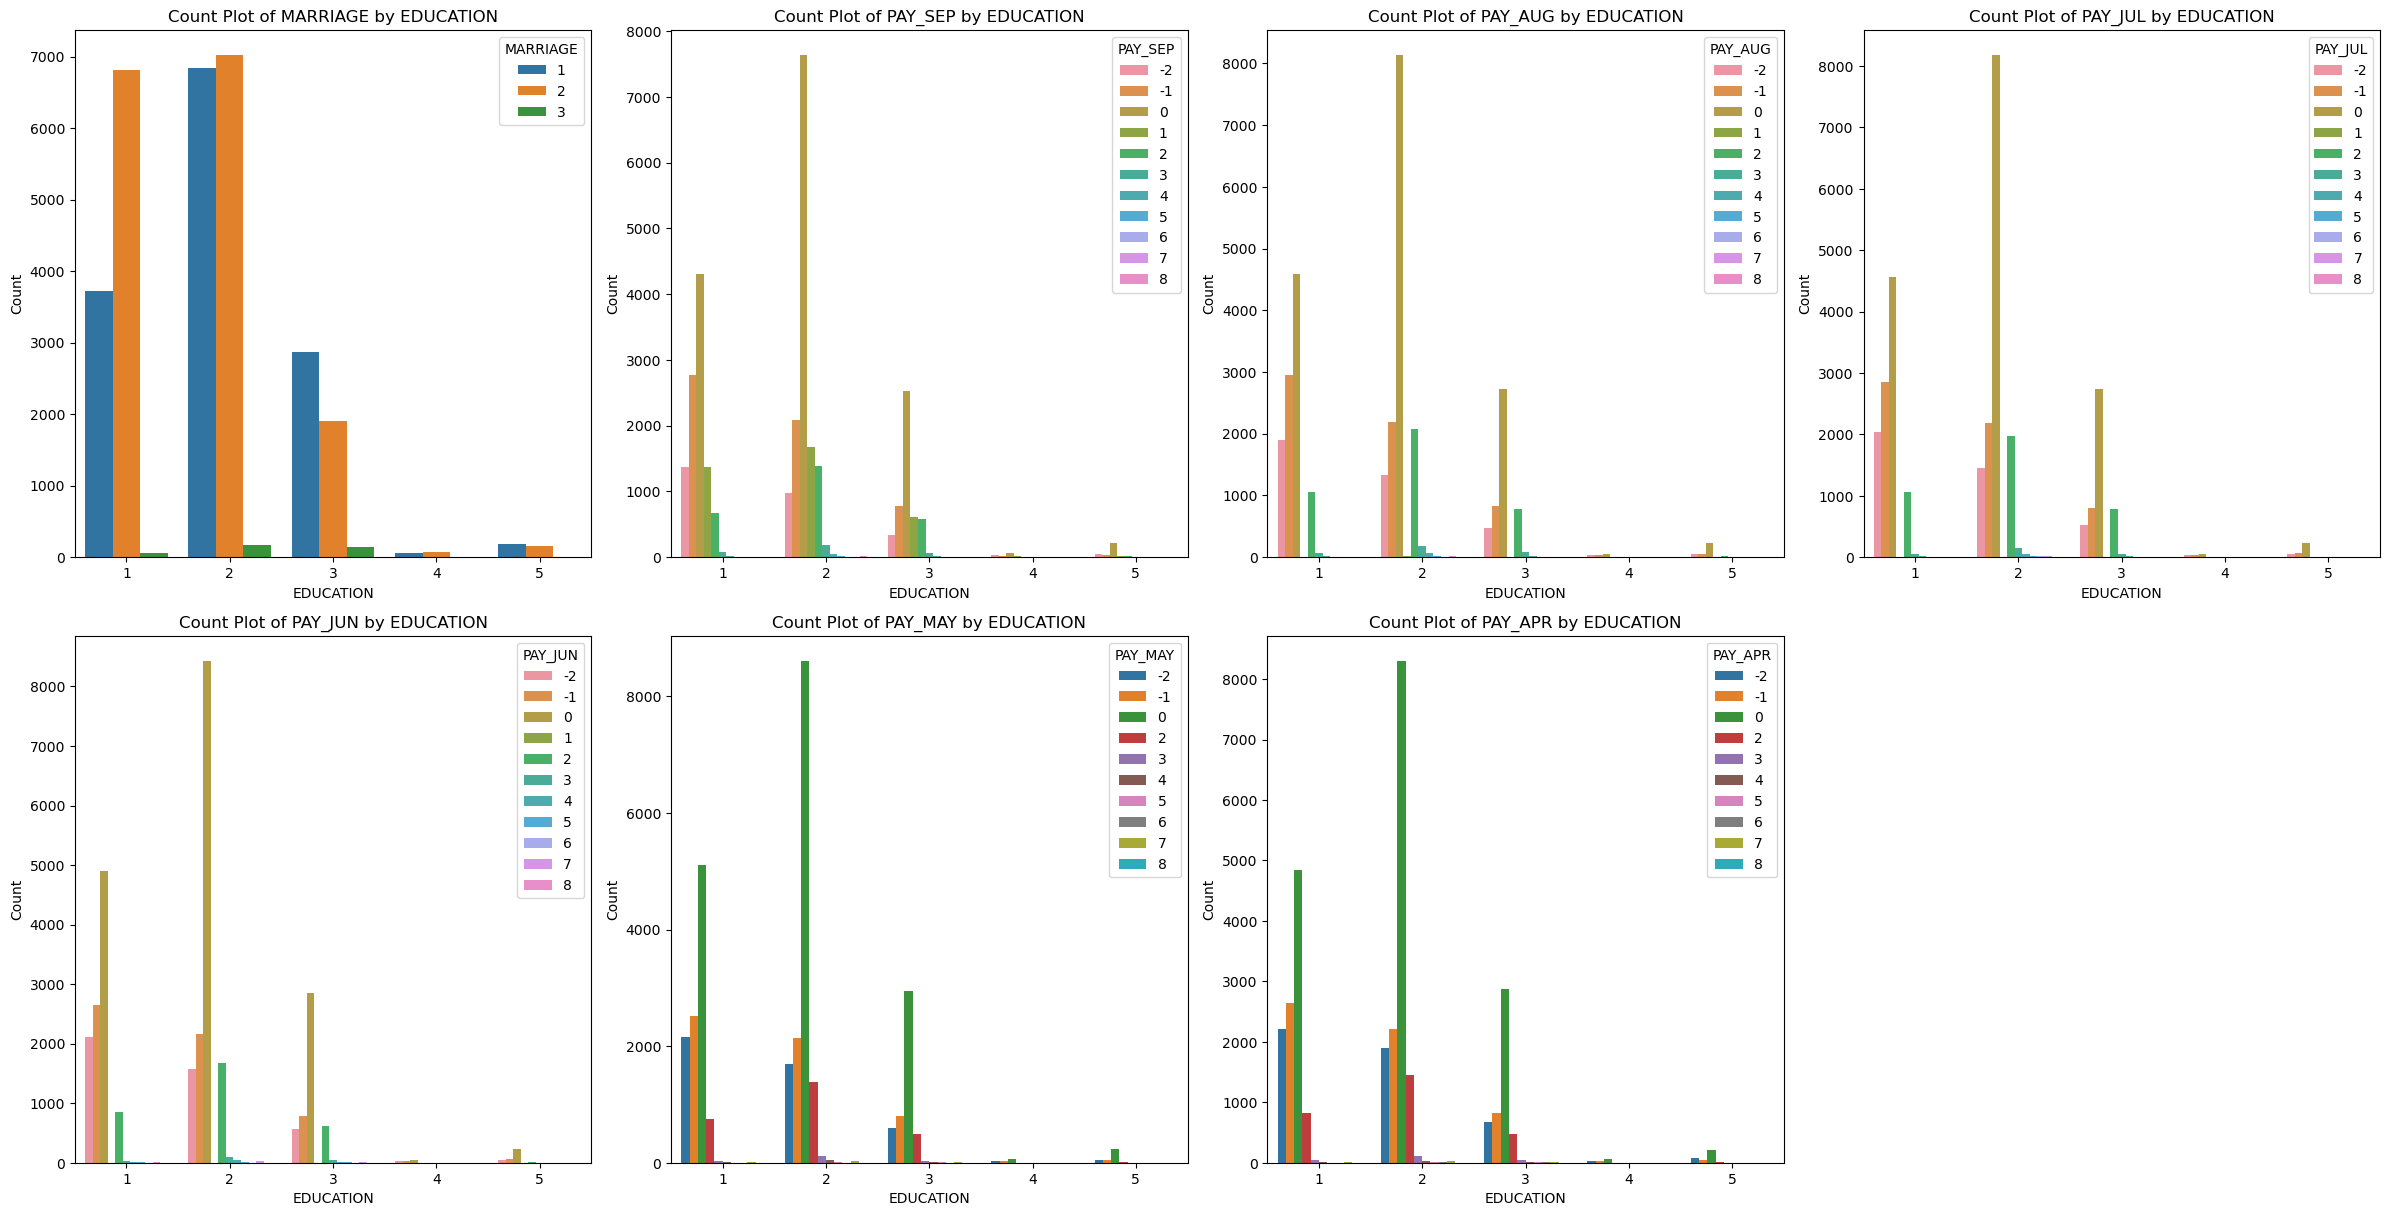

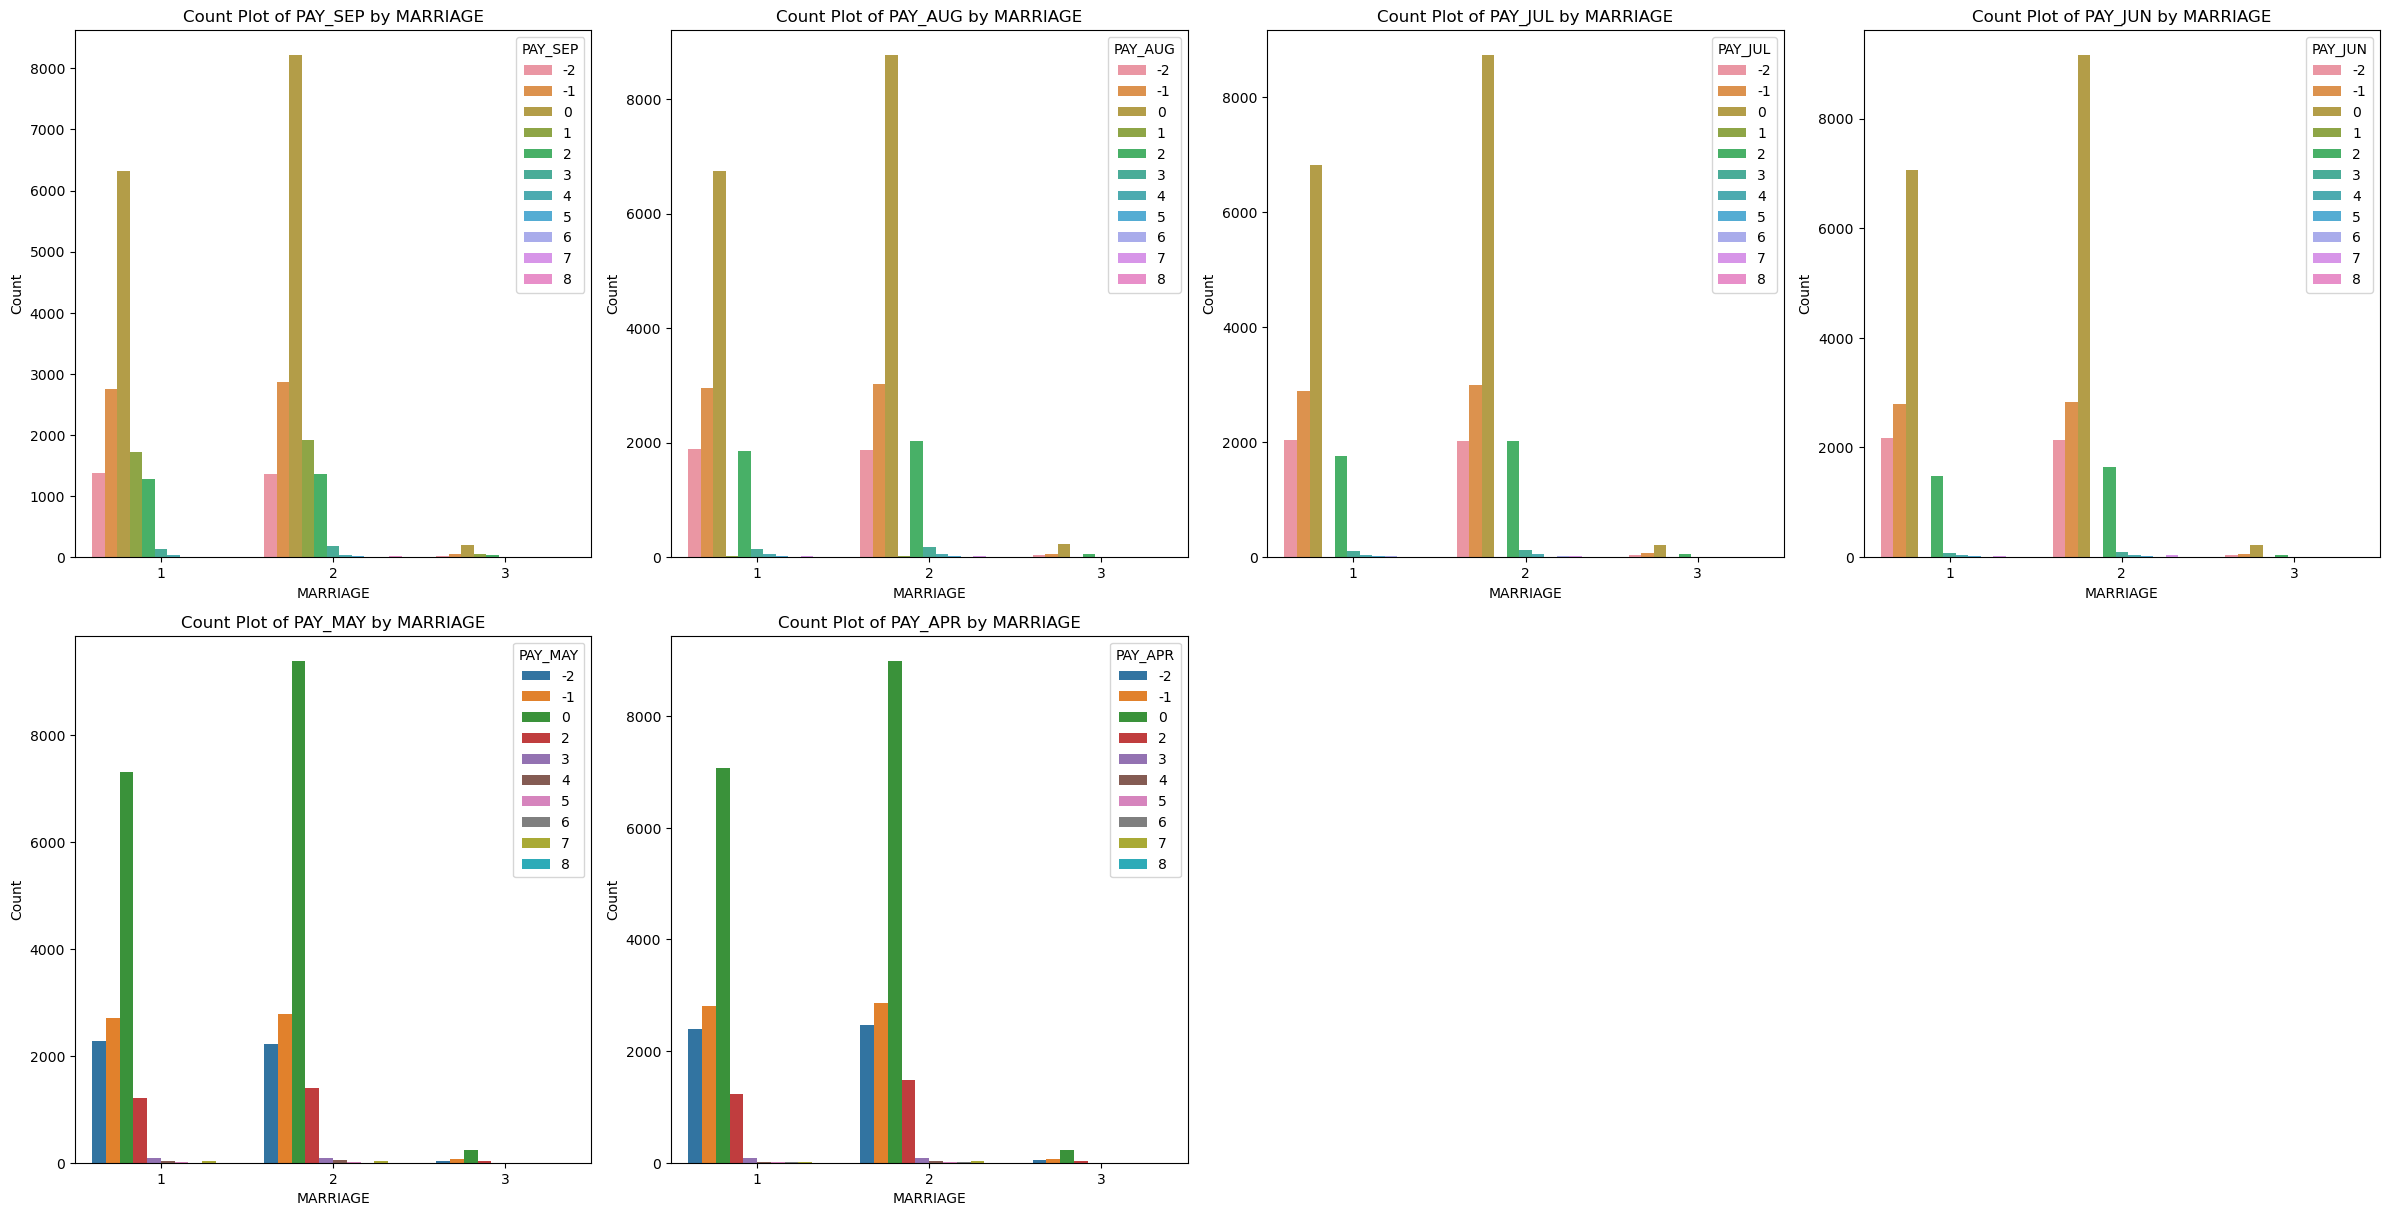

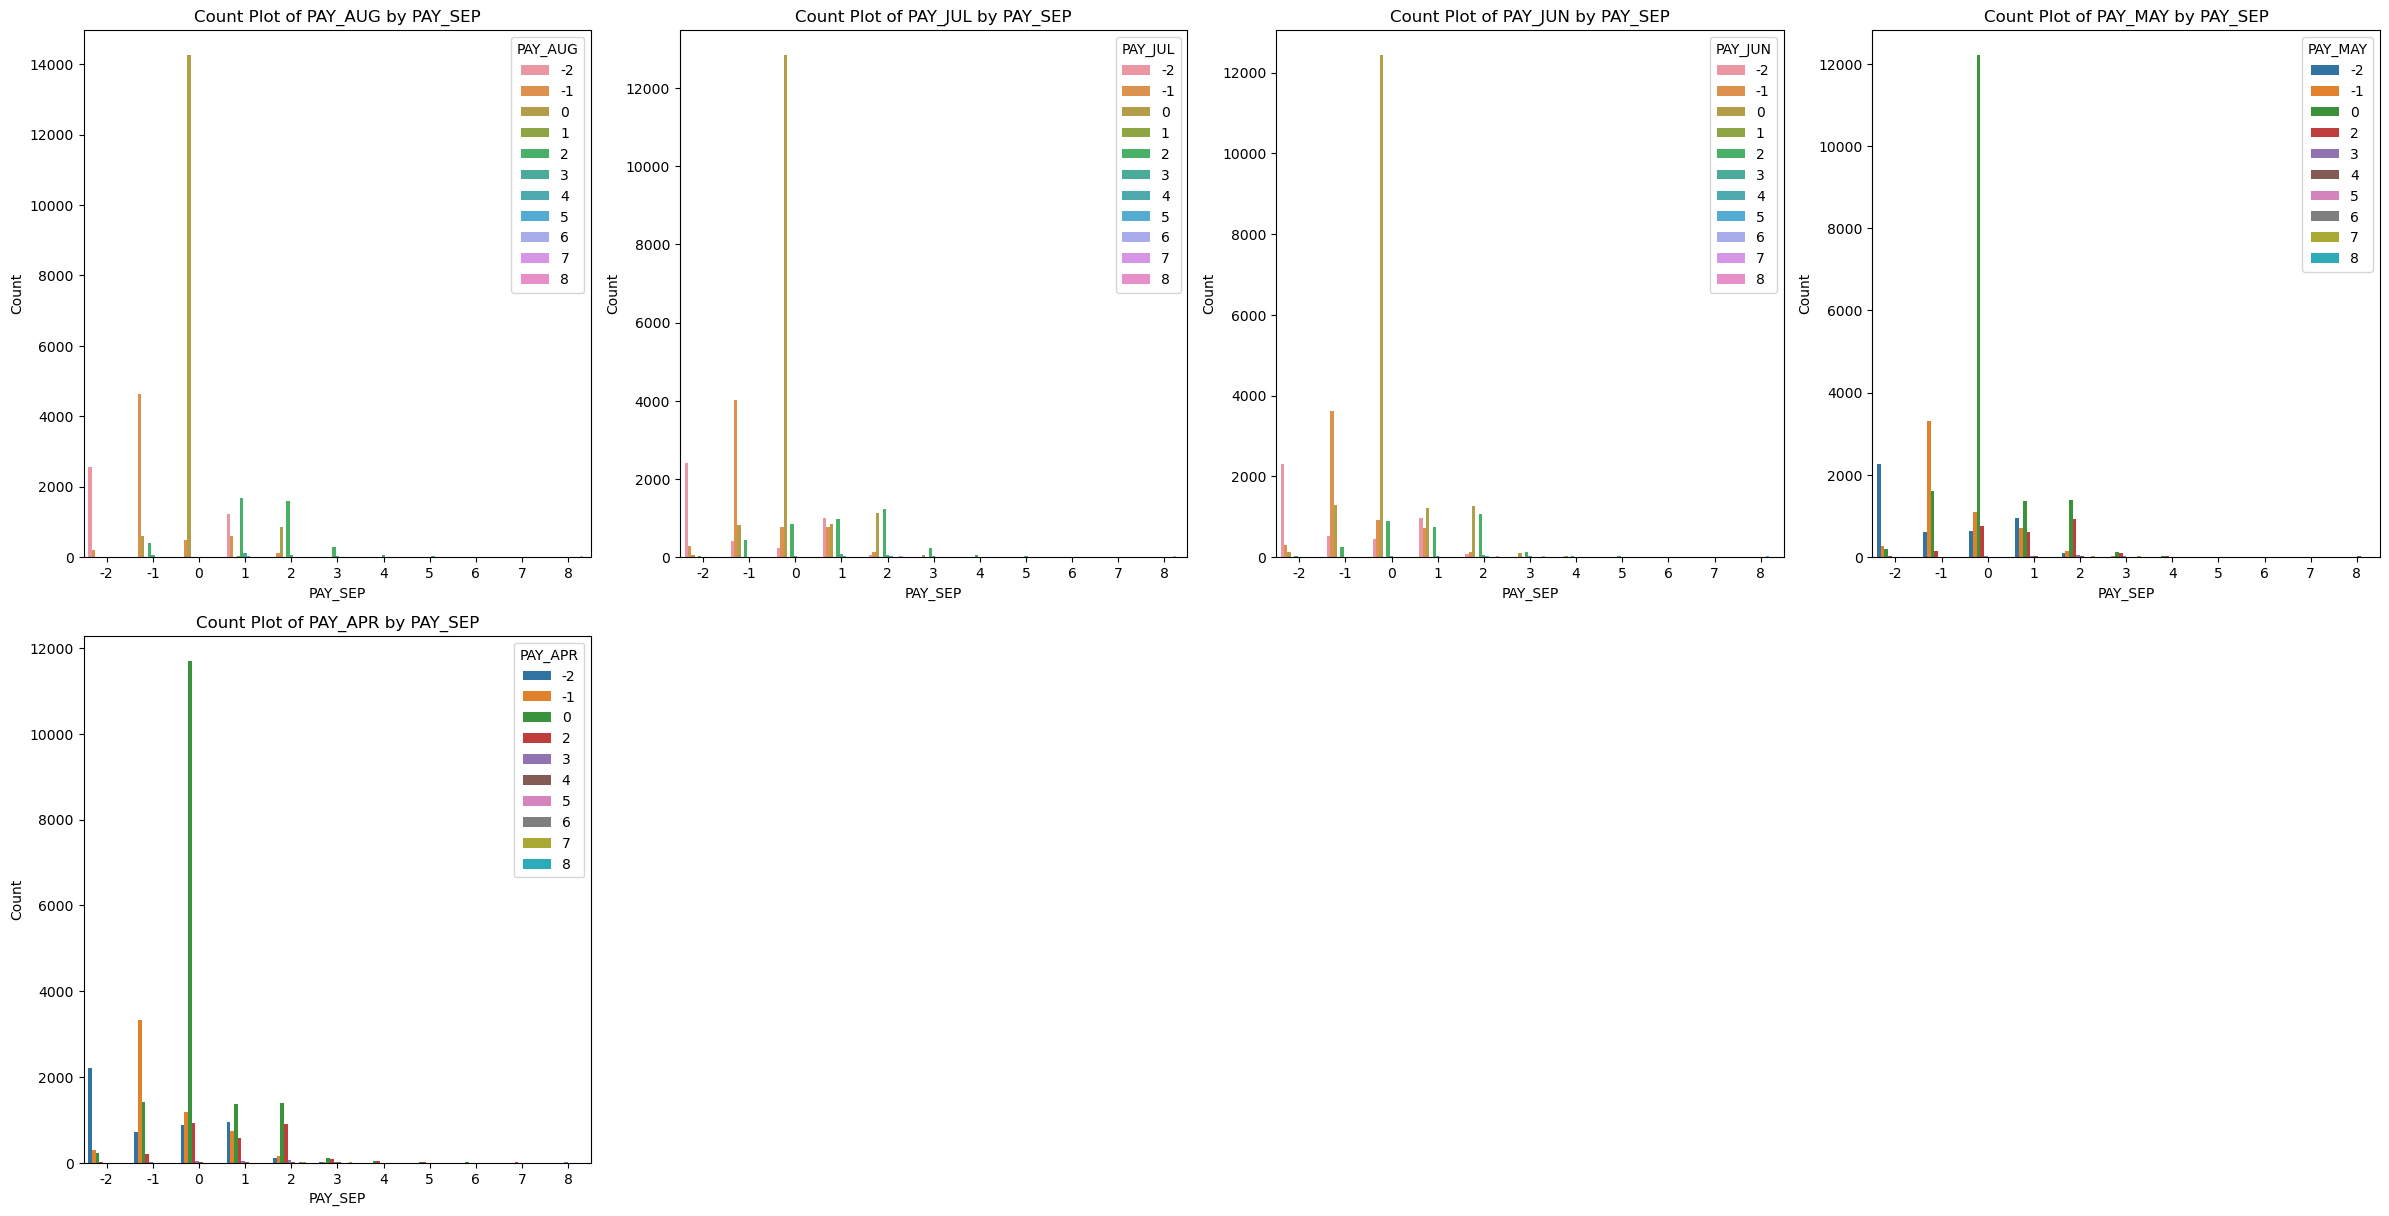

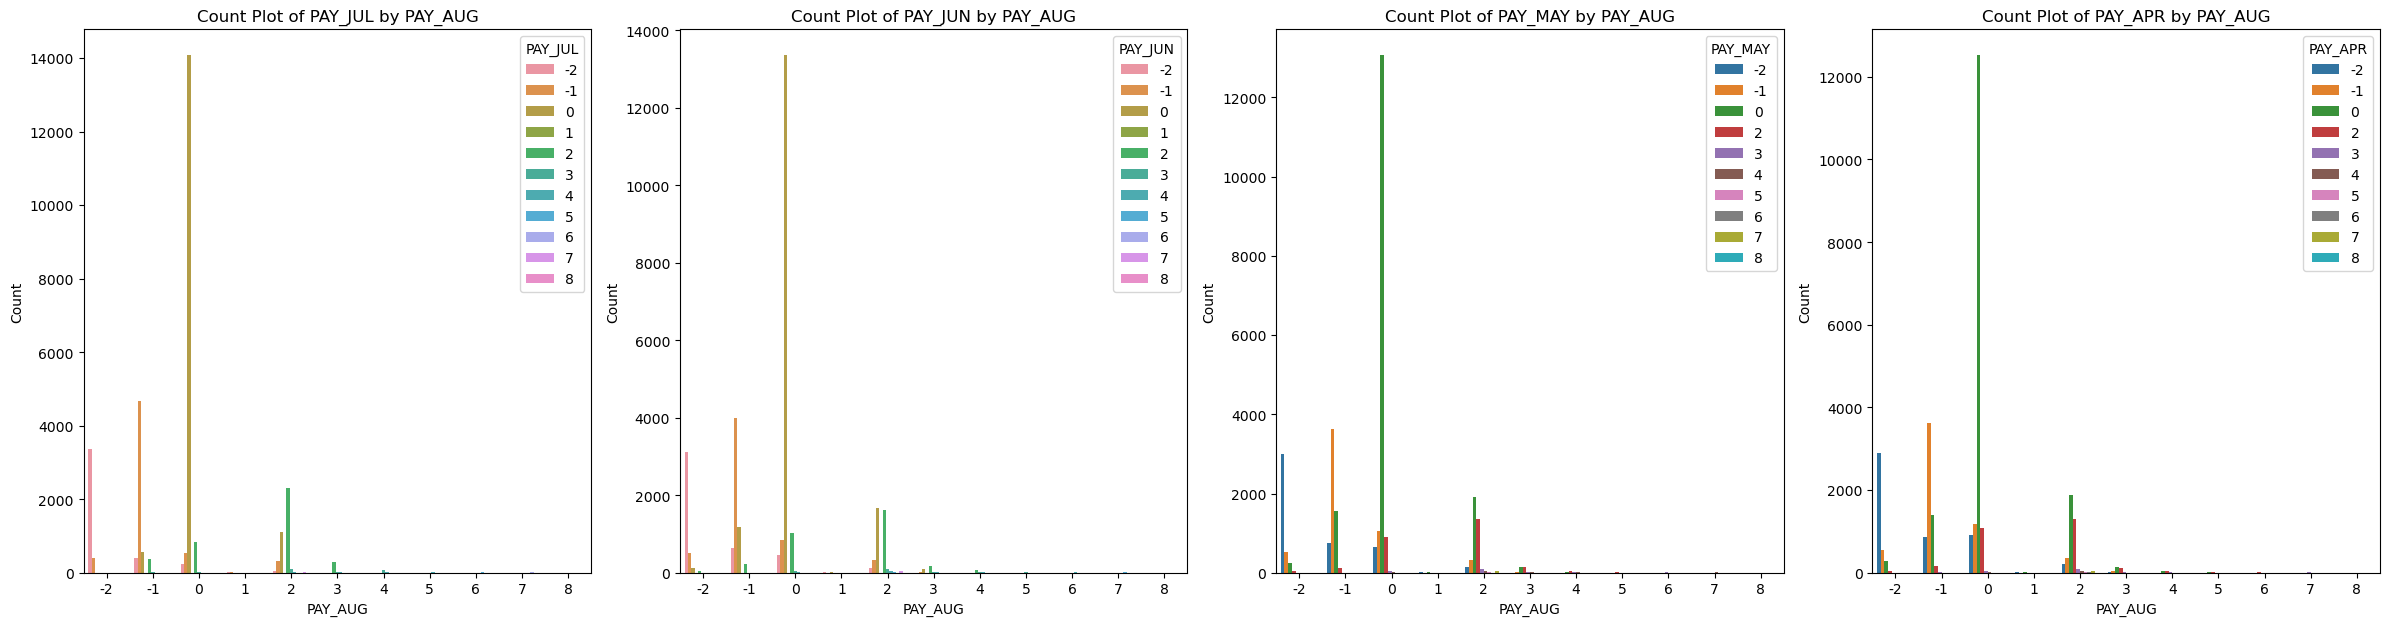

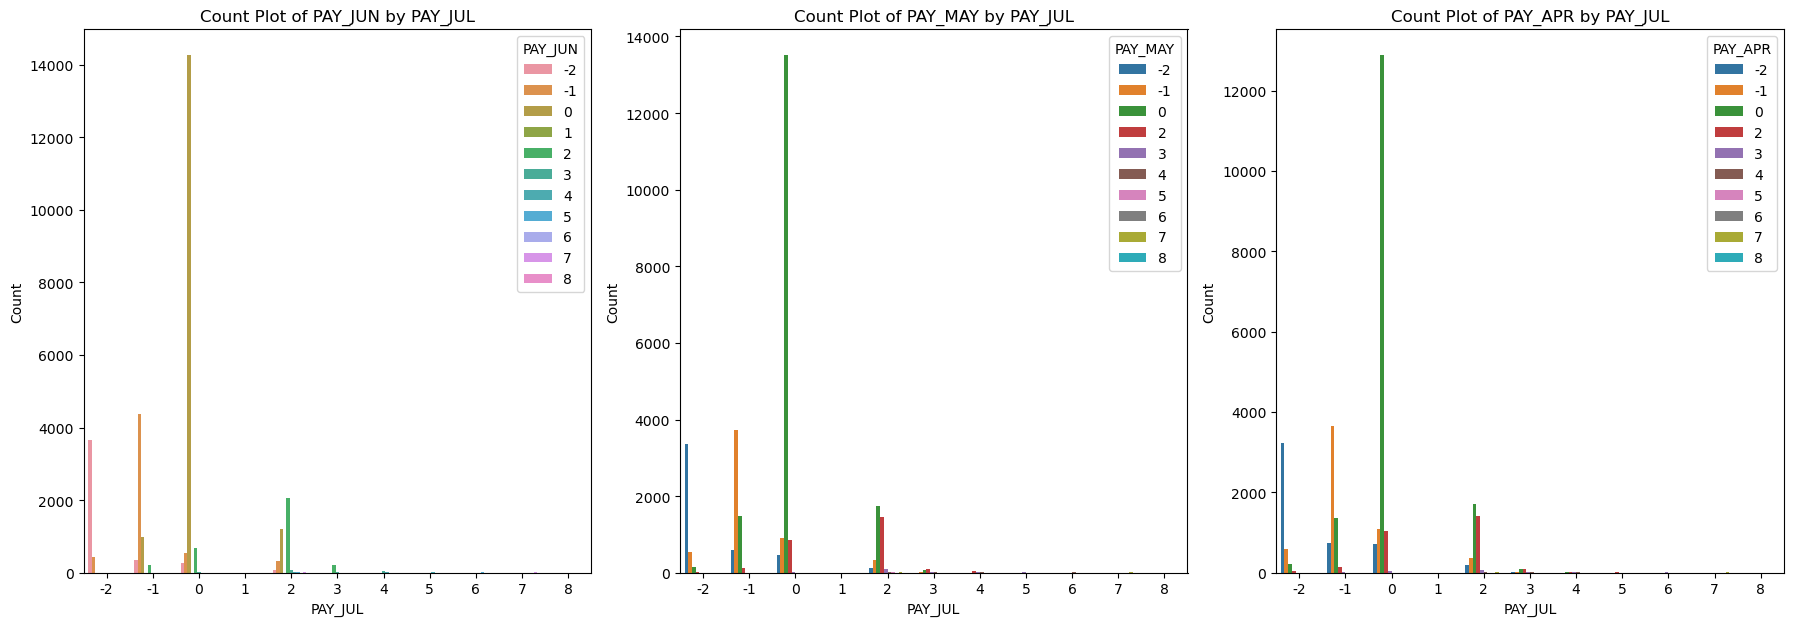

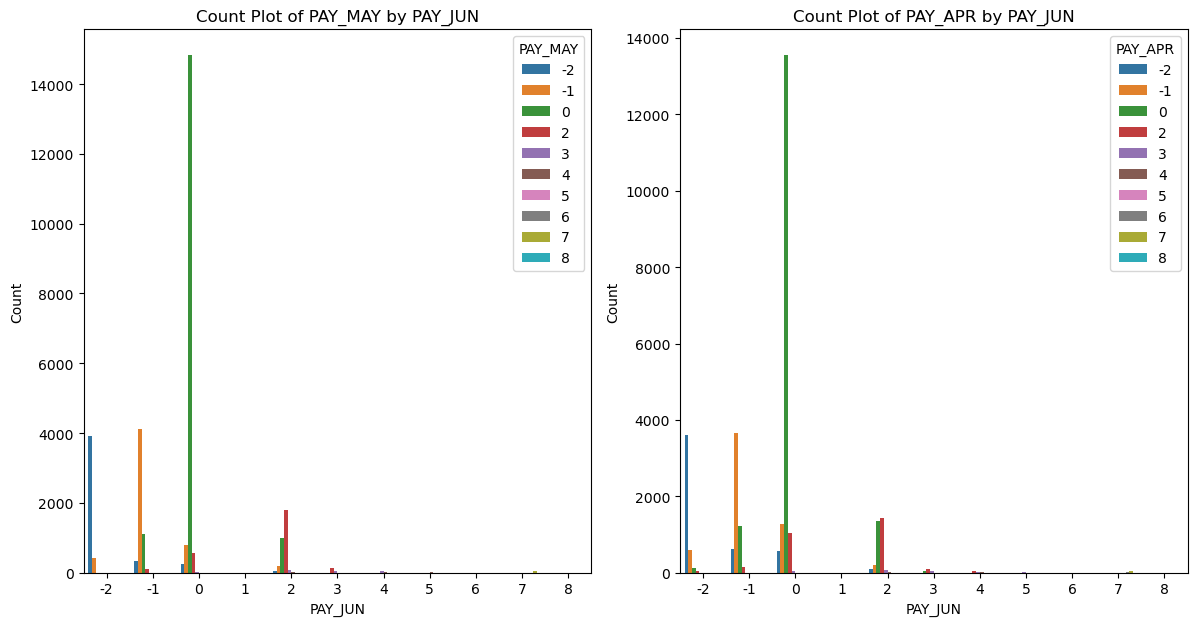

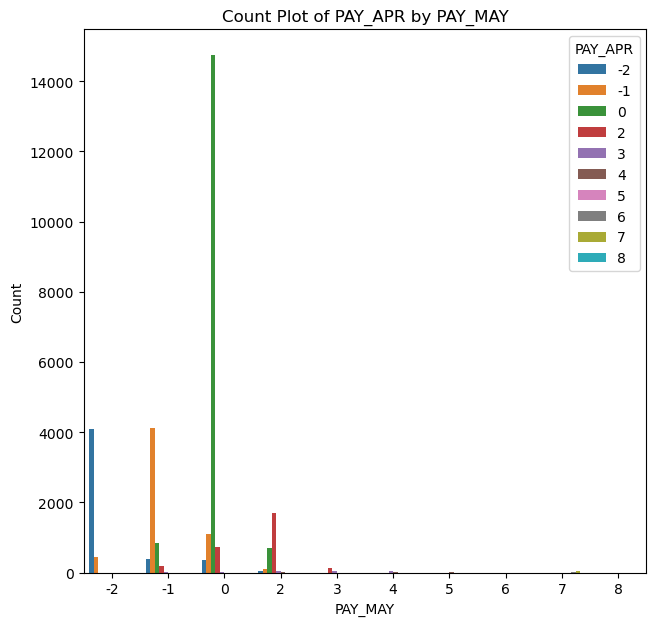

<Figure size 2400x3000 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

n_rows = 5
n_cols = 4  

used_field = []
for i, col1 in enumerate(credit_categoric_features.drop("DEFAULT", axis=1)):
    used_field.append(col1)
    #subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 30))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    plot_idx = 0  # Index to keep track of the subplot position
    for j, col2 in enumerate(credit_categoric_features.drop("DEFAULT", axis=1)):
        if col2 not in used_field and i != j:
            sns.countplot(x=col1, hue=col2, data=credit, ax=axes[plot_idx])
            axes[plot_idx].set_title(f'Count Plot of {col2} by {col1}')
            axes[plot_idx].set_xlabel(col1)
            axes[plot_idx].set_ylabel('Count')
            axes[plot_idx].legend(title=col2)
            plot_idx += 1
            if plot_idx >= n_rows * n_cols:
                break 

    # Remove any unused subplots
    for idx in range(plot_idx, n_rows * n_cols):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()



GENDER VS MARRIAGE:
Single Women tend to take more credit that married women and men, in men also, we find that single men takes more credit when compared to women

GENDER VS EDUCATION:
In education,females have a majority of the credit cards used, of which females in university and graduate females have a larger share.in males, graduate males have a majority

GENDER VS PAY_x:
Women takes more credit and also they pay duly, thier majority values lies between -2 to 0

EDUCATION VS MARRIAGE:
People in university seems to use more credit card irrespective wether married or not married, graduate students who are single also tend to use more credit cards.

EDUCATION vs PAY_X:
here also people in university pays thier credit duly as the majority values lies between -2 to 0

MARRIAGE vs PAY_X:
We see that both single people and married people tend to pay duly,as the majority values lies between -2 and 0



This plot helps identify the distribution of educational attainment across genders.

# Numerical vs Numerical Analysis

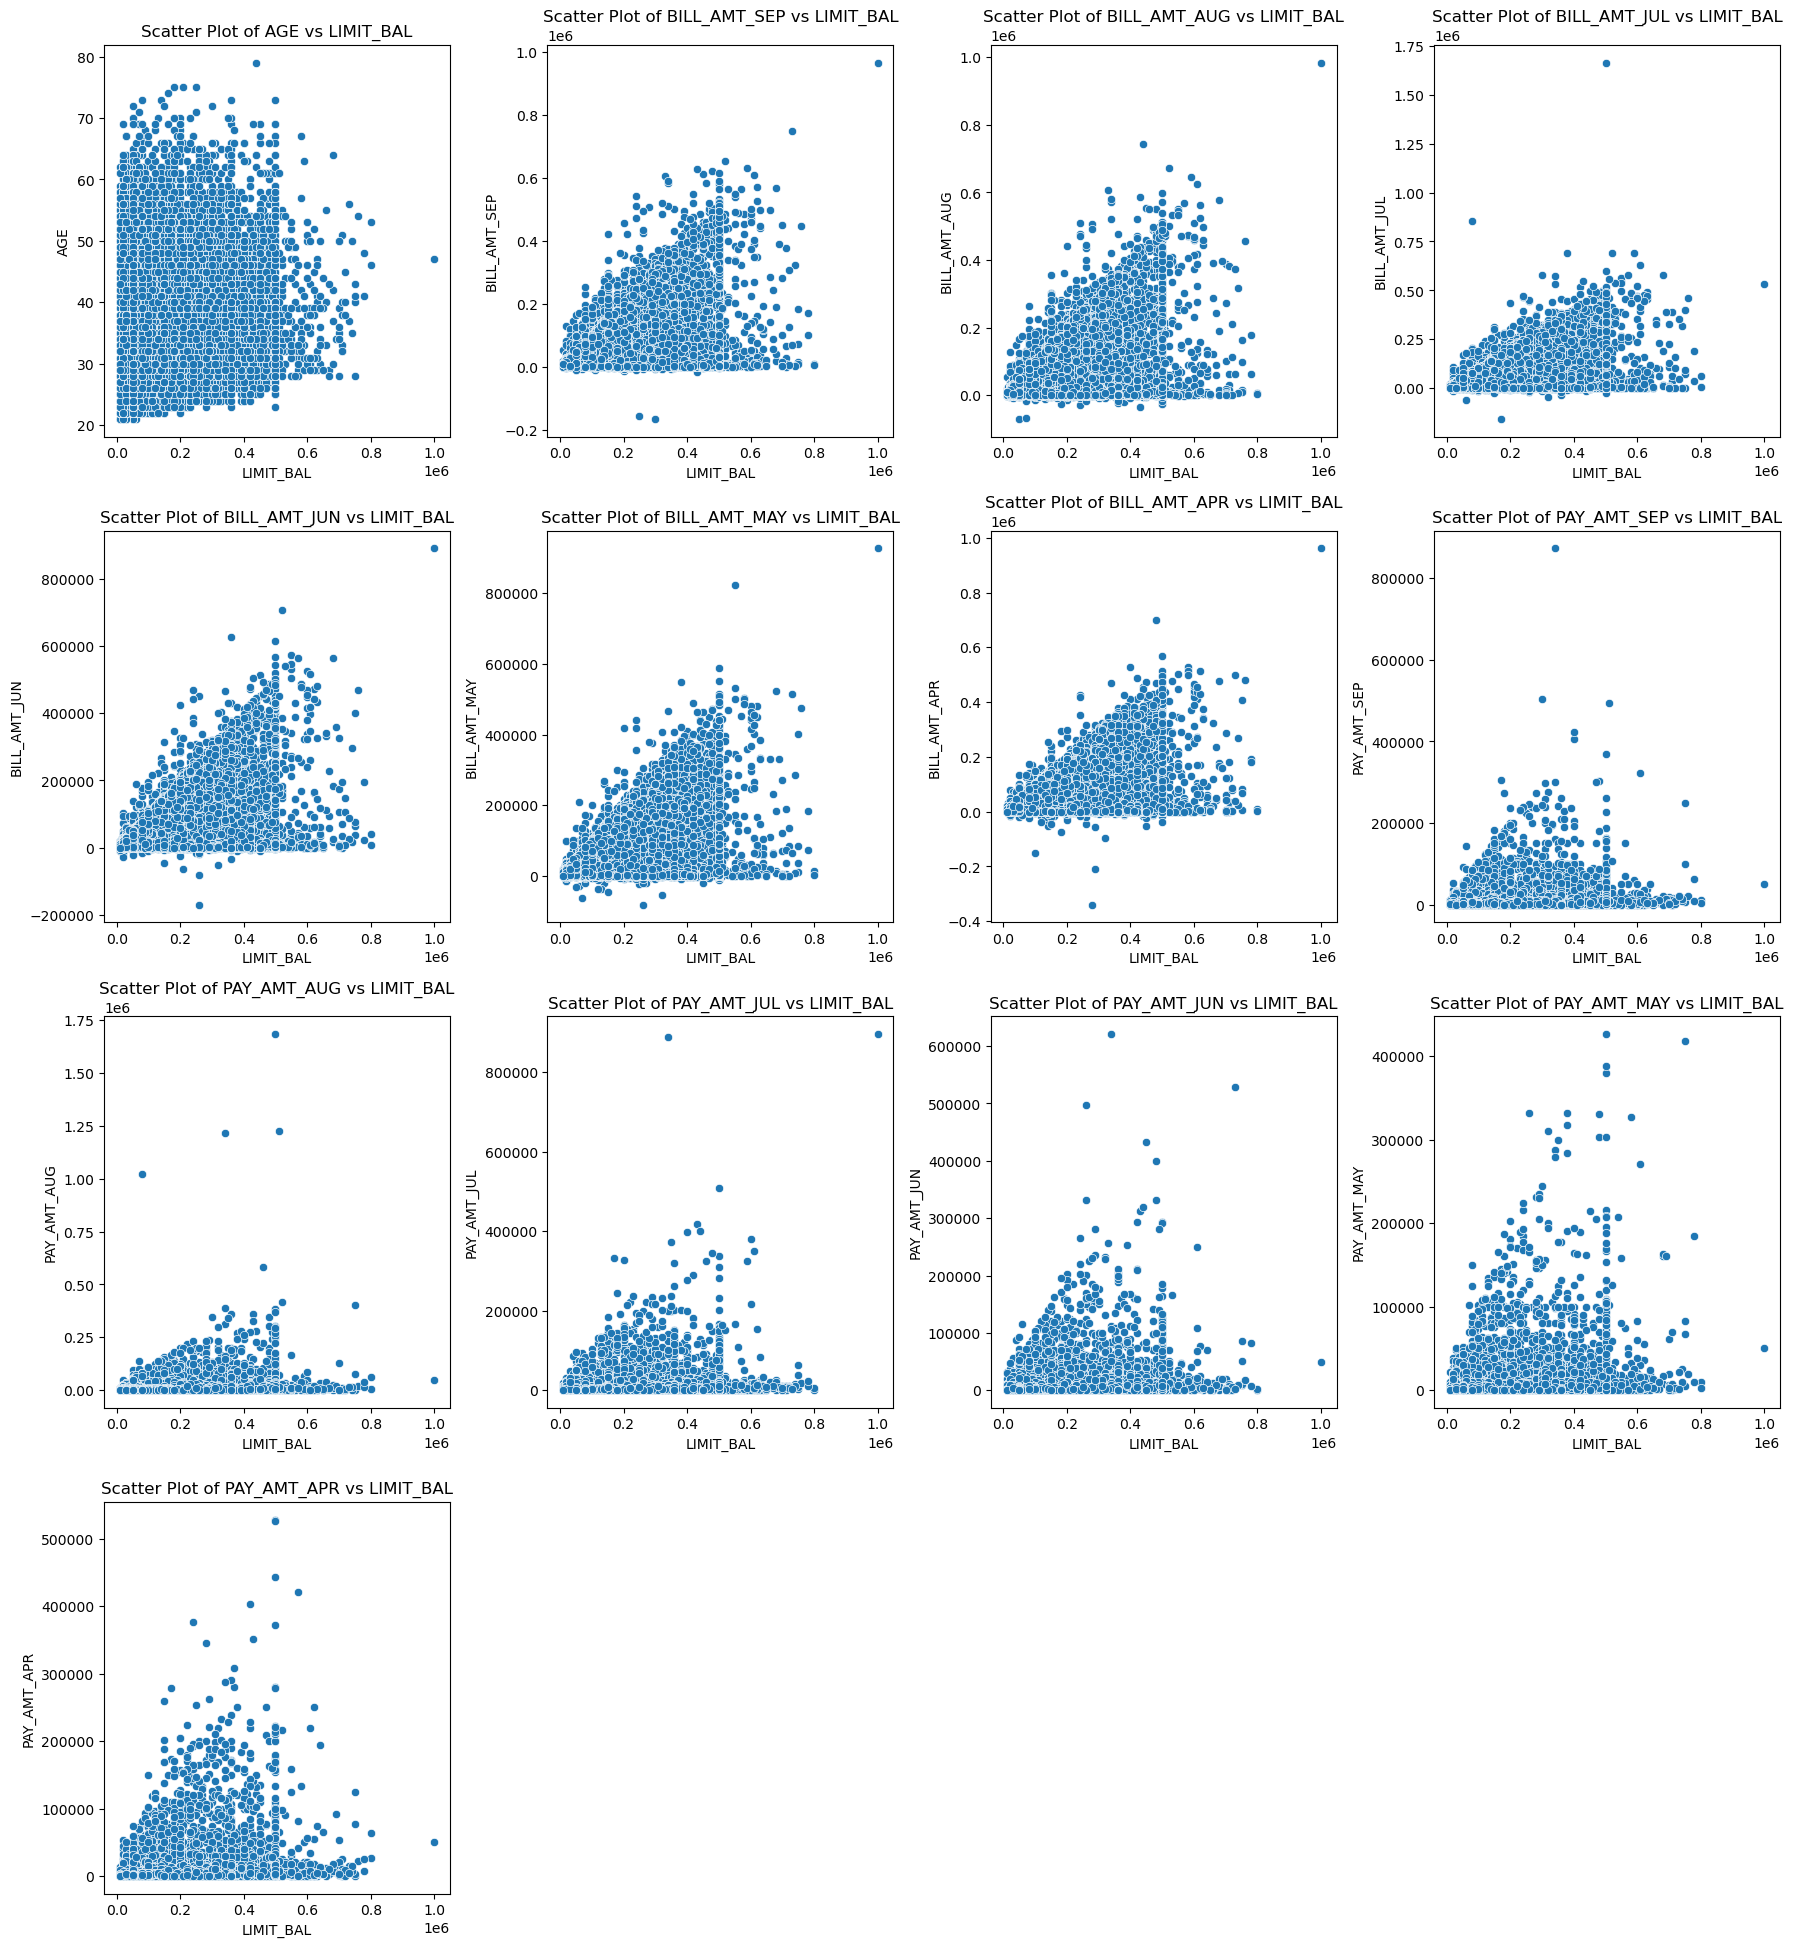

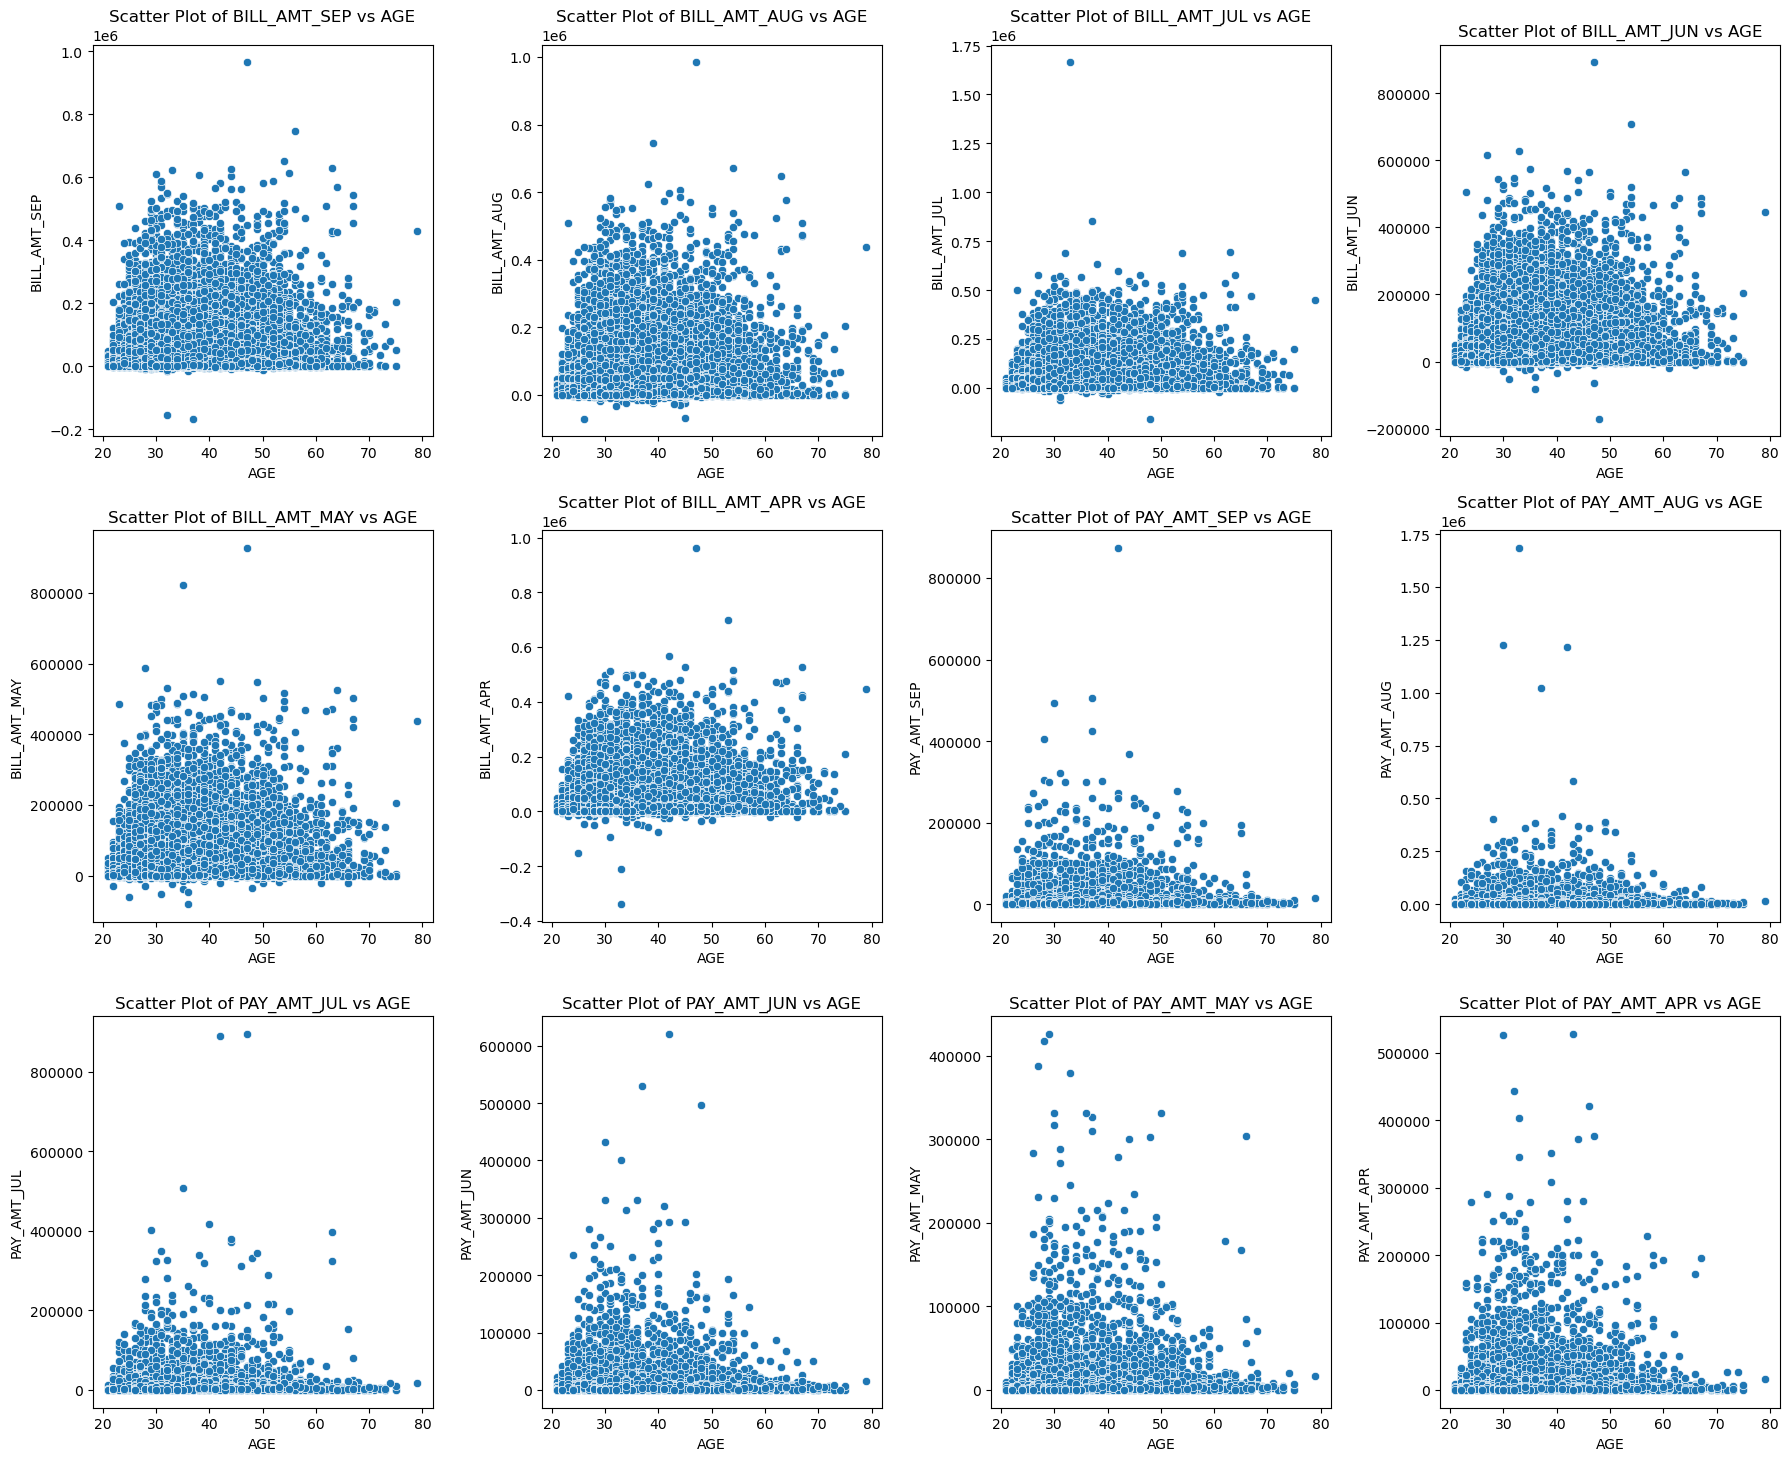

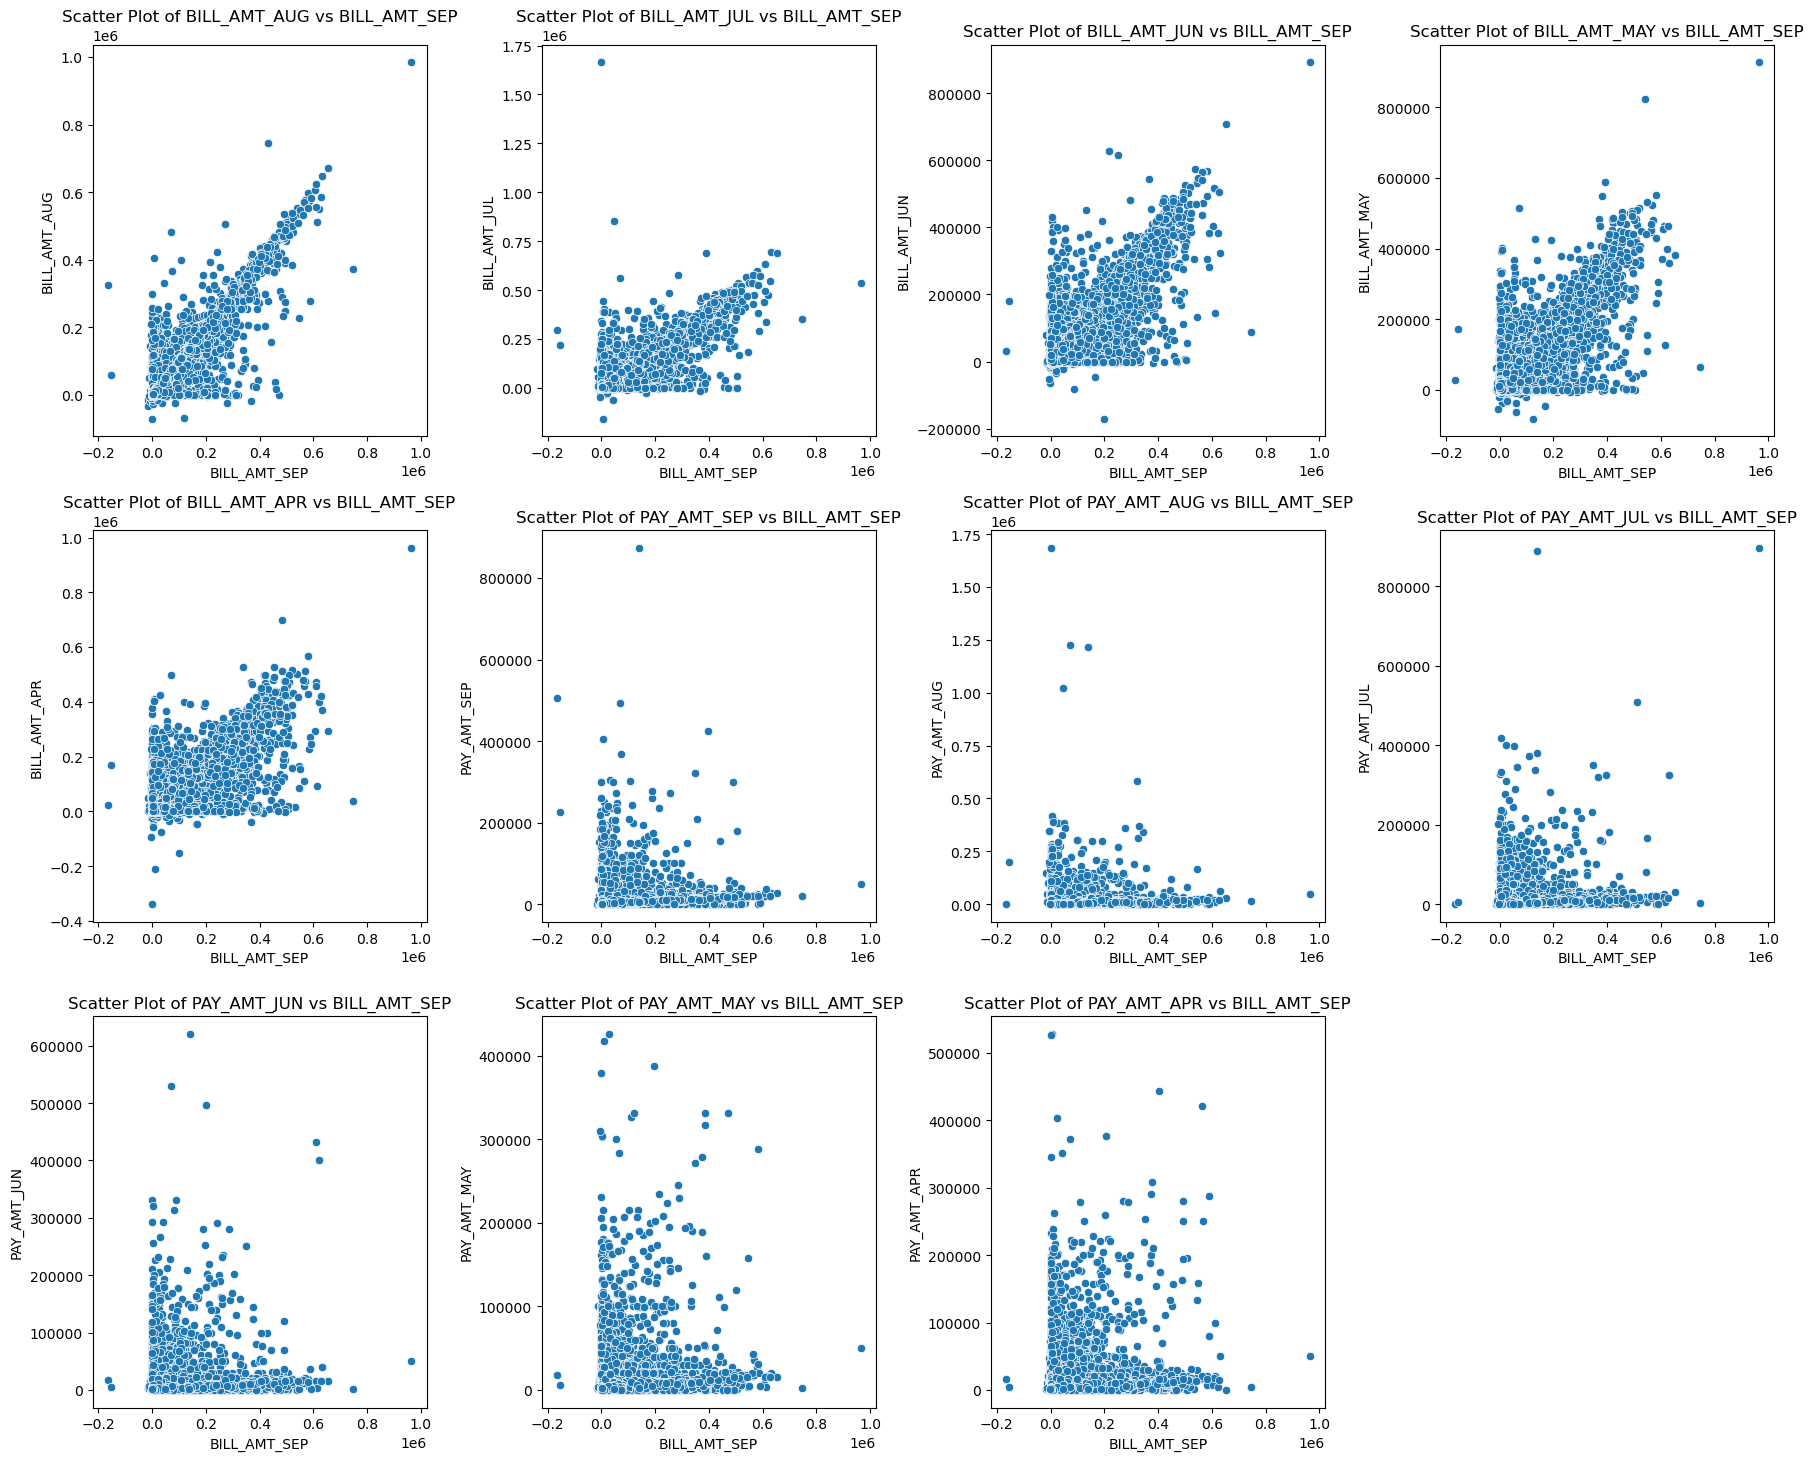

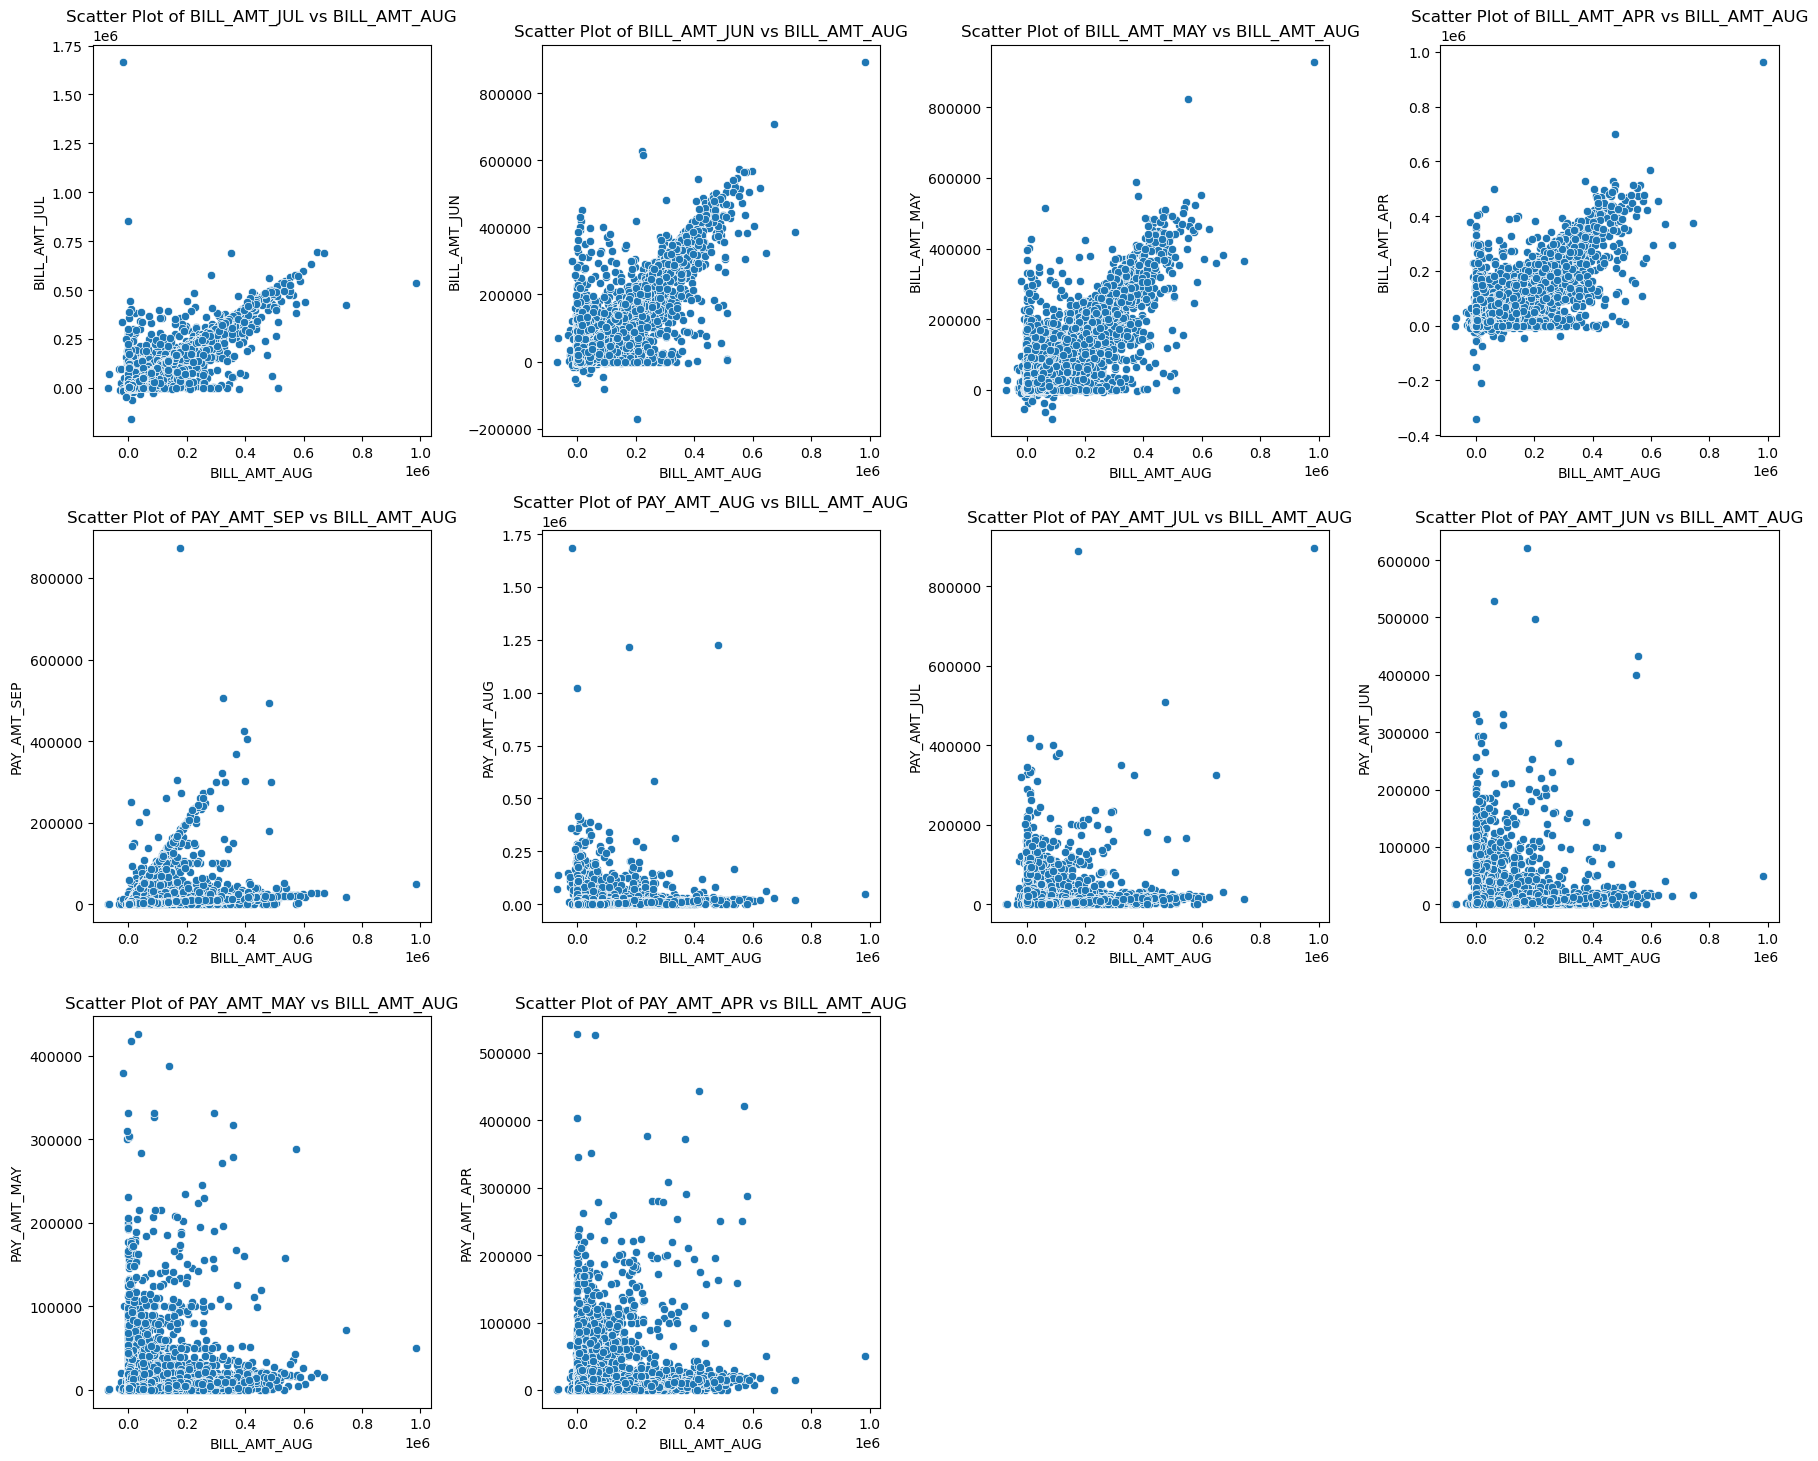

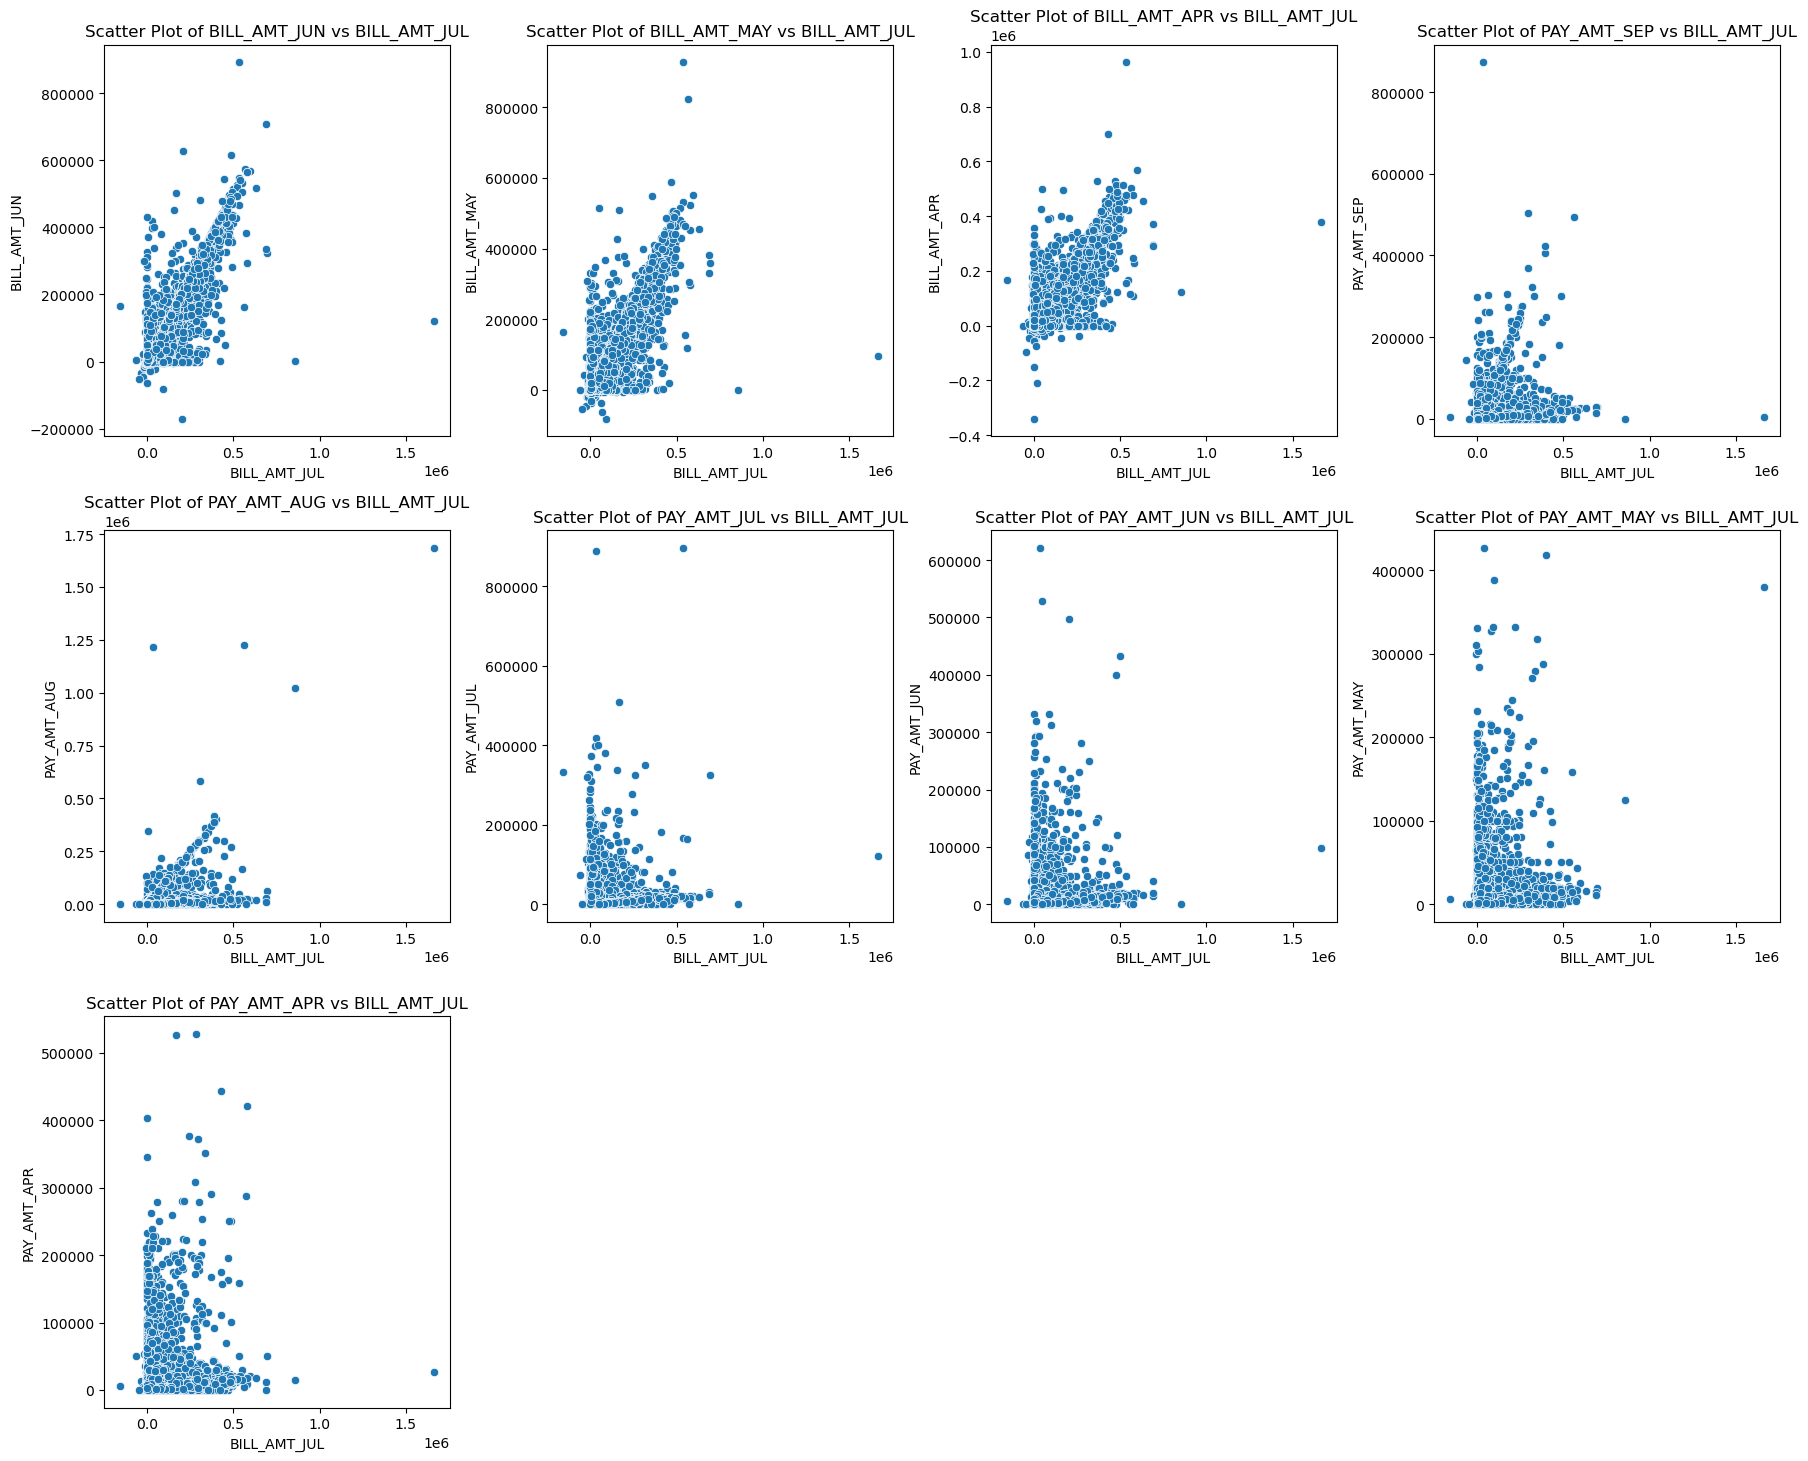

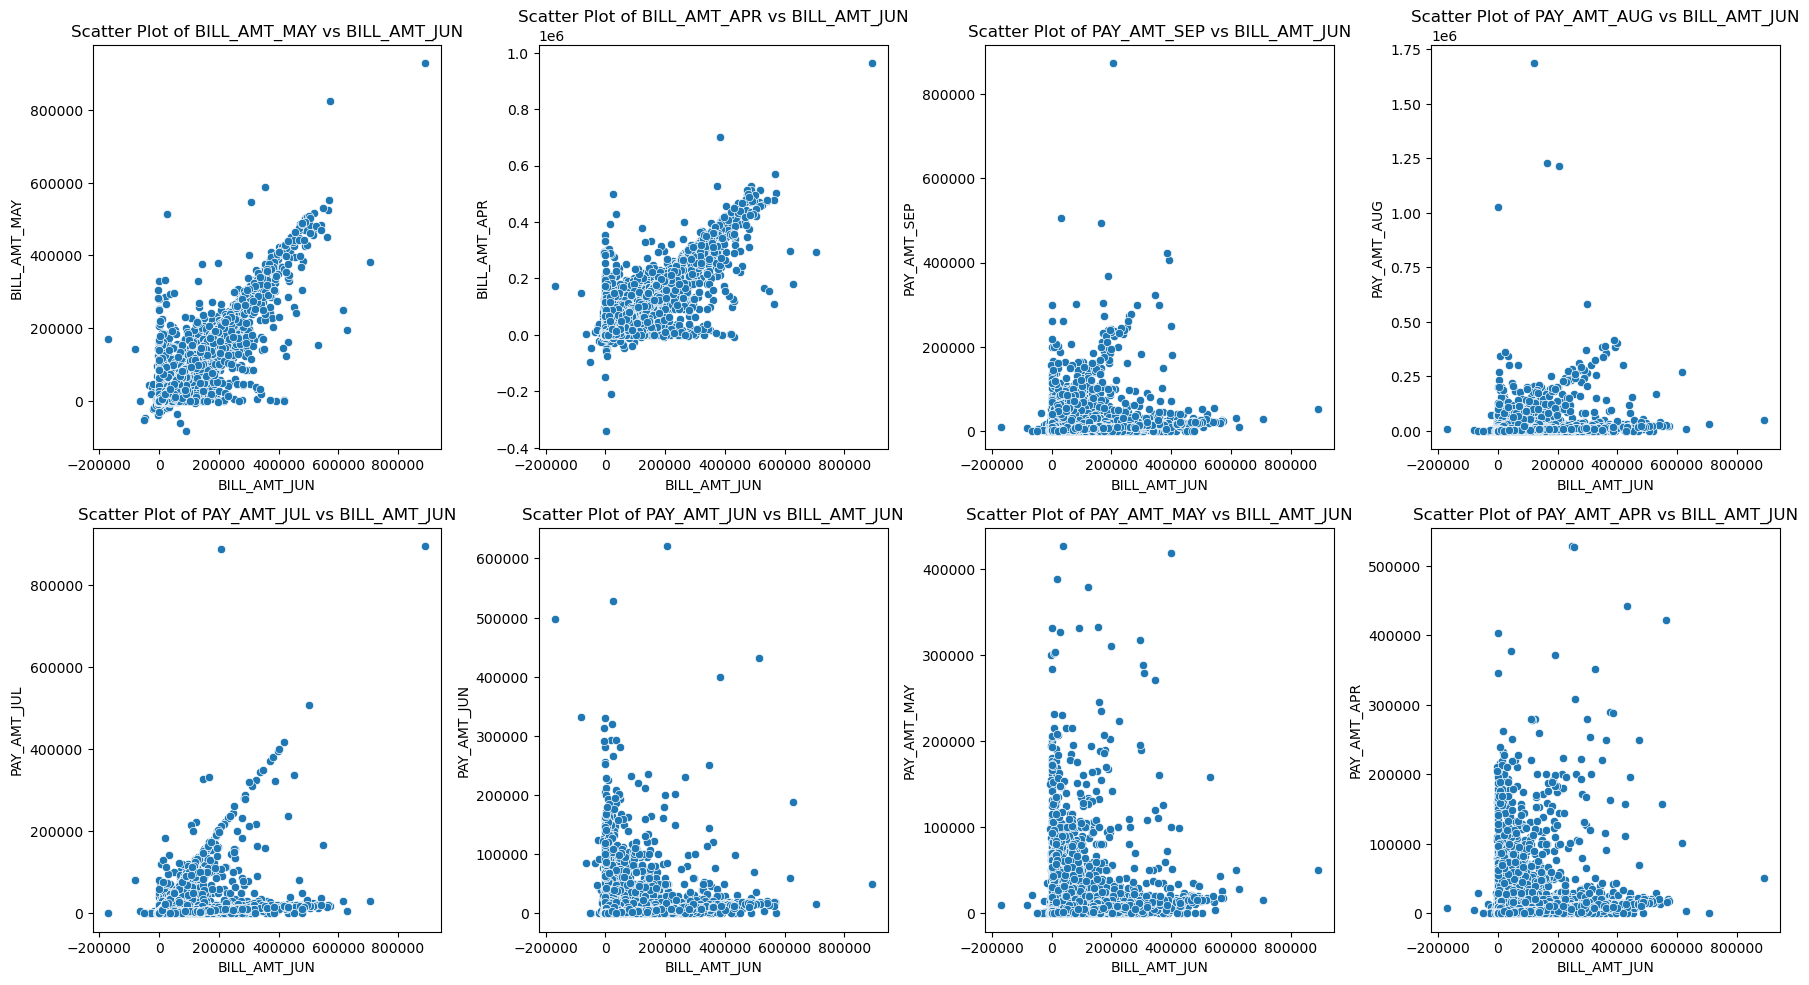

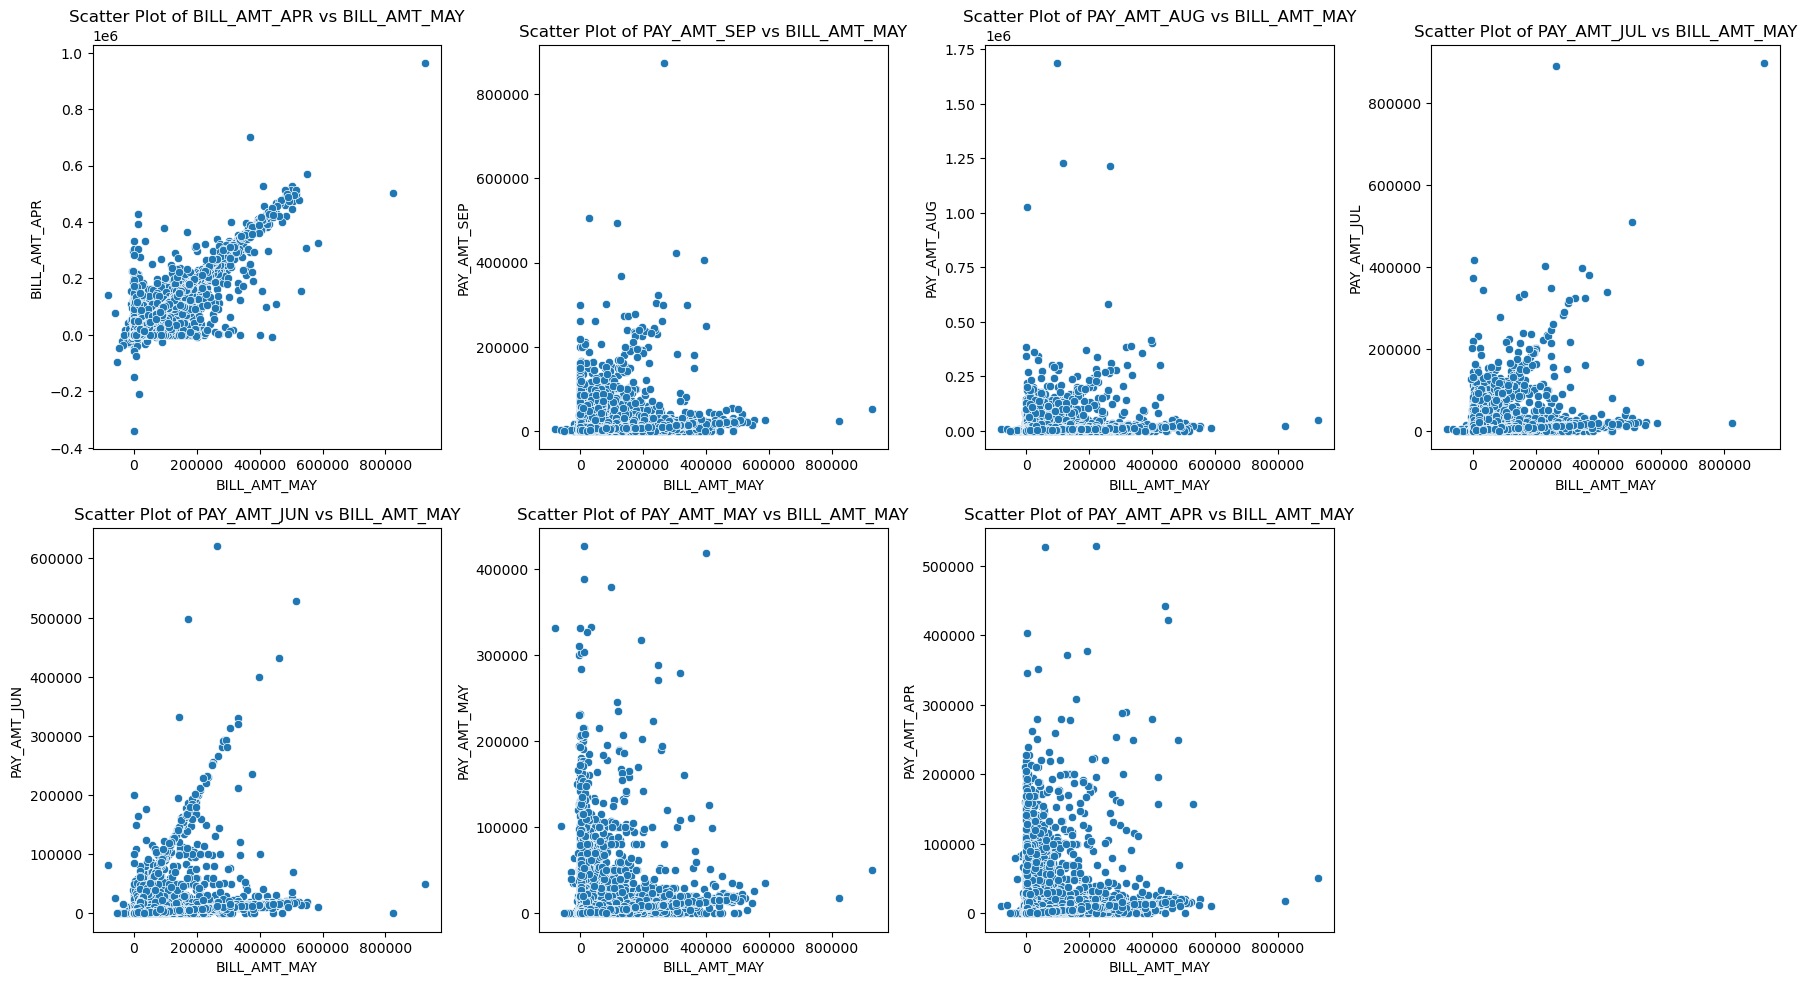

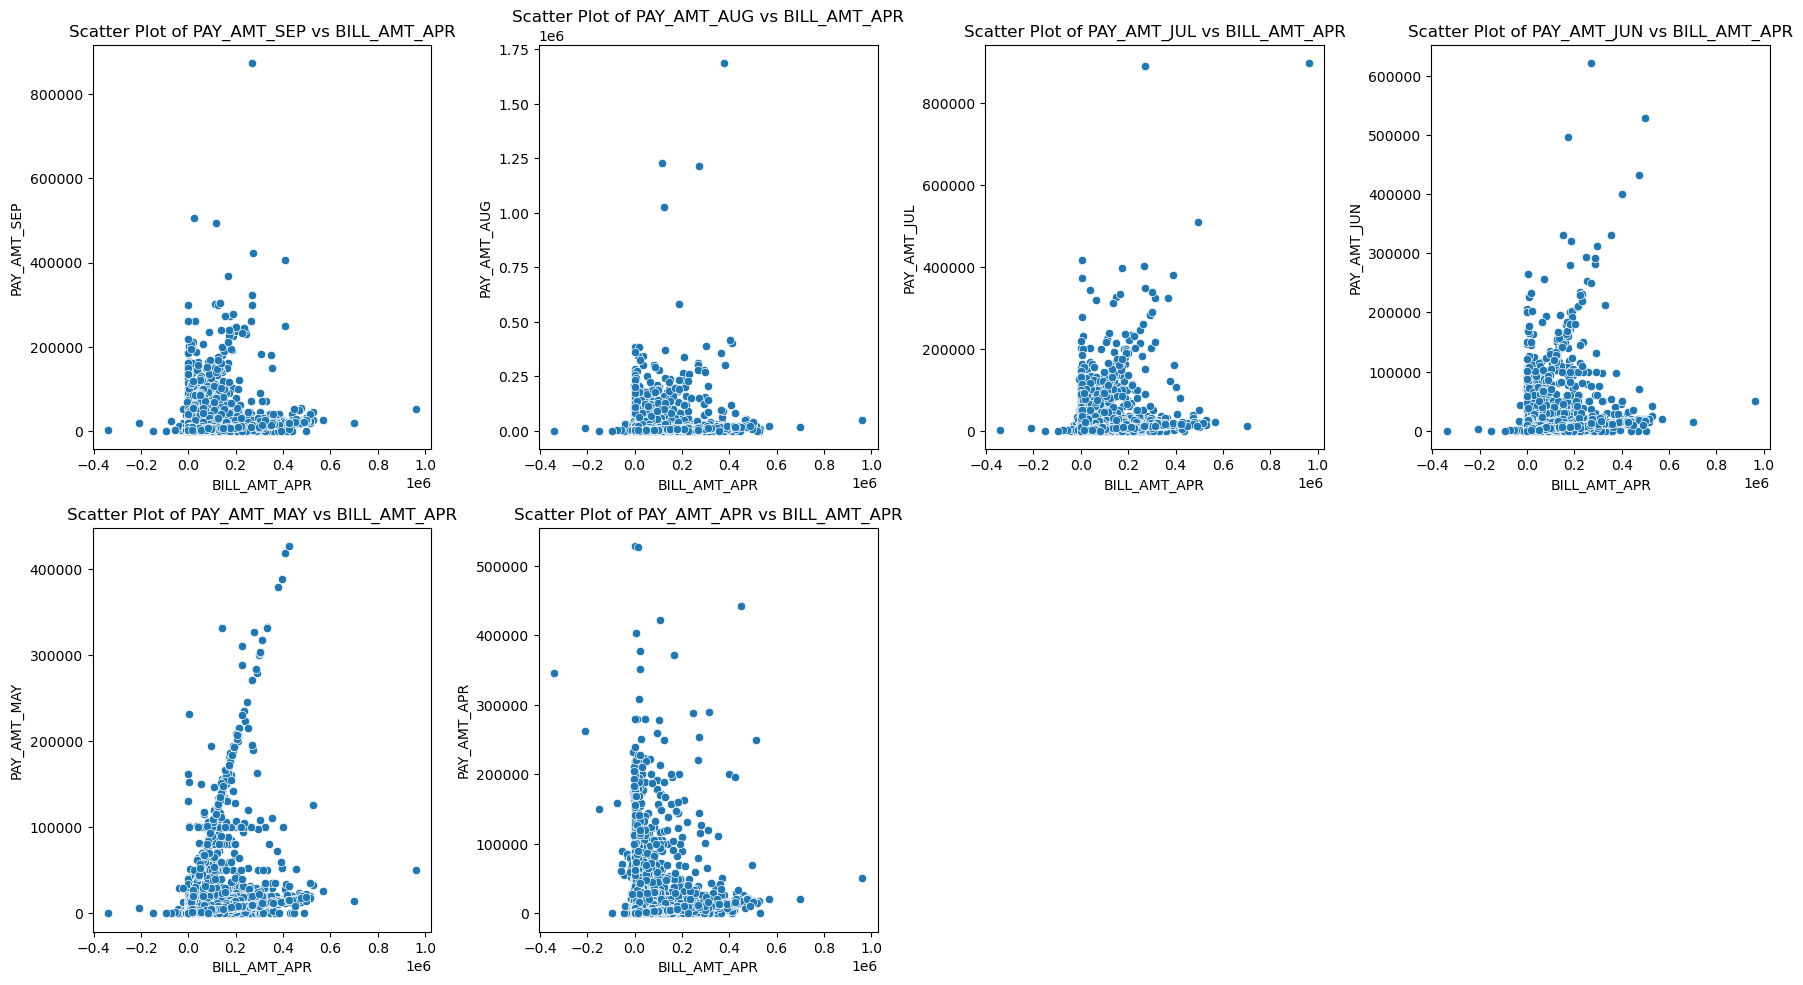

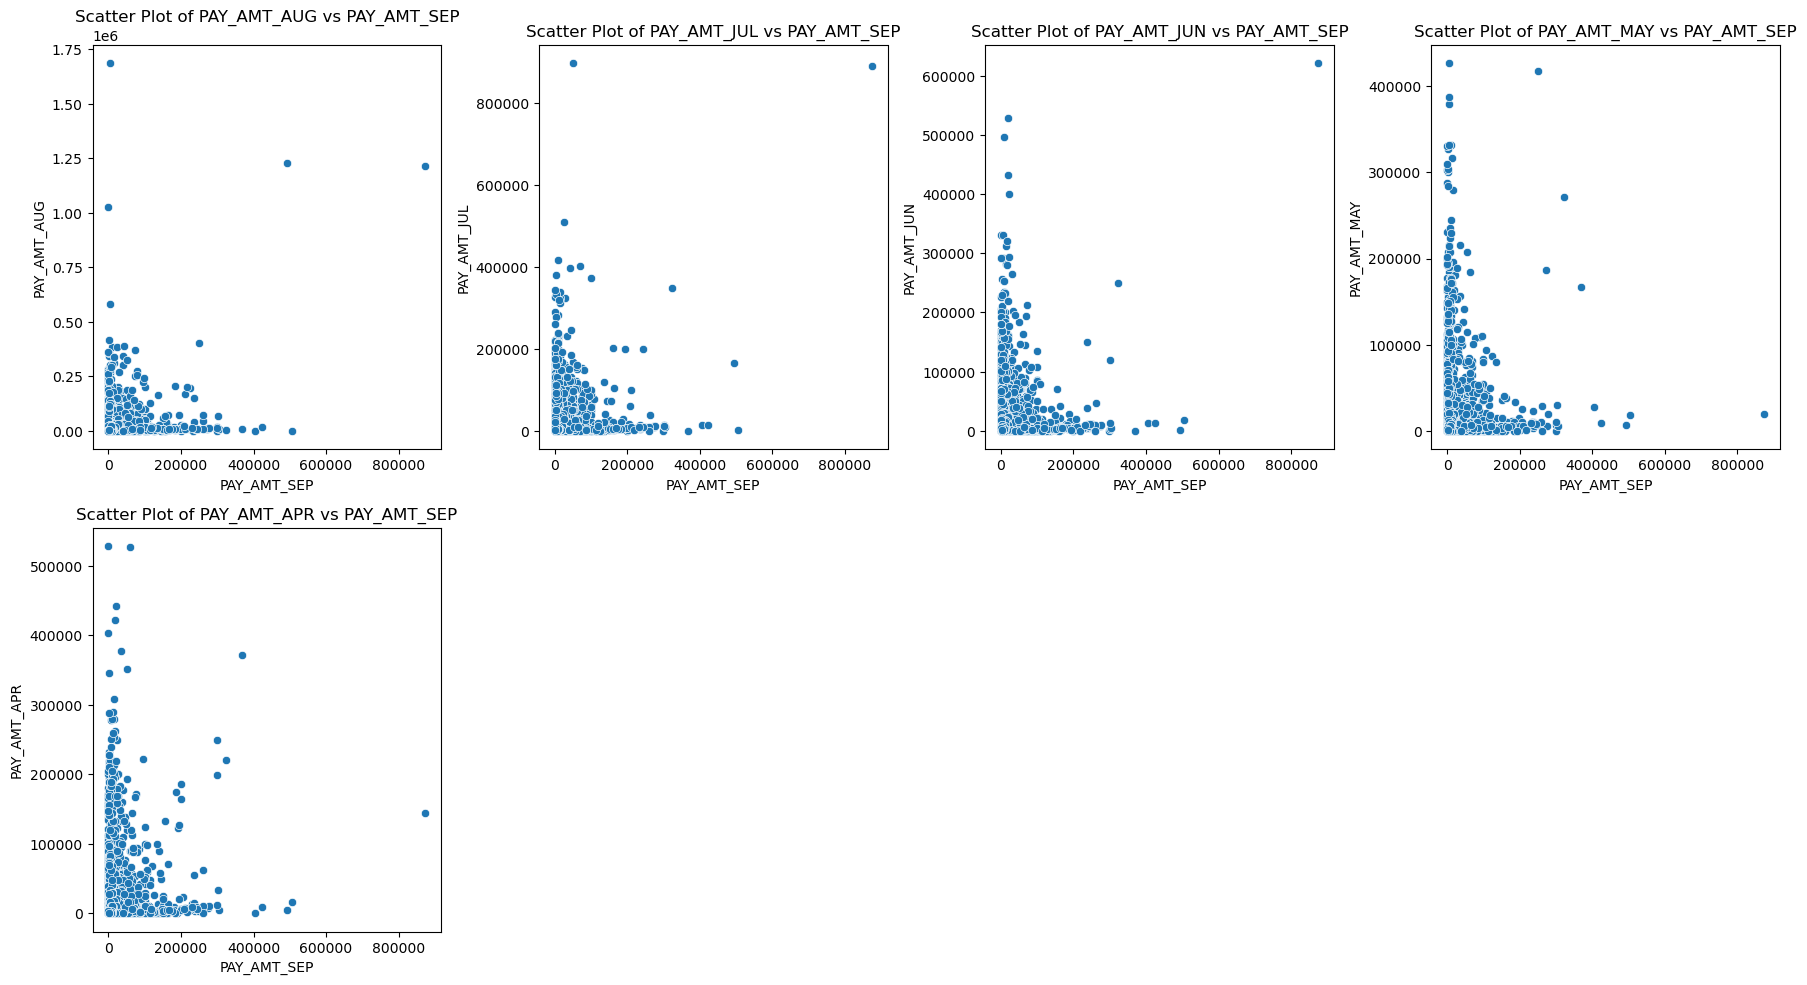

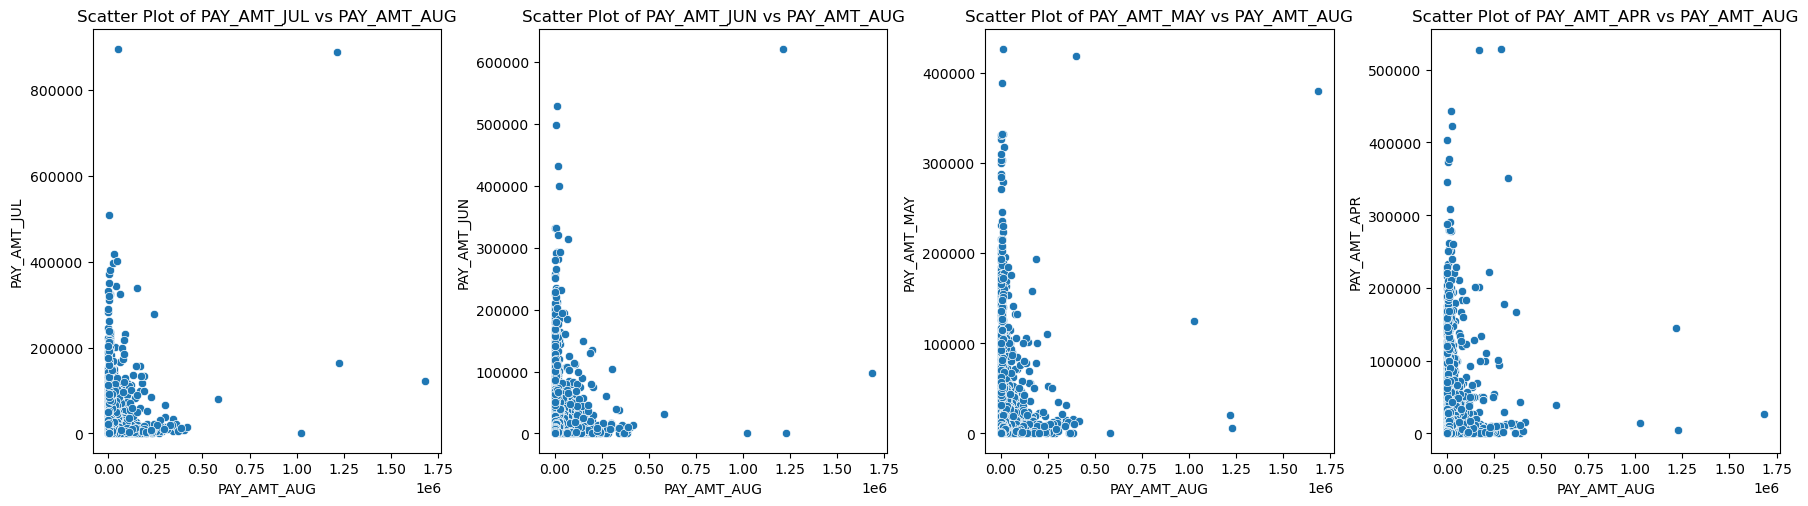

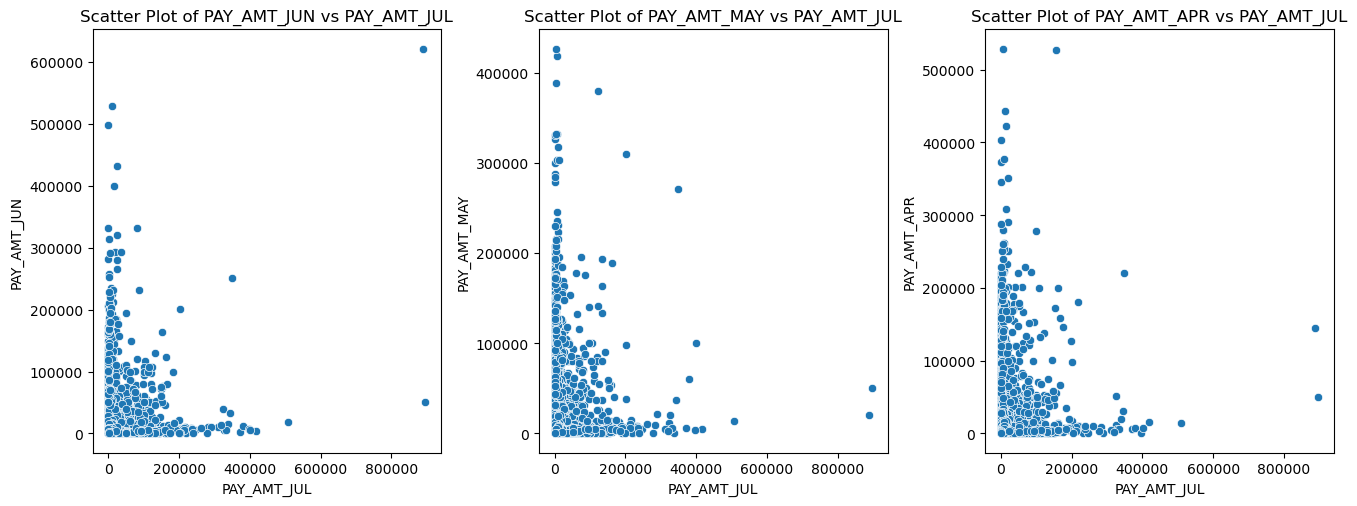

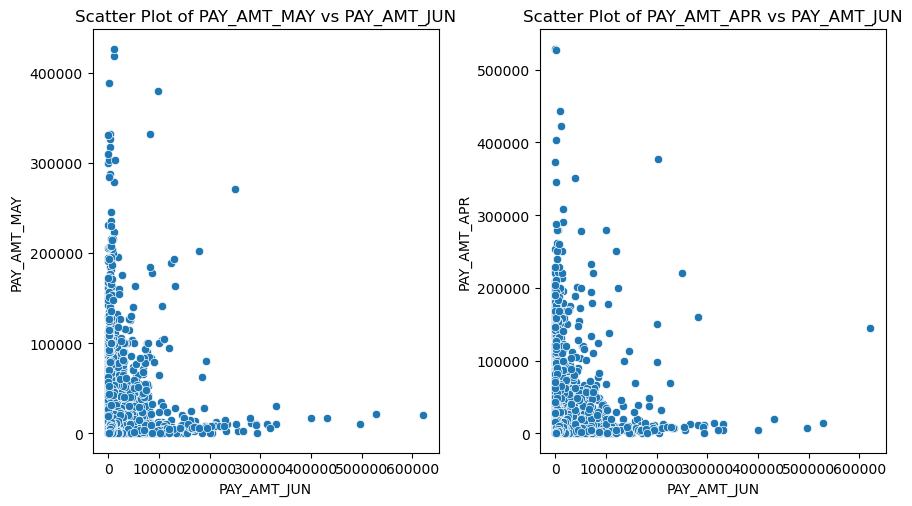

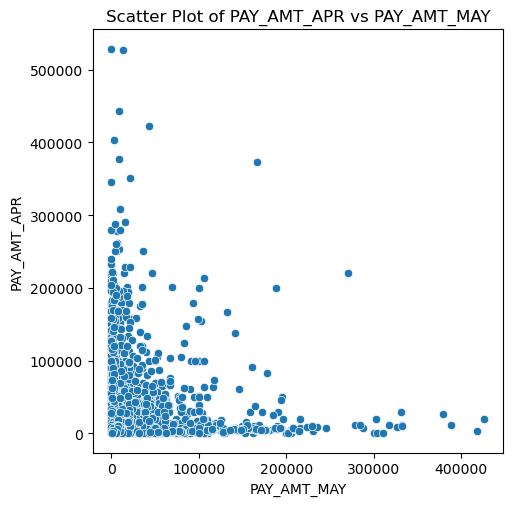

<Figure size 1800x2400 with 0 Axes>

In [35]:
n_rows = 5
n_cols = 4

used_field = []

# Loop through pairs of categorical columns
for i, col1 in enumerate(credit_numeric_features.drop("ID", axis=1)):
    used_field.append(col1)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 24))
    axes = axes.flatten()  

    plot_idx = 0  
    for j, col2 in enumerate(credit_numeric_features.drop("ID", axis=1)):
        if col2 not in used_field and i != j:
            sns.scatterplot(x=col1, y=col2, data=credit, ax=axes[plot_idx])
            axes[plot_idx].set_title(f'Scatter Plot of {col2} vs {col1}')
            axes[plot_idx].set_xlabel(col1)
            axes[plot_idx].set_ylabel(col2)
            plot_idx += 1
            if plot_idx >= n_rows * n_cols:
                break 

    # Remove any unused subplots
    for idx in range(plot_idx, n_rows * n_cols):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()


## Analysis of Numerical vs Numerical Category
### (Bill_Amt_X and Pay_Amt_X)

Slight linear relationship between bill amounts of consecutive months (like Bill_amt_aug and Bill_Amt_Sep).
Indicates growing expenses like subscriptions, utility costs, or rising credit card balances.

Positive relationship between bill amount of one month and payment amount of the next month.
Suggests proportional payments: higher bills lead to higher payments.



# Numerical value vs DEFAULT

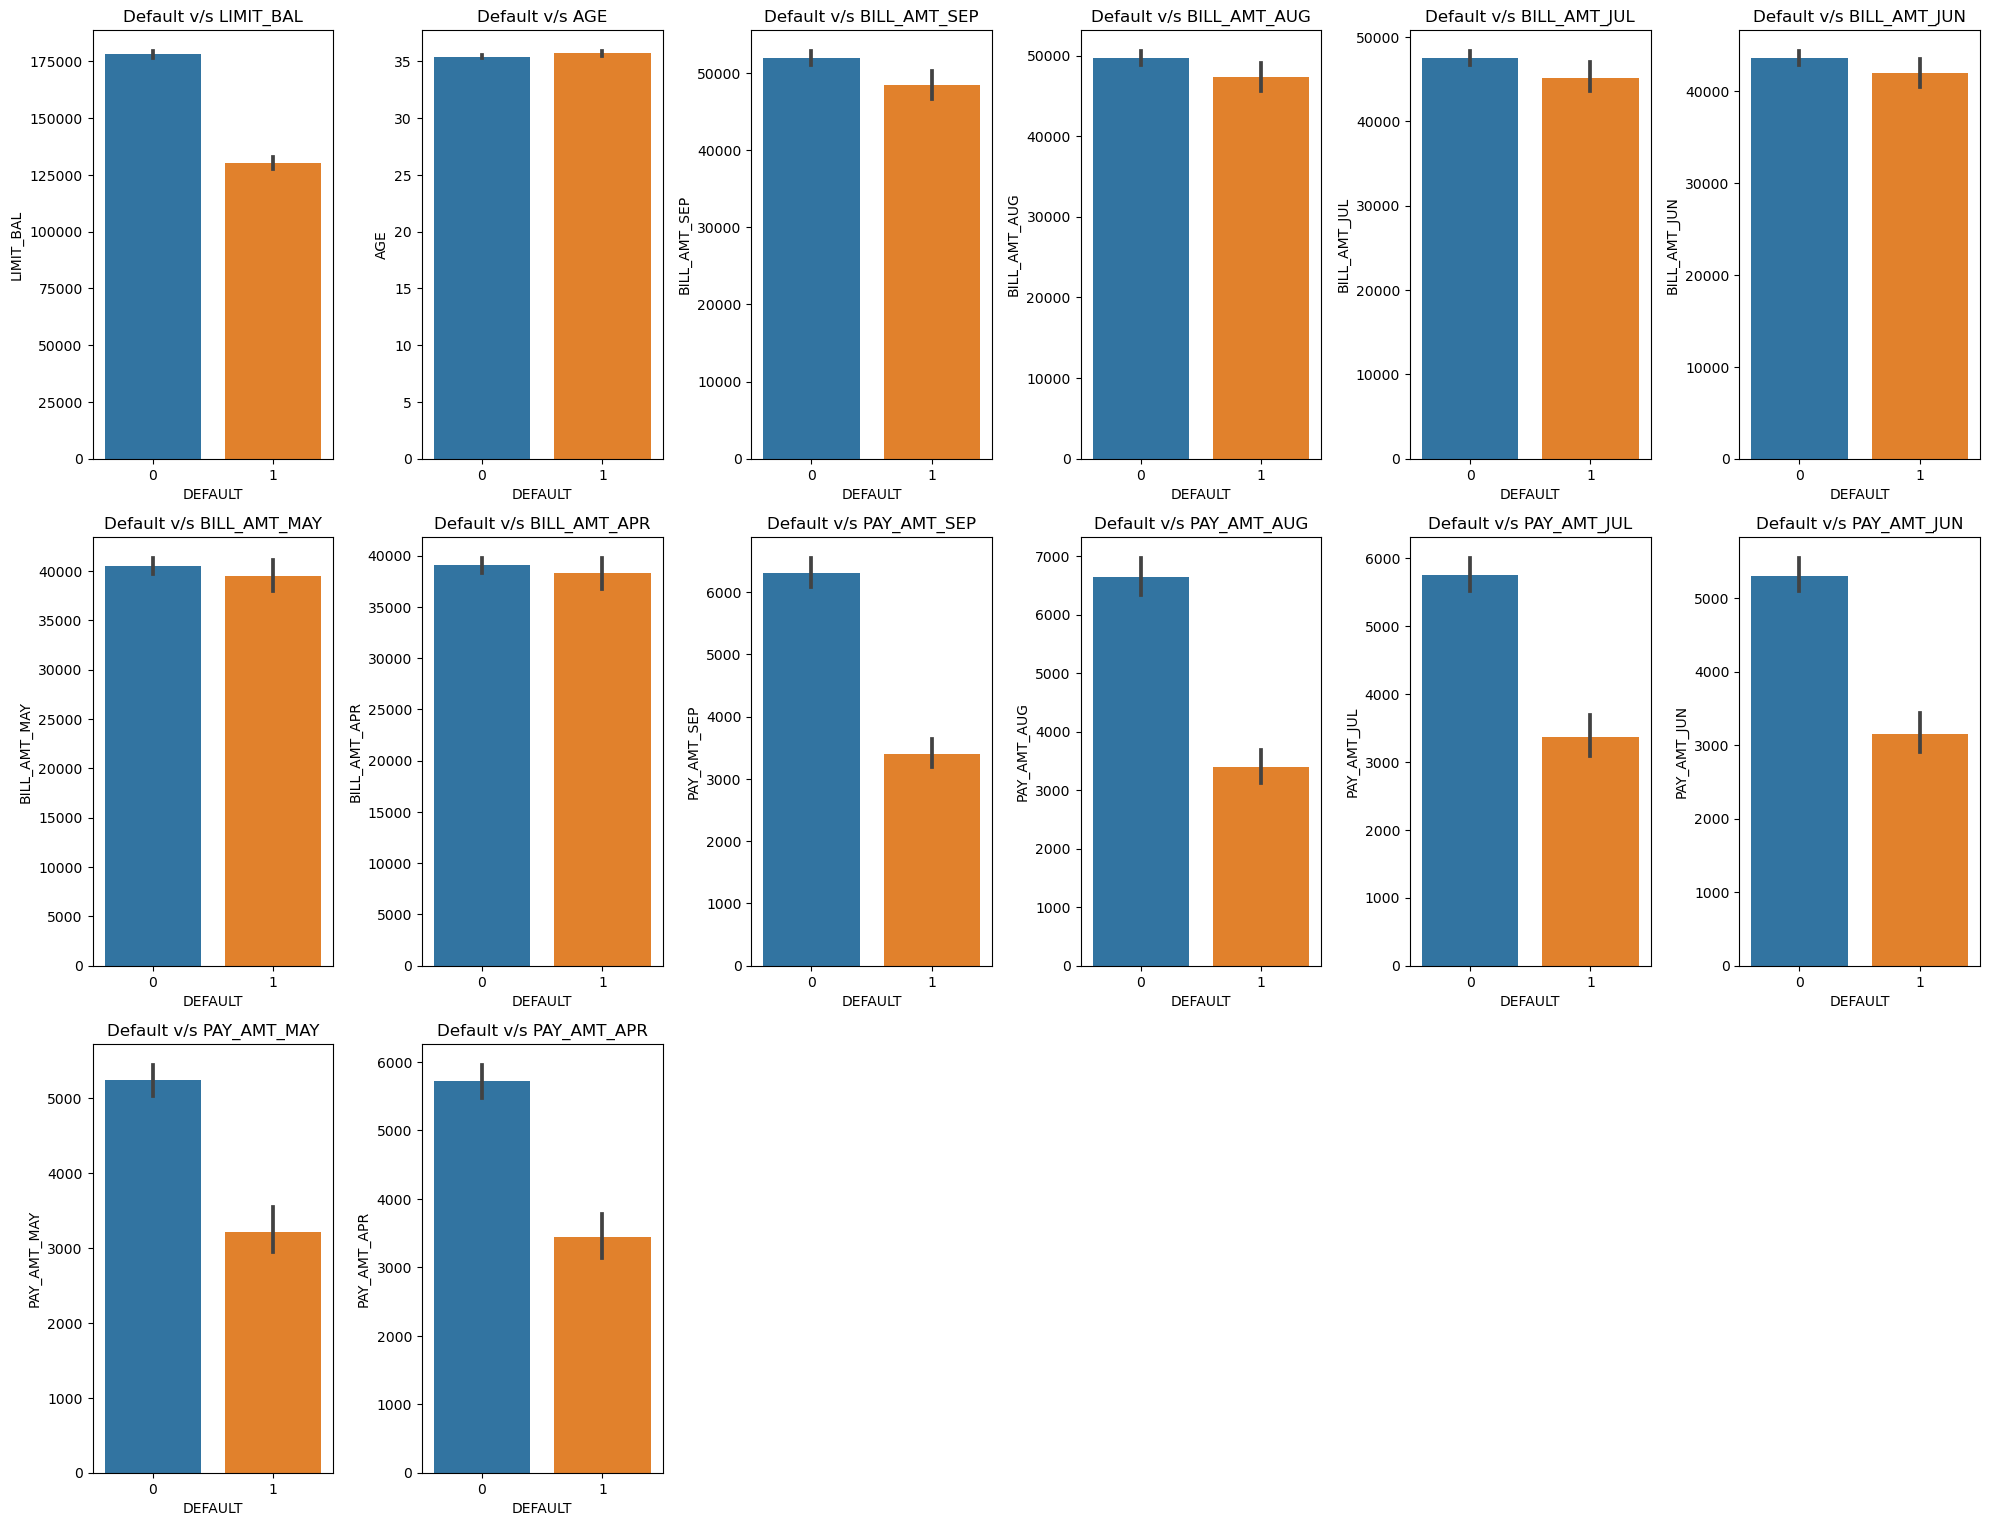

In [36]:
plt.figure(figsize=(20,20))
counter=1

for var in credit_numeric_features.drop("ID",axis =1):
  plt.subplot(4,6,counter)
  sns.barplot(x=credit['DEFAULT'],y=credit[var])
  plt.title(f'Default v/s {var}')
  counter=counter+1
  plt.tight_layout()

### Analysis

###### LIMIT_BAL (Credit Limit):
The average credit limit appears to be higher for non-defaulting customers compared to those who defaulted.
###### AGE:
The age distribution for defaulting and non-defaulting customers seems fairly similar, though non-defaulting customers might have a slight edge in average age.
###### BILL_AMT1 to BILL_AMT6 (Bill Statement Amounts):
There doesn't seem to be a strong visible difference between defaulting and non-defaulting customers in terms of their bill amounts.
###### PAY_AMT1 to PAY_AMT6 (Payment Amounts):
Non-defaulting customers generally make higher payments across the different months.

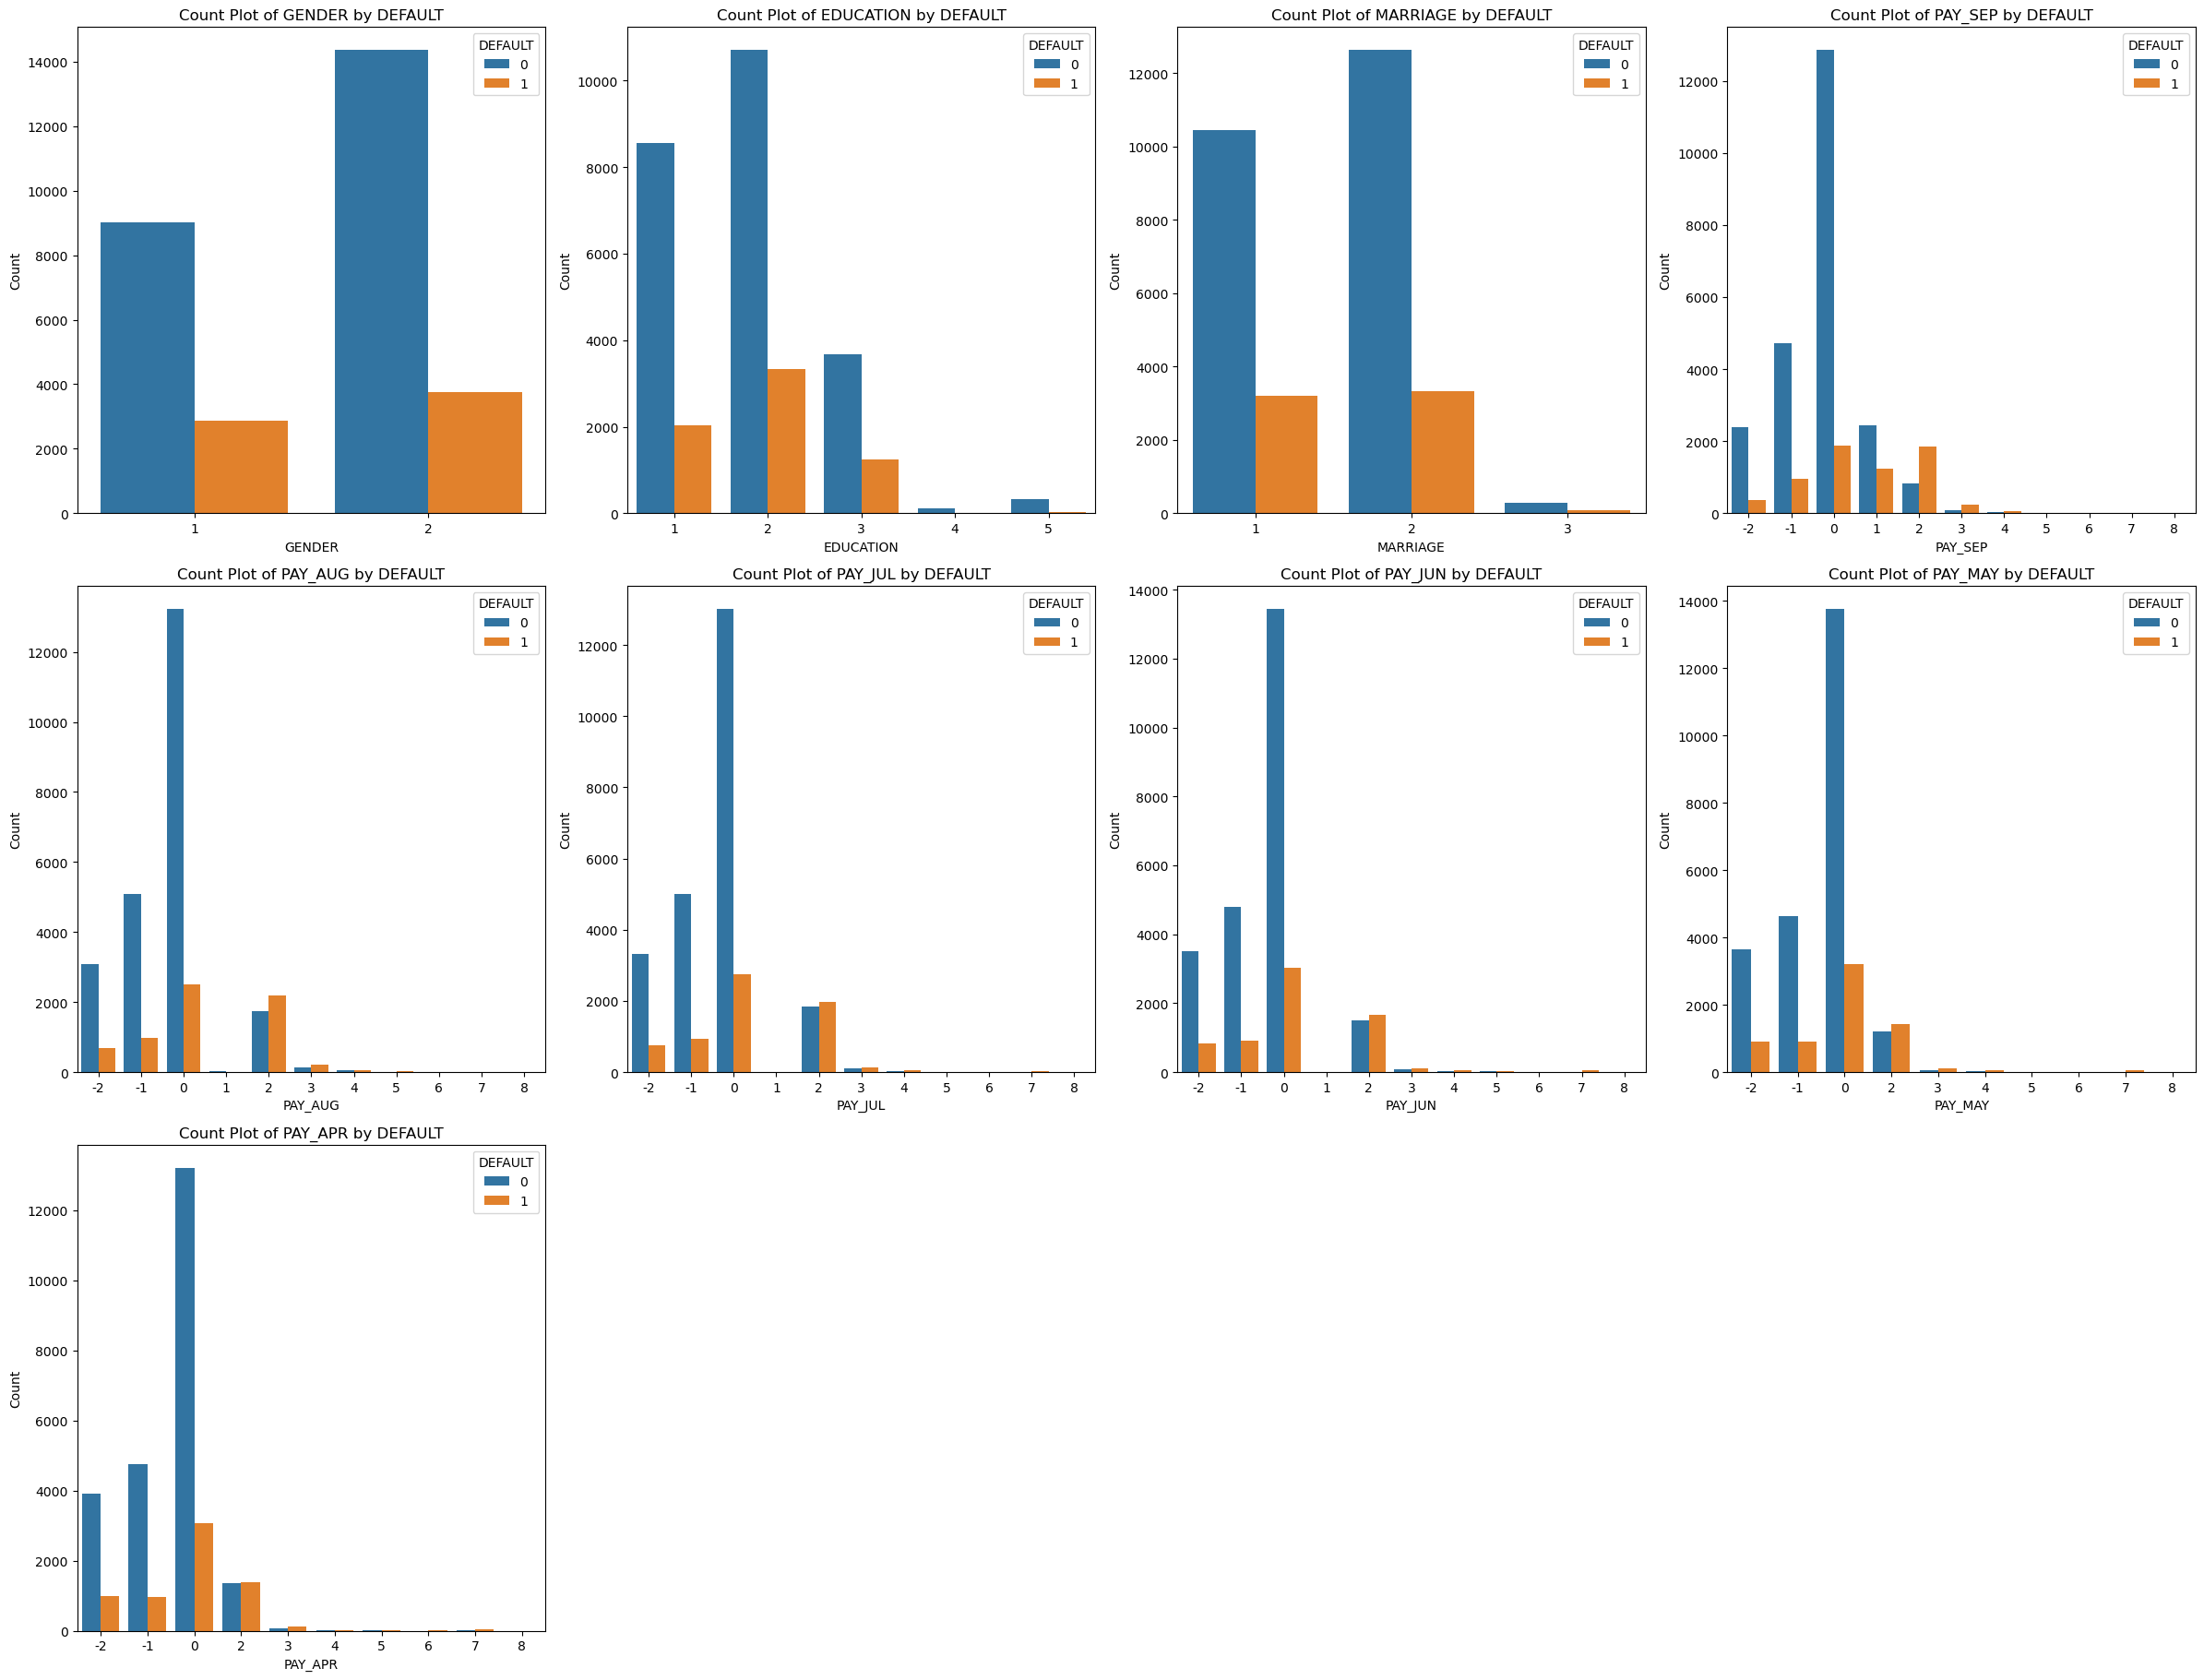

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

n_rows = 5
n_cols = 4 

# Create a list of categorical columns excluding 'DEFAULT'
categoric_features = credit_categoric_features.drop("DEFAULT", axis=1).columns

# Create subplots for each categorical feature against 'DEFAULT'
for i in range(0, len(categoric_features), n_rows * n_cols):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 30))
    axes = axes.flatten()  # Flatten the axes array for easy iteration
    
    for plot_idx, col in enumerate(categoric_features[i:i + n_rows * n_cols]):
        sns.countplot(x=col, hue='DEFAULT', data=credit, ax=axes[plot_idx])
        axes[plot_idx].set_title(f'Count Plot of {col} by DEFAULT')
        axes[plot_idx].set_xlabel(col)
        axes[plot_idx].set_ylabel('Count')
        axes[plot_idx].legend(title='DEFAULT')
    
    for idx in range(plot_idx + 1, n_rows * n_cols):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()


###### SEX:
There doesn't appear to be a significant difference in default rates between males and females.
###### EDUCATION:
Customers with higher education levels (1 and 2) have lower default rates compared to those with lower education levels (3 and 4).
###### MARRIAGE:
Single customers (category 2) seem to have a higher default rate compared to married customers (category 1). The 'others' category (3) also has a higher default rate.
###### PAY_0 to PAY_6 (Past Payment Status):
These features shows that higher past payment statuses (indicating more delayed payments) are more prevalent among defaulting customers.

## Heat Map Visualization

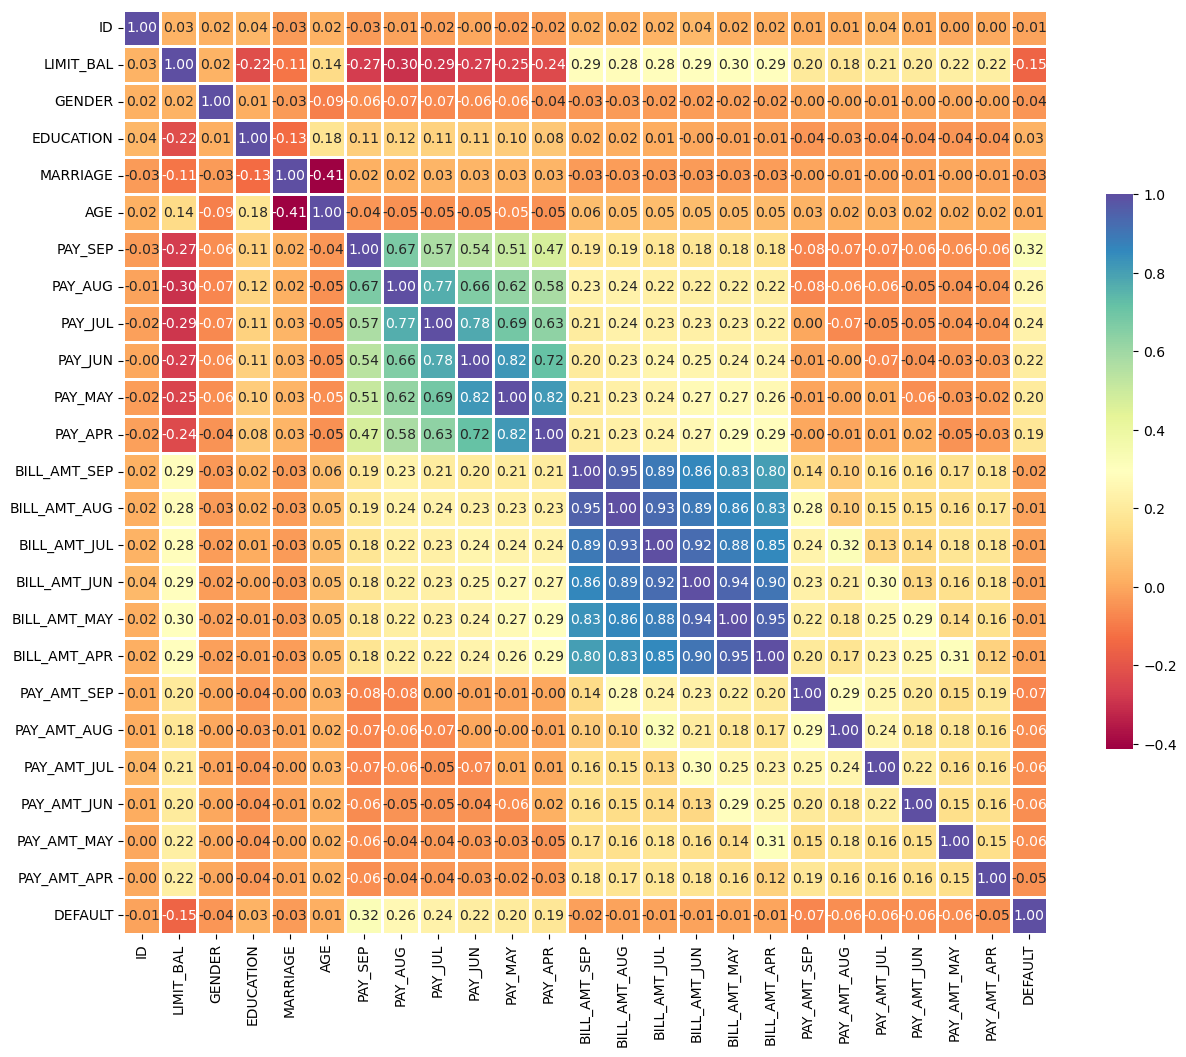

In [38]:
# Correlation Heatmap visualization code
plt.figure(figsize=(15,12))
sns.heatmap(credit.corr(), cmap="Spectral", cbar_kws={'shrink': .6}, square=True, annot=True, fmt='.2f', linewidths=.8)
plt.show()

We can see a multicolinearity in bill amounts, other than that there are not much multi colinearity seen in the data set among other fields
From the above corelation plot we can see that bill_amt april to september columns are highly correlated to each other which makes sense as these columns indicates the bill amounts.

Apart from that there are no highly correlated inputs in our dataset, so there is no multicollinearity problem.

## Anomalies


In [39]:
### Possible case
# have not defaulted in last 6 months but are still marked as defaulters

credit_anom1 = credit[(credit.PAY_APR < 1) & (credit.PAY_MAY < 1) & (credit.PAY_JUN < 1) & # Not defaulted for last 6 months
       (credit.PAY_JUL < 1) & (credit.PAY_AUG < 1) & (credit.PAY_SEP < 1) & 
       (credit.DEFAULT == 1)] # marked as defaulters
credit_anom1


,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,...,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
21,22,120000.0,2,2,1,39,-1,-1,-1,-1,...,0.0,632.0,316.0,316.0,316.0,0.0,632.0,316.0,0.0,1
23,24,450000.0,2,1,1,40,-2,-2,-2,-2,...,560.0,0.0,0.0,19428.0,1473.0,560.0,0.0,0.0,1128.0,1
45,46,210000.0,1,1,2,29,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
47,48,150000.0,2,5,2,46,0,0,-1,0,...,1170.0,0.0,0.0,1013.0,1170.0,0.0,0.0,0.0,0.0,1
60,61,500000.0,2,3,1,28,0,0,0,0,...,14937.0,13827.0,15571.0,1516.0,1300.0,1000.0,1000.0,2000.0,2000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29929,29930,170000.0,1,3,1,46,-1,-1,-1,-1,...,1804.0,3608.0,1804.0,1804.0,1804.0,1804.0,3608.0,0.0,1804.0,1
29935,29936,50000.0,1,2,1,48,0,0,0,-1,...,49161.0,6690.0,5665.0,46895.0,1775.0,51209.0,428.0,5665.0,8745.0,1
29942,29943,130000.0,1,3,1,45,-1,-1,-1,-1,...,2756.0,1585.0,1215.0,1826.0,2831.0,2756.0,1585.0,1215.0,2402.0,1
29982,29983,90000.0,1,2,1,36,0,0,0,0,...,11328.0,12036.0,14329.0,1500.0,1500.0,1500.0,1200.0,2500.0,0.0,1


## Handling Outliers

In [40]:
cols = credit.columns
cols

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEP',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT_SEP',
       'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY',
       'BILL_AMT_APR', 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL',
       'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR', 'DEFAULT'],
      dtype='object')

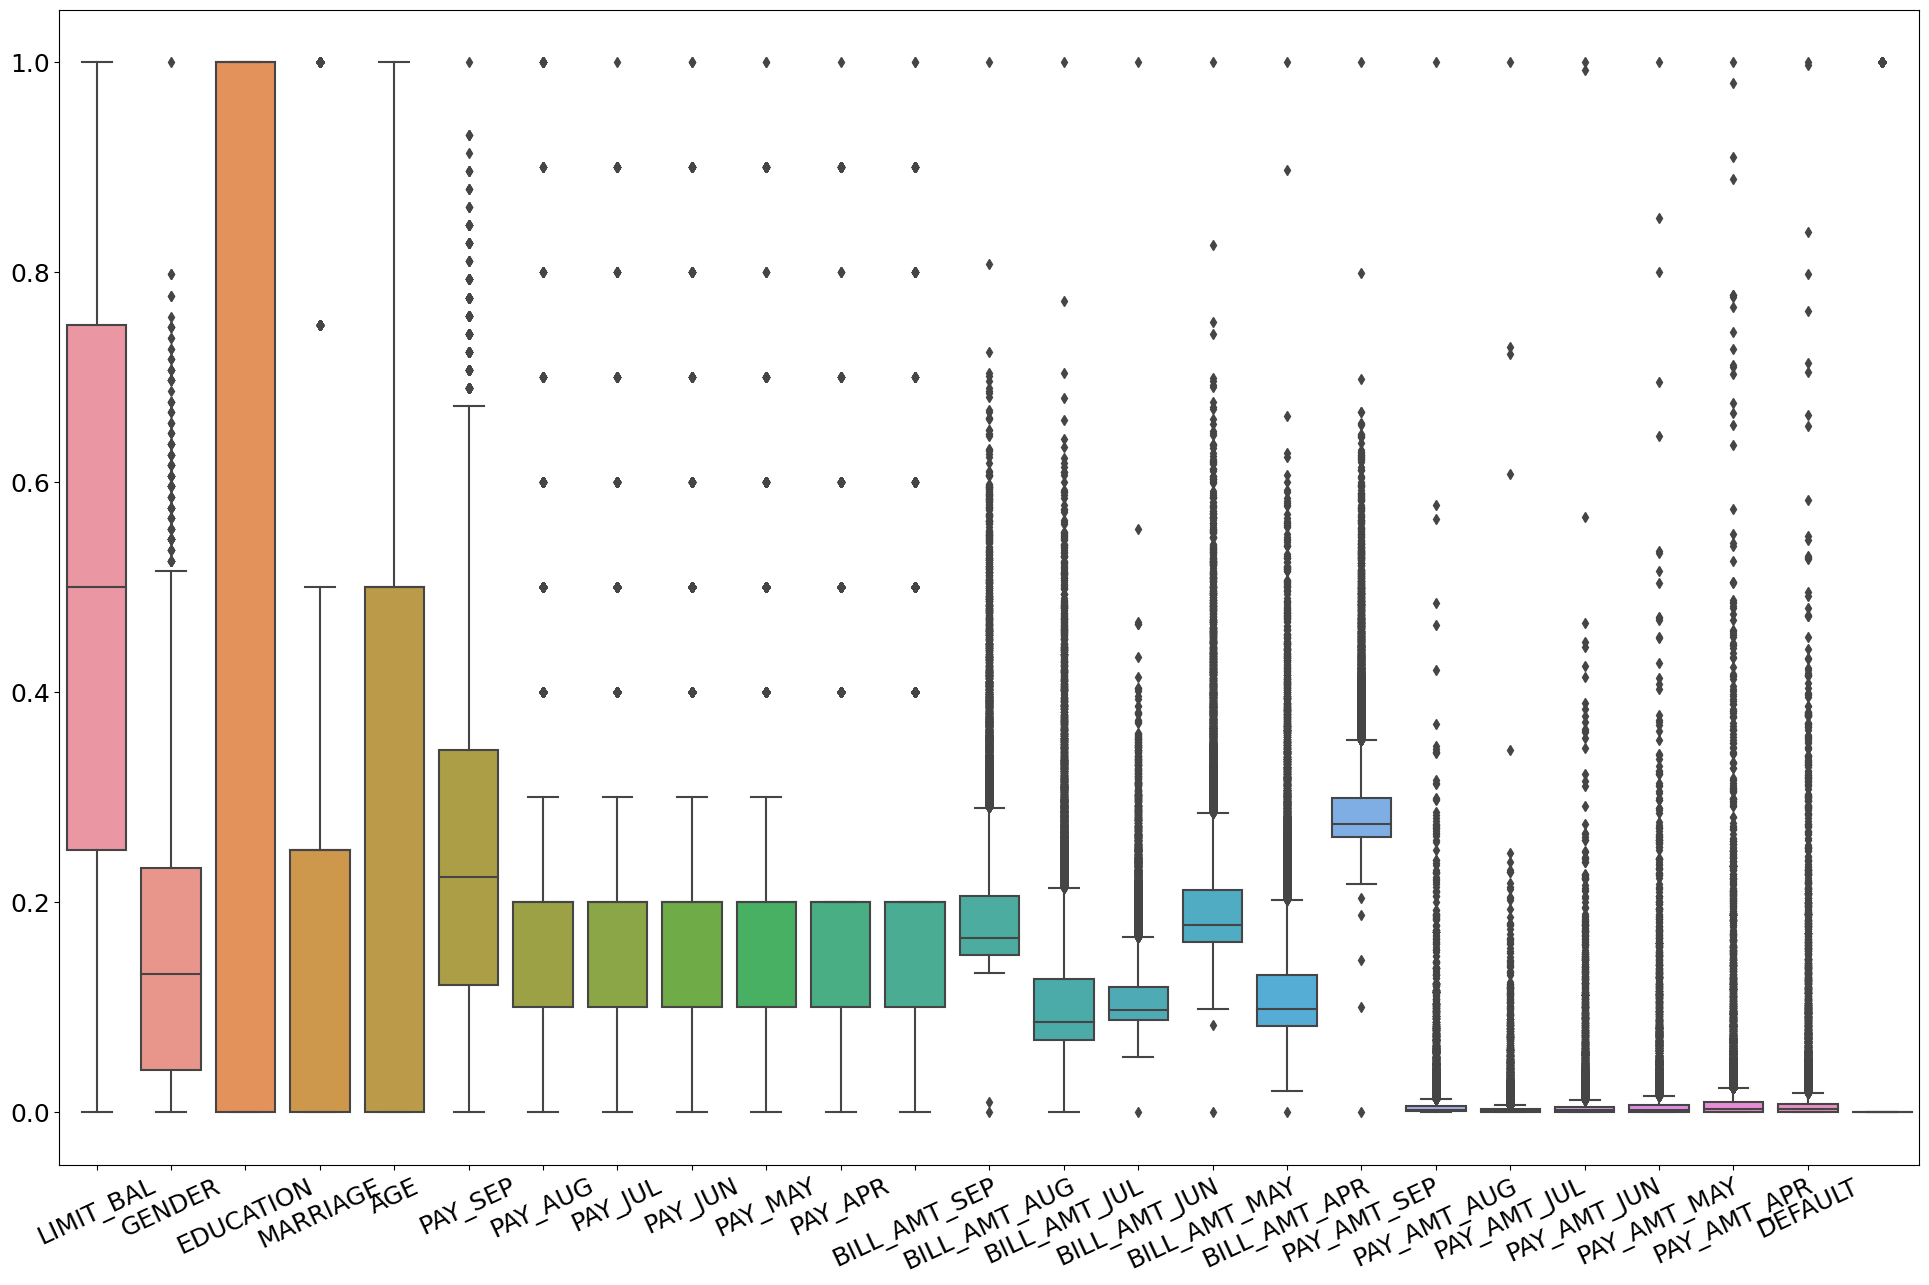

In [41]:
# Handling Outliers & Outlier treatments
#Checking for outliers
#applying min max scaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(credit)

cols = ['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEP',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT_SEP',
       'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY',
       'BILL_AMT_APR', 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL',
       'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR','DEFAULT']

fig=plt.figure(1, figsize=(24,15))
ax=fig.add_subplot(111)
sns.boxplot(data=scaled_data)
plt.xticks(np.arange(0,24), labels=cols, rotation=25, fontsize=18)
plt.yticks(fontsize=18)

plt.savefig('Fig - Boxplot')

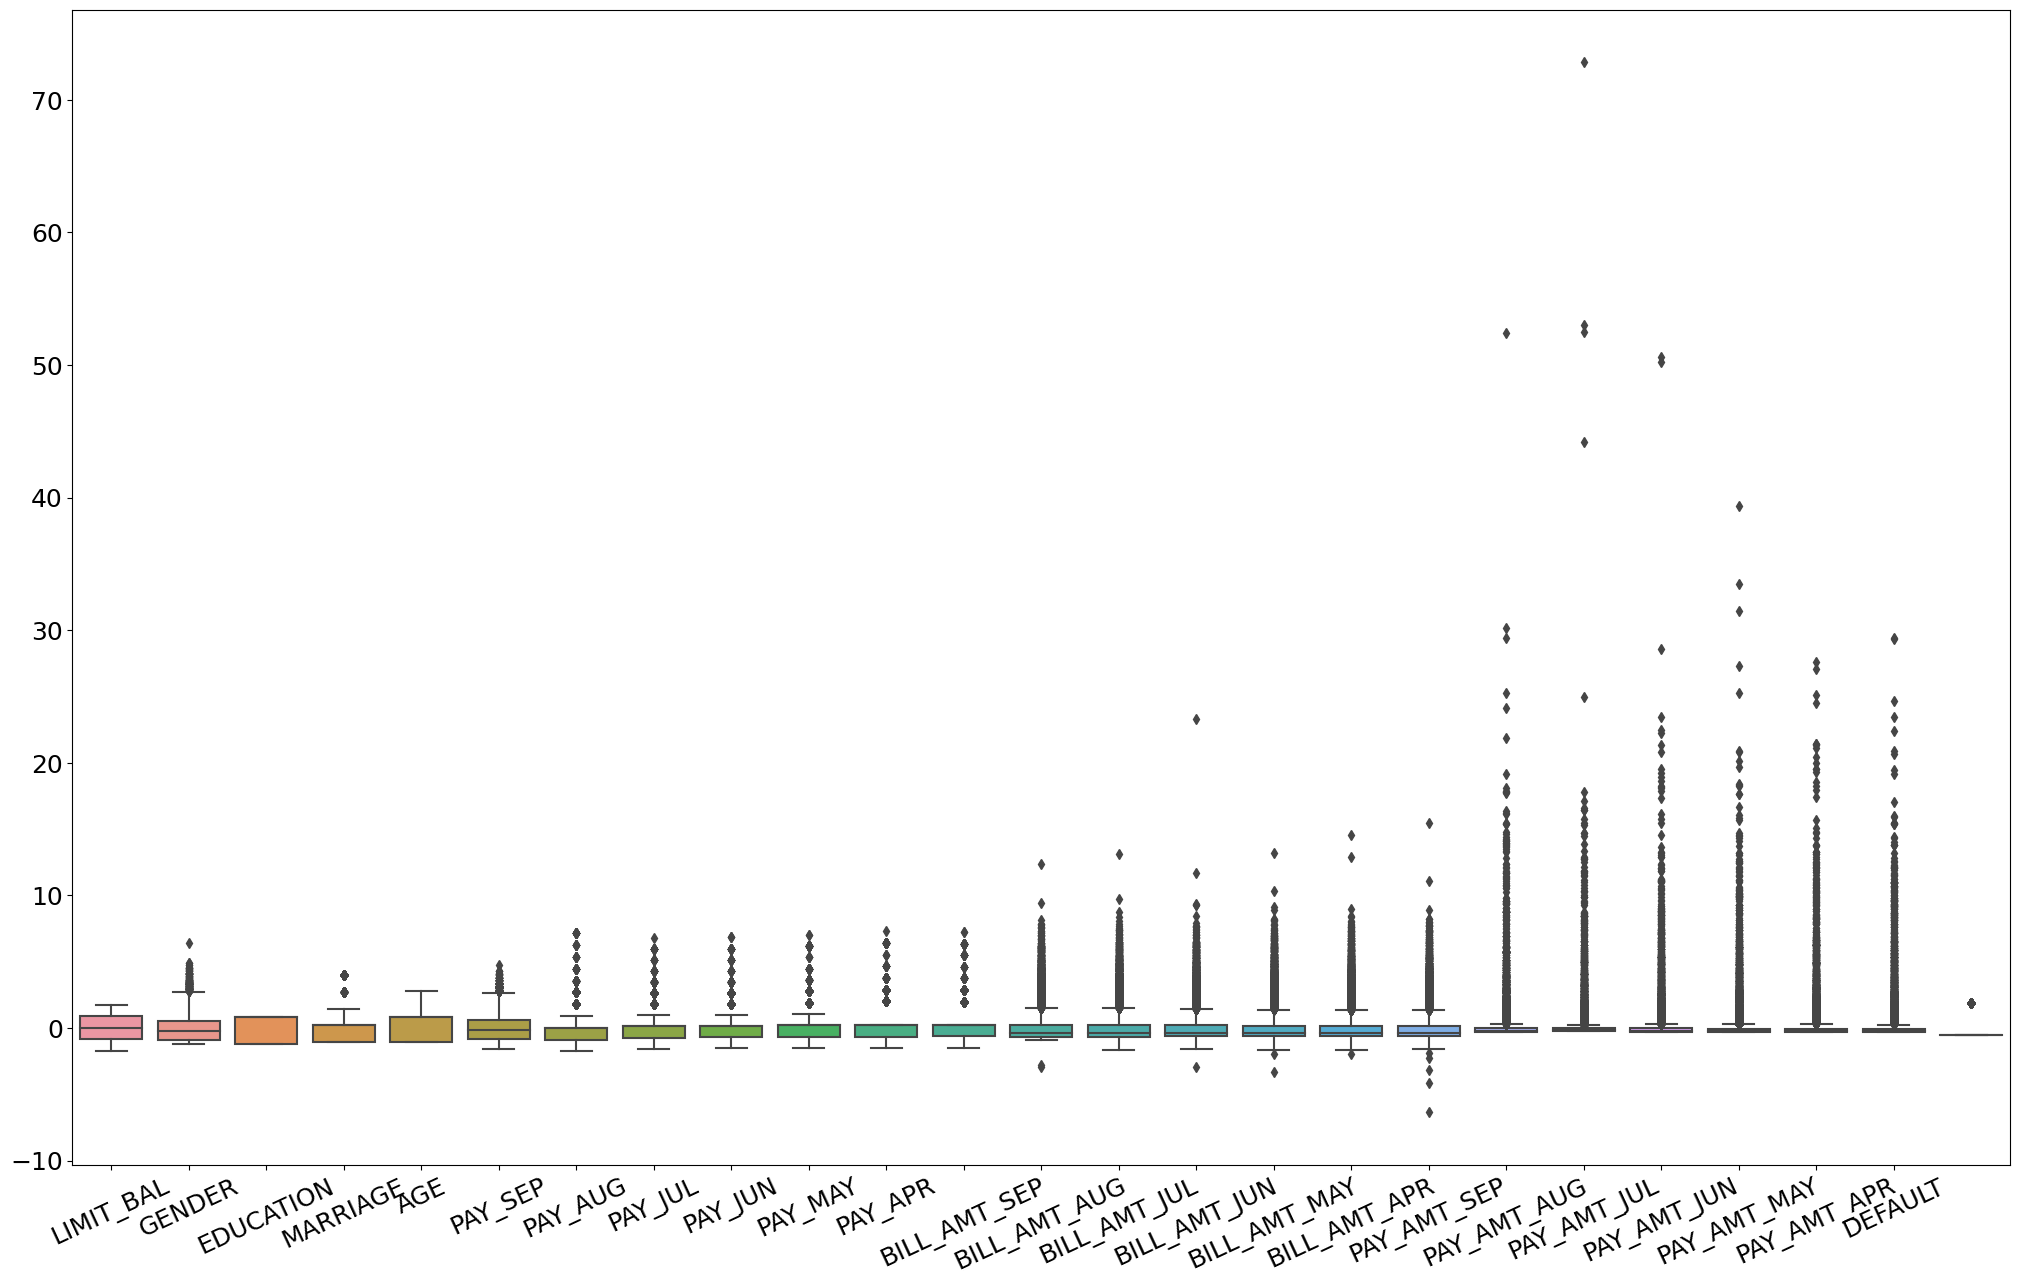

In [42]:
#applying standard scaler
scaler = StandardScaler()
scaled_data_1 = scaler.fit_transform(credit)

cols = ['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEP',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT_SEP',
       'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY',
       'BILL_AMT_APR', 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL',
       'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR','DEFAULT']


fig=plt.figure(1, figsize=(25,15))
ax=fig.add_subplot(111)
sns.boxplot(data=scaled_data_1)
plt.xticks(np.arange(0,24), labels=cols, rotation=25, fontsize=18)
plt.yticks(fontsize=18)

plt.savefig('Fig - Boxplot Std Scaler')

The boxplots for each of the numerical features are plotted in order to have a further look at the distribution and to eventually spot outliers. Here it can be seen clearly that there are lot of values which rae lying in the outlier section. so to tackle the outliers. Two techniques are applied to the entire data as minmaxscaler, standarscalar 

But we can see that none of the techniques were able to solve the outlier problem completely. In addition to that since there are lot of values in the outliers part so it won't be a good idea to delete all the outliers.

# Feature Manipulation

In [43]:
credit.columns

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEP',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT_SEP',
       'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY',
       'BILL_AMT_APR', 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL',
       'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR', 'DEFAULT'],
      dtype='object')

In [44]:
# the id column is not important for the analysis 
credit = credit.drop('ID',axis = 1)


In [45]:
credit

,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,...,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


# Feature Selection

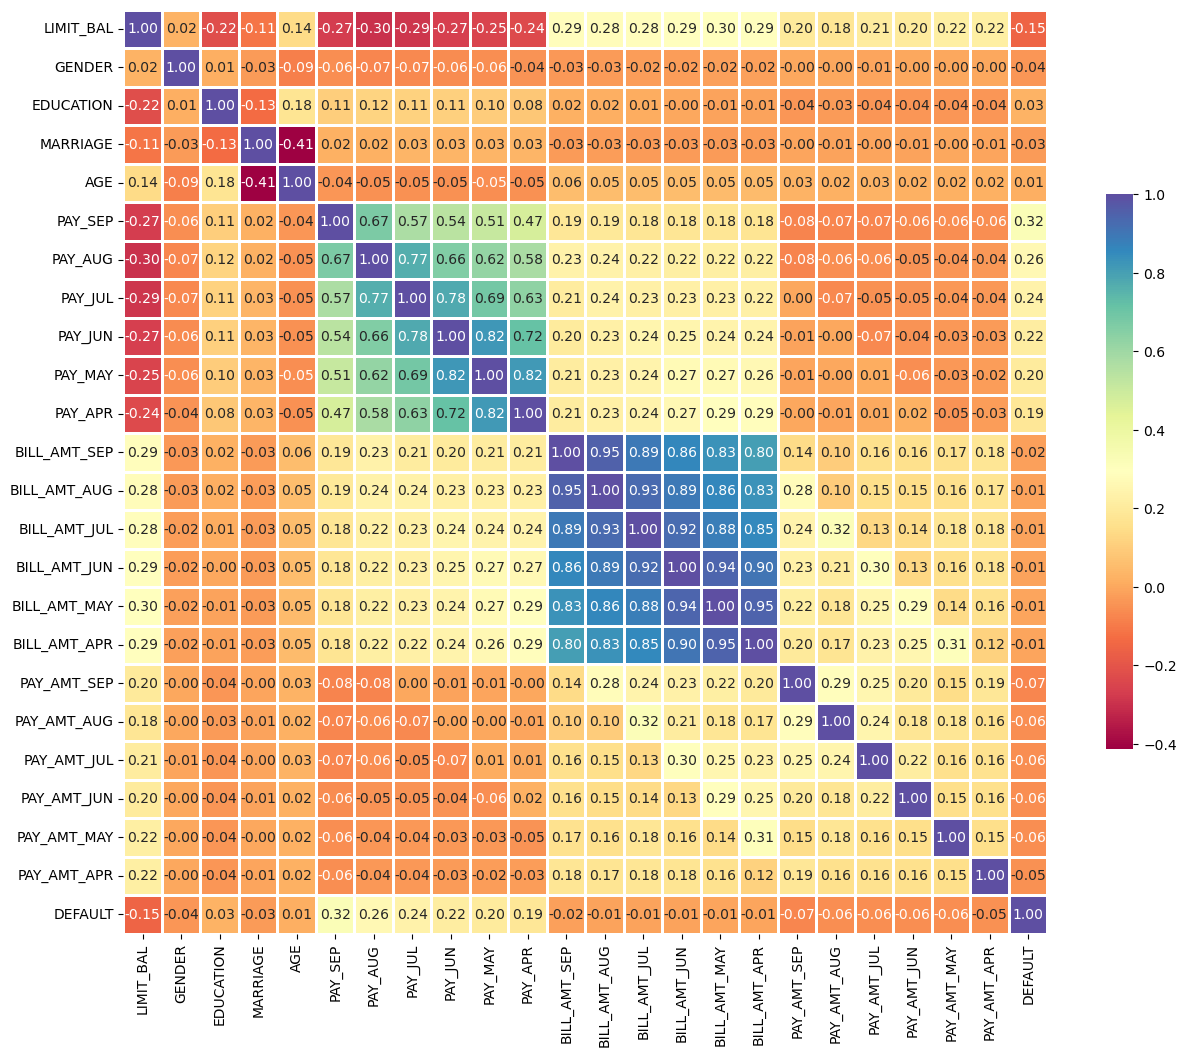

In [46]:
plt.figure(figsize=(15,12))
sns.heatmap(credit.corr(), cmap="Spectral", cbar_kws={'shrink': .6}, square=True, annot=True, fmt='.2f', linewidths=.8)
plt.show()

In [47]:
# we see a there are not much highly correlated variables other than Bill_amounts

In [48]:
# Splitting data Between dependent and indepenedent Varibales:


In [49]:
X = credit.drop(labels='DEFAULT', axis=1)
X = pd.get_dummies(data = X,drop_first = True)
credit.DEFAULT = pd.get_dummies(data = credit.DEFAULT, drop_first=True)
y = credit['DEFAULT']

## Data Scaling

In [50]:
# #Using Standard Scaler Function
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# X_scaled

In [51]:
# X_categoric=pd.get_dummies(data = credit_categoric_features, drop_first=True)

In [52]:
# X_scaled = scaler.fit_transform(credit_numeric_features)
# X_scaled_numer = pd.DataFrame(X_scaled_numer)
# X_categoric = pd.DataFrame(X_categoric)

# X = pd.concat([X_scaled_numer,X_categoric],axis=1)

## Data Splitting

In [53]:
# we have made use of train_test_split function and have splitted the data into 70 %training data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 50, test_size = 0.3)

## ML Model Implementation



In [58]:
#Function for confusion matrix
def plot_confusion_matrix(model):
    y_pred=model.predict(X_test)
    cm=confusion_matrix(y_test,y_pred)
    conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
    sns.heatmap(conf_matrix,annot=True,fmt='d',cbar=False,linewidth=0.2)
    plt.show()

In [56]:
#function for roc_auc_curve
def plot_roc(model):
    y_pred_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob)
    plt.plot(fpr,tpr)
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.0])
    plt.plot([0,1],[0,1],'r--')
    plt.text(x=0.02,y=0.9,s=('AUC Score:',round(roc_auc_score(y_test,y_pred_prob),4)))
    plt.grid(True)

### K Nearest Neighbour

In [54]:
# knn = KNeighborsClassifier(n_neighbors=6, weights='distance').fit(X_train, y_train)
knn_model=KNeighborsClassifier(n_neighbors=3,metric='euclidean').fit(X_train,y_train)
y_pred=knn_model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))


Accuracy: 0.7364444444444445


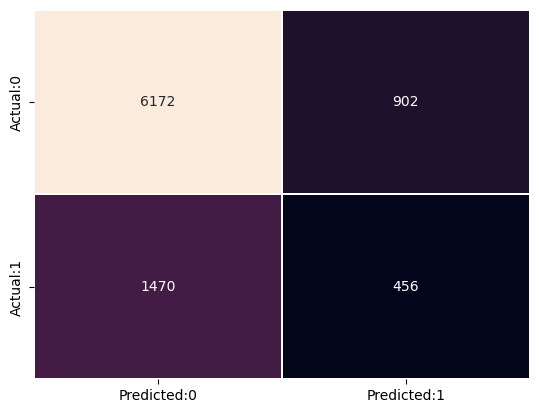

In [59]:
plot_confusion_matrix(knn_model)

In [64]:
#finding th optimal value of k
tune_params={'n_neighbors':np.arange(1,25,2),'metric':['hamming','euclidean','manhattan','Chebyshev']}
knn_classification=KNeighborsClassifier(n_jobs=-1)

knn_random = RandomizedSearchCV(estimator=knn_classification, param_distributions=tune_params, n_iter=20, cv=3, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
print('Best parameters for KNN:',knn_grid.best_params_,'\n')

KeyboardInterrupt: 

In [ ]:
# Building a KNN model with the best parameters and find the accuracy. also generating the classification report

In [ ]:
knn_model=KNeighborsClassifier(metric='manhattan',n_neighbors=15).fit(X_train,y_train)
y_pred=knn_model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

In [464]:

# Predict on the model
knn_y_pred_train = knn_model.predict(X_train)
knn_tree_y_pred_test = knn_model.predict(X_test)

In [465]:
print('Untuned K Nearest Neighbors Model')
print("Training F1 Score: ", metrics.f1_score(y_train, knn_y_pred_train))
print("Testing F1 Score: ", metrics.f1_score(y_test, knn_tree_y_pred_test))
     

Untuned K Nearest Neighbors Model
Training F1 Score:  0.5834621329211747
Testing F1 Score:  0.2777101096224117


In [466]:
t1_knn = metrics.f1_score(y_train, knn_y_pred_train)
t2_knn = metrics.f1_score(y_test, knn_tree_y_pred_test)

In [467]:
# Visualizing evaluation Metric Score chart
metric_dict = {}
metric_dict['without cross KNN'] = {'Training F1': t1_knn, 'Testing F1': t2_knn}

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
k_near = KNeighborsClassifier(weights='distance')
# Fit the Algorithm
k_param_dict={'n_neighbors': range(4,15,1),'metric':['hamming','euclidean','manhattan','Chebyshev']}
grid_k_neighbors = GridSearchCV(k_near, k_param_dict, cv=5, scoring='f1', verbose=1)
grid_k_neighbors.fit(X_train, y_train)
# Predict on the model
print('F1 Score:', grid_k_neighbors.best_score_)
print('Best Hyperparameters:', grid_k_neighbors.best_params_)
print('Model object with best parameters: ')
print(grid_k_neighbors.best_estimator_)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


In [ ]:
#Predicting the response on both train and test data set respectively.
tuned_k_neighbors_y_pred_train = grid_k_neighbors.best_estimator_.predict(X_train)
tuned_k_neighbors_y_pred_test = grid_k_neighbors.best_estimator_.predict(X_test)

print('Tuned K Nearest Neighbors Predictions')
print("F1 on train set:",metrics.f1_score(y_train, tuned_k_neighbors_y_pred_train))
print("F1 on test set:",metrics.f1_score(y_test, tuned_k_neighbors_y_pred_test))

In [ ]:
train_tuned_knn = metrics.f1_score(y_train, tuned_k_neighbors_y_pred_train)
test_tuned_knn = metrics.f1_score(y_test, tuned_k_neighbors_y_pred_test)

In [ ]:
metric_dict={}
metric_dict['Tuned KNN'] = {'Training F1': train_tuned_knn, 'Testing F1': test_tuned_knn}

In [ ]:
metric_dict['Tuned KNN']

there is a slight improvement in the F1 score evaluation matrics. But it is very much clear that the above model is definitely not suitable for the predicting the default as the high evaluation metric F1 score in the train data indicates that the model has overfit in the data set.

## ML Model 2- Logistic Regression

In [ ]:
logreg = LogisticRegression(C=1e9, class_weight='balanced')
logreg.fit(X_train, y_train)
logreg_y_pred_train = logreg.predict(X_train)
logreg_y_pred_test = logreg.predict(X_test)


In [ ]:
print('Untuned Logistic Regression Model')
print("Training F1 Score: ", metrics.f1_score(y_train, logreg_y_pred_train))
print("Testing F1 Score: ", metrics.f1_score(y_test, logreg_y_pred_test))

In [ ]:
t1_log_reg = metrics.f1_score(y_train, logreg_y_pred_train)
t2_log_reg = metrics.f1_score(y_test, logreg_y_pred_test)

In [ ]:
# Visualizing evaluation Metric Score chart
metric_dict['without cross Logistic Regression'] = {'Training F1': t1_log_reg, 'Testing F1': t2_log_reg}

In [ ]:
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

In [ ]:
# ROC Curve graph
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Logisitic Regression')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

In [ ]:
print(metrics.roc_auc_score(y_test, y_pred_prob))

In [ ]:
print('accuracy:', metrics.accuracy_score(y_test, logreg_y_pred_test))
print('precision:', metrics.precision_score(y_test, logreg_y_pred_test))
print('recall:', metrics.recall_score(y_test, logreg_y_pred_test))
print('f1 score:', metrics.f1_score(y_test, logreg_y_pred_test))

In [ ]:
# confusion matrix
labels = ['Not default', 'default']
cm = confusion_matrix(y_train, logreg_y_pred_train)
print(cm)

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

In [ ]:
# confusion matrix
labels = ['Not default', 'default']
cm = confusion_matrix(y_train, logreg_y_pred_train)
print(cm)

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

## 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques 
tuned_log = LogisticRegression(random_state=42, class_weight='balanced')
# Fit the Algorithm
log_param_dict={'C': range(3,7,1),
                'penalty': ['l1','l2']}
grid_log = GridSearchCV(tuned_log, log_param_dict, cv=5, scoring='f1', verbose=1)
grid_log.fit(X_train, y_train)

In [ ]:
print('F1 Score:', grid_log.best_score_)
print('Best Hyperparameters:', grid_log.best_params_)
print('Model object with best parameters: ')
print(grid_log.best_estimator_)
     

In [ ]:
grid_log_y_pred_train = grid_log.best_estimator_.predict(X_train)
grid_log_y_pred_test = grid_log.best_estimator_.predict(X_test)

In [ ]:
print('Tuned Logistic Regression Model Predictions')
print("F1 on train set:",metrics.f1_score(y_train, grid_log_y_pred_train))
print("F1 on test set:",metrics.f1_score(y_test, grid_log_y_pred_test))

In [ ]:
train_tuned_log_reg = metrics.f1_score(y_train, grid_log_y_pred_train)
test_tuned_log_reg = metrics.f1_score(y_test, grid_log_y_pred_test)
     

In [ ]:
metric_dict['Tuned Logistic Regression'] = {'Training F1': train_tuned_log_reg, 'Testing F1': test_tuned_log_reg}

In [ ]:
metric_dict['Tuned Logistic Regression']

In [ ]:
labels = ['Not default', 'default']
cm = confusion_matrix(y_test, grid_log_y_pred_test)
print(cm)

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

In [ ]:
y_pred_prob_1 = grid_log.predict_proba(X_test)[:, 1]

In [ ]:
# ROC Curve graph
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob_1)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for Logisitic Regression')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

In [ ]:
print(metrics.roc_auc_score(y_test, y_pred_prob_1))

Grid search cv technique has been issued for hyperparameter tunning.
There in not much improvement noticed even after applying grid search CV. F1 score and roc_auc score remains same for both the cases.

# Model-3

## Decision tree

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

In [ ]:
#predicting the model
tree_y_pred_train = tree.predict(X_train)
tree_y_pred_test = tree.predict(X_test)

In [ ]:
print('Untuned Decision Tree Model')
print("Training F1 Score: ", metrics.f1_score(y_train, tree_y_pred_train))
print("Testing F1 Score: ", metrics.f1_score(y_test, tree_y_pred_test))

In [ ]:
# Evaluation metric Score Chart.

In [ ]:
t1_tree = metrics.f1_score(y_train, tree_y_pred_train)
t2_tree = metrics.f1_score(y_test, tree_y_pred_test)

metric_dict['withoutcross Decision Tree'] = {'Training F1': t1_tree, 'Testing F1': t2_tree}

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques 
decision_tree = DecisionTreeClassifier(random_state=3, criterion='gini')
param_dict={'max_depth': range(2,15,1),
            'max_leaf_nodes': range(2,30,2),
            'min_samples_split': range(2,4,1)}
grid_tree = GridSearchCV(decision_tree, param_dict, cv=5, scoring='f1', verbose=1)
# Fit the Algorithm
grid_tree.fit(X_train, y_train)

In [ ]:
print('F1 Score:', grid_tree.best_score_)
print('Best Hyperparameters:', grid_tree.best_params_)
print('Model object with best parameters: ')
print(grid_tree.best_estimator_)

In [ ]:
# Predict on the model
tuned_tree_y_pred_train = grid_tree.best_estimator_.predict(X_train)
tuned_tree_y_pred_test = grid_tree.best_estimator_.predict(X_test)

In [ ]:
print('Tuned Decision Tree Model Predictions')
print("F1 on train set:",metrics.f1_score(y_train, tuned_tree_y_pred_train))
print("F1 on test set:",metrics.f1_score(y_test, tuned_tree_y_pred_test))

In [ ]:
train_tuned_tree = metrics.f1_score(y_train, tuned_tree_y_pred_train)
test_tuned_tree = metrics.f1_score(y_test, tuned_tree_y_pred_test)

In [ ]:
metric_dict['Tuned Decision Tree'] = {'Training F1': train_tuned_tree, 'Testing F1': test_tuned_tree}

There is an improvement after using cross validation. without cross validation the model was overfit that's the reason the evaluation matrics was quite high in the train data. but after using cross validation the matrics numbers were balanced for both train and test data.

# Model -4
## XG boost with cross validation

In [ ]:
credit.DEFAULT.value_counts()

In [ ]:
#Applying SMOTE technique to tackle the class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res,Y_res=smote.fit_resample(X_train,y_train)

In [ ]:
print('Original dataset shape', len(credit))
print('Resampled dataset shape', len(Y_res))

In [ ]:
Y_res.value_counts()

In [ ]:
# pip install xgboost


In [ ]:
# import xgboost
# xgb_model= xgboost.XGBClassifier()
# tune_params={
#  "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
#  "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
#  "min_child_weight" : [ 1, 3, 5, 7 ],
#  "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
#  "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]

# }
# xgb_grid=GridSearchCV(estimator=xgb_model,param_grid=tune_params,cv=5,n_jobs=-1).fit(X_train,y_train)
     

In [ ]:

model= xgboost.XGBClassifier()
params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]

}
random_search=RandomizedSearchCV(model,param_distributions=params,n_iter=5,scoring='f1',n_jobs=-1,cv=5,verbose=3)
     

In [ ]:
random_search.fit(X_train,y_train)

In [ ]:
#  best param
random_search.best_params_

In [ ]:
# Best estimators:
random_search.best_estimator_

In [ ]:
model_= xgboost.XGBClassifier(objective='binary:logistic',
                                  min_child_weight=5,
                                 max_depth=6,
                                 learning_rate=0.05,
                                 gamma=0.3,
                                  colsample_bynode=1,
                                  colsample_bytree=0.7,
                                  use_label_encoder=False).fit(X_train,y_train)

In [ ]:

# Predicting model
x_pred_train=model_.predict(X_train)
x_pred= model_.predict(X_test)

In [ ]:
print("F1 on train set:",metrics.f1_score(y_train, x_pred_train))
print("F1 on test set:",metrics.f1_score(y_test, x_pred))

In [ ]:
train_tuned_XGB = metrics.f1_score(y_train, x_pred_train)
test_tuned_XGB = metrics.f1_score(y_test, x_pred)
     

In [ ]:
metric_dict['Tuned XGB'] = {'Training F1': train_tuned_XGB, 'Testing F1': test_tuned_XGB}

In [ ]:
labels = ['Not default', 'default']
cm = confusion_matrix(y_test, x_pred)
print(cm)

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax) #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(labels)
ax.yaxis.set_ticklabels(labels)

In [ ]:
y_pred_prob_ = random_search.predict_proba(X_test)[:, 1]

In [ ]:
# ROC Curve graph
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob_)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve for XGB classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

In [ ]:
print(metrics.roc_auc_score(y_test, y_pred_prob_))

Conclusion:

In [ ]:
Evaluation_metric_comparison=pd.DataFrame.from_dict(metric_dict, orient='index')

In [ ]:

Evaluation_metric_comparison

Since there is a high class imbalance so we have choosen F1 score as evaluation metrics for the possitive business impact. The F1 score is concerened about precision and recall both.

As per the above implementation of models the XGBoost has the best F1 score as the other models is not performing good. so we would choose Random forest model.

From EDA we can see that, The gender 2 has more frequent habbit of taking credits.

In education column and marital status column the education 2 and marital status 2 has more frequent habbit of taking credits.

Apart from bill_april to september columns there are no highly correlated inputs in our dataset, so there is no multicollinearity problem.

There was a high class imbalance in target varriable.

There are lot of outlier values in the dataset.

we have implemented 4 classification models and achieved a fairly good result for only one algorithms due to the highly class imbalance issue.

KNN

Logistic Regression

Decision tree

XG Boost.

XG Boost classifier performed better than all other models